**MOST RECENT VERSION OF THIS FILE, CHECK GITHUB FOR PROGRESS!!**

## Necessary Packages:

In [1]:
import symlib

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import numpy as np
from numpy import polyfit

import os

import scipy
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import linregress

from astropy.cosmology import FlatLambdaCDM, z_at_value
import astropy.units as u

# <a id = "table_of_contents"></a>
# Table of Contents:
(click on each link to jump to the respective section)

(for this table of contents to work, run all **Markdown** cells once)
* [Mass Accretion Histories](#mass_accretion_histories)
* [Subhalo Mass Functions](#subhalo_mass_functions)
* [Nsubs(z) & Mhost(z) vs. Redshift](#nsubs_mhost_vs_redshift)
* [Nsubs(z)/Nsubs(z=0) vs. Mhost(z)/Mhost(z=0)](#norm_nsubs_vs_norm_host_mass)
* [Smooth vs. Clumpy Particle Accretion](#smooth_vs_clumpy_accretion)
* [Correlation Functions](#correlation_functions)
* [Subhalo Infalls](#subhalo_infalls)
* [Host Concentration](#host_concentration)
* [Machine Learning](#machine_learning)
* [Subhalo Animations](#animations)

## Global variables:
*These globals are used by every function below --> this cell MUST be run before anything else*

In [2]:
## GLOBALS:

## FILEPATHS
base_dir = "C:/Users/steph/Symphony"                           ## base directory, points to the container folder where the Symphony data files are


## SUITES
#suite_list = ["SymphonyCluster"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "SymphonyGroup", "SymphonyLCluster"]
#suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]


## PLOT COLORS & LABELS --> colors for confidence band, individual hosts, etc
colors = {"SymphonyLMC": "tab:purple",
          "SymphonyMilkyWay": "tab:blue",
          "MWest": "black",
          "SymphonyGroup": "tab:green",
          "SymphonyLCluster": "tab:orange",
          "SymphonyCluster": "tab:red"}

## colors for mean lines
avg_colors = {"SymphonyLMC": (102/225, 0/255, 110/255),
              "SymphonyMilkyWay": (7/255, 0/255, 110/255),
              "MWest": (0, 0, 0),
              "SymphonyGroup": (22/255, 112/255, 0/255),
              "SymphonyLCluster": (163/255, 90/255, 2/255),
              "SymphonyCluster": (128/255, 3/255, 3/255)}

labels = {"SymphonyLMC": "SymphonyLMC",
          "SymphonyMilkyWay": "SymphonyMilkyWay",
          "MWest": "MWest",
          "SymphonyGroup": "SymphonyGroup",
          "SymphonyLCluster": "SymphonyLCluster",
          "SymphonyCluster": "SymphonyCluster"}


## MODEL SELECTION
mah_fit_model = {"SymphonyLMC": "wechsler",
                 "SymphonyMilkyWay": "wechsler",
                 "MWest": "wechsler",
                 "SymphonyGroup": "wechsler",
                 "SymphonyLCluster": "mcbride",
                 "SymphonyCluster": "mcbride"}


## GLOBAL ANALYSIS PARAMETERS

## maximum x-axis extents for SHMFs
x_max_shmf = {"SymphonyLMC": 2e11,
              "SymphonyMilkyWay": 2e12,
              "MWest": 2e12,
              "SymphonyGroup": 2e13,
              "SymphonyLCluster": 2e14,
              "SymphonyCluster": 2e15}

min_particles = 300      ## minimum number of particles for a halo to be considered "well-resolved"
z_max = 16.0             ## maximum redshift to keep (inclusive)

## MAH PLOTTING PARAMETERS:
MAH_ticks_sf = np.arange(0, 1.2, 0.1)
MAH_ticks_z = [16, 8, 4, 2, 1, 0.5, 0.25]                   ## ticks and labels for when x_axis = "redshift"
z_labels = ["16", "8", "4", "2", "1", "0.5", "0.25"]
MAH_redshift_xlim = (16.0, 0.05)
mah_host_lw = 0.5                       ## per-host linewidth
mah_host_alpha = 0.15                   ## host alpha (opacity)
mah_avg_lw = 1.25                       ## linewidth of the mean lines
mah_confidence_band_alpha = 0.25        ## alpha (opacity) of the 16-84% confidence band

## MAH plot formatting
mah_label_fs = 12
mah_title_fs = 14
mah_legend_fs = 10
mah_tick_fs = 10
mah_legend_fs = 10
mah_norm_label_fs = 12

######################################################################################################

## SHMF PLOTTING PARAMETERS:
redshifts_shmf = [2.0, 1.0, 0.5, 0.25, 0.1, 0.0]
#redshifts_shmf = [2.0, 1.0, 0.0]
n_bins = 50                                                 ## number of mass bins
m_max = 1e15                                                ## mass of the highest mass bin
shmf_host_lw = 0.5                                          ## same as for MAHs, just for SHMFs
shmf_host_alpha = 0.15
shmf_avg_lw = 1.25
shmf_confidence_band_alpha = 0.25
shmf_ratio_min = 1e-5               ## lower x limit (Msub/Mhost)
shmf_ratio_max = 1.0                ## upper x limit (Msub/Mhost)

## ADDED TO GLOBALS FOR SIMPLICITY
## computes the fraction of a subhalo's own volume that overlaps with the host's virial sphere
## assumes uniform density within each sphere so that volume-fraction ~= mass-fraction (not true, but good as a first attempt)
## R = host_rvir (scalar), r = subhalo rvir (array), d = subhalo distance from host center (array)
def sphere_overlap_fraction(d, R, r):

    d = np.asarray(d, dtype = float)
    r = np.asarray(r, dtype = float)
    R = float(R)

    frac = np.zeros_like(d)

    ## avoid divide-by-zero for d = 0 (subhalo centered exactly on host)
    d_safe = np.where(d > 0, d, 1e-6)

    ## case 1: no overlap (subhalo distance is greater than the sum of the radii, no part of the subhalo overlaps with the main host)
    no_overlap = d >= (R + r)

    ## case 2: subhalo fully inside host (distance + subhalo radius is less than the host radius)
    ## the SUBHALO is the one being fully contained here, so the overlap volume is the subhalo's OWN volume (v_sub) (i.e. the whole subhalo overlaps).
    ## frac = v_overlap / v_sub = v_sub / v_sub = 1, so this branch just returns 1.0 directly
    ## further down rather than computing v_sub/v_sub explicitly.
    sub_fully_inside = (d + r) <= R

    ## case 3: host fully inside subhalo (very large/close subhalo, e.g. the LMC analog near pericenter)
    ## here the HOST is the one being fully contained inside the (larger) subhalo
    ## the overlap volume is the HOST's own volume (v_host), NOT the subhalo's
    ## frac = v_overlap / v_sub = v_host / v_sub, which is < 1 since the subhalo is bigger than the host in this scenario.

    ## NOTE: this branch should essentially never fire for real host/subhalo pairs
    ## this exists as a defensive fallback for anomalous halo-finder output
    ## (e.g. a transient/unvirialized host with an artificially small rvir), not a case expected to occur for genuine subhalos like an LMC analog.
    host_fully_inside = (d + R) <= r

    ## case 4: partial overlap --> this is the most the general case
    ## The overlap volume is the volume of the lens-shaped region where the two spheres overlap,
    ## for two spheres of radius R and r with centers separated by distance d.
    v_overlap = (np.pi * (R + r - d_safe)**2 * (d_safe**2 + 2*d_safe*(R + r) - 3*(R - r)**2)) / (12 * d_safe)

    ## v_sub is always the denominator, regardless of which case we're in
    ## the function's job is always "what fraction of the SUBHALO's mass/volume overlaps with the host"
    ## thus every case expresses its overlap volume as a fraction of v_sub, never v_host
    v_sub = (4.0/3.0) * np.pi * r**3
    partial_frac = np.clip(v_overlap / v_sub, 0.0, 1.0)

    ## build up frac case by case (later np.where calls override earlier ones)
    frac = np.where(no_overlap, 0.0, partial_frac)           ## default: no overlap, or the general partial-overlap formula
    frac = np.where(sub_fully_inside, 1.0, frac)             ## override: subhalo fully engulfed by host -> 100% overlap

    ## host-fully-inside-subhalo override --> overlap volume is the HOST's volume
    ## expressed as a fraction of the subhalo's volume since that's what this function always returns
    v_host = (4.0/3.0) * np.pi * R**3
    frac = np.where(host_fully_inside, np.clip(v_host / v_sub, 0.0, 1.0), frac)

    return frac

MilkyWay-est hosts have different z = 0 relative to Symphony z = 0. This is because MilkyWay-est has an LMC analog which does not fall in at z = 0 (a = 1.0) in every single simulation; there is some host-to-host scatter. In the [MilkyWay-est paper](https://arxiv.org/pdf/2404.08043), they discuss their criteria for the the z $\approx$ 0 snapshots here:
* "Given the ±20 kpc range allowed for our LMC analogs’ z = 0 distances, we define the snapshot at which to analyze each Milky Way-est system, a_LMC_50, as the time that its LMC analog is closest to 50 kpc from the host center."
* "If there are multiple snapshots at which the LMC analog’s distance is smaller than 50 kpc, we choose the earliest time."
* "In general, our LMC analogs’ orbits do not exactly match those in the parent box. In order to ensure that all LMC analogs reach an appropriate distance, some Milky Way-est simulations are analyzed slightly after z = 0."
* "The resulting Milky Way-est analysis snapshots are typically within ≈ 500 Myr of z = 0" (values are in Appendix A of the paper)
* "We refer to these as the z ≈ 0 snapshots, and we normalize scale factors for each Milky Way-est host relative to a_LMC_50."

Given this information, it would be useful to pre-compute all of these snapshots (converted into redshift and cosmic time) for later use in the analysis

Loading Halo169, host 1/20
a_lmc_50 value from table: 0.970 | value from catalog: 0.975 | difference: -0.005
host mass from table: 0.980 | host mass from catalog: 0.977 | difference: -0.003
best score: 0.0010, second best score: 0.9071, ratio: 869.18 <-- larger ratios = LMC analog is best
target LMC mpeak from table: 2.290 | actual mpeak: 2.289 | difference: 0.001
target distance from table: 58.000 | actual distance 58.119 | difference: -0.119
sanity check: LMC mass --> 2.29e+11 (should be close to 10^11)

Loading Halo453, host 2/20
a_lmc_50 value from table: 0.960 | value from catalog: 0.962 | difference: -0.002
host mass from table: 1.000 | host mass from catalog: 1.001 | difference: 0.001
best score: 0.0035, second best score: 2.6772, ratio: 766.57 <-- larger ratios = LMC analog is best
target LMC mpeak from table: 3.300 | actual mpeak: 3.297 | difference: 0.003
target distance from table: 57.000 | actual distance 56.554 | difference: 0.446
sanity check: LMC mass --> 3.30e+11 (shoul

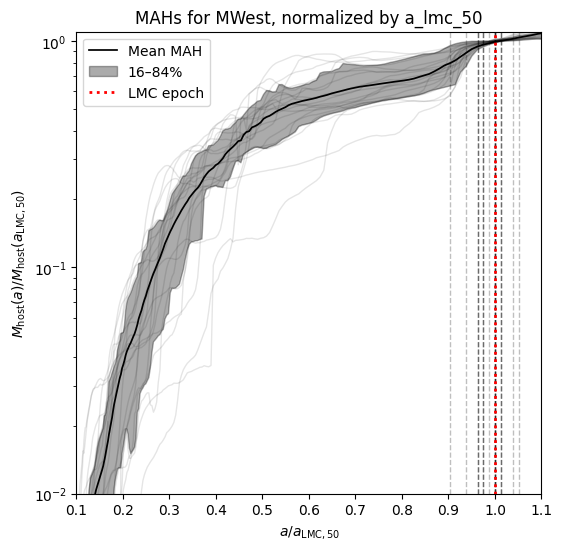

In [11]:
## THIS CELL NEEDS TO BE RUN BEFORE ANYTHING BELOW SO THAT CELLS USING MW-est ANALYSIS SNAPSHOTS DON'T CRASH!!!

## hardcoded values from Milky Way-est Table 2:
## contains a_lmc_50 (z ~= 0) values for each host in MWest
## values are (a_lmc_50, host_mass/1e12, m_peak_lmc/1e11, r_LMC)
Table2_MWest = {"Halo169": (0.97, 0.98, 2.29, 58), "Halo453": (0.96, 1.00, 3.30, 57), "Halo004": (1.00, 1.03, 1.74, 61),
                "Halo476": (0.96, 1.06, 2.50, 50), "Halo113": (1.01, 1.08, 0.36, 49), "Halo222": (1.05, 1.12, 2.67, 63),
                "Halo407": (1.00, 1.13, 0.96, 54), "Halo327": (0.94, 1.13, 1.41, 44), "Halo975": (0.99, 1.14, 3.15, 34),
                "Halo170": (0.97, 1.21, 2.61, 50), "Halo719": (1.01, 1.23, 4.63, 51), "Halo282": (1.04, 1.28, 0.71, 38),
                "Halo983": (1.00, 1.37, 2.50, 49), "Halo349": (0.90, 1.40, 2.90, 52), "Halo747": (0.97, 1.41, 0.73, 54),
                "Halo666": (1.00, 1.55, 6.36, 79), "Halo659": (0.96, 1.56, 0.80, 44), "Halo788": (1.00, 1.71, 0.68, 34),
                "Halo756": (1.00, 1.73, 1.61, 66), "Halo229": (1.01, 1.74, 0.19, 64)}

MWest_halos = list(Table2_MWest.keys())

###########################################################################################################################################

## let's see if we can recover the Symphony snapshots corresponding to the tabulated a_lmc_50 values and identify the LMC analogs
## this won't be perfect, since MilkyWay-est used Rockstar and the Symphony catalog uses Symlib, but it should be close

n_hosts_MWest = symlib.n_hosts("MWest")

## simulation parameters are the same for every host in a given suite, so we can use the first host to get these
sim_dir_MWest_0 = symlib.get_host_directory(base_dir, "MWest", 0)
params_MWest = symlib.simulation_parameters(sim_dir_MWest_0)
h100 = params_MWest["h100"]                         ## H0 / 100 km/s/Mpc, value is 0.7
particle_mass = params_MWest["mp"]                  ## comoving particle mass (Msun/h) --> scaled to be constant over time
particle_mass_physical = particle_mass / h100       ## physical particle mass (Msun) --> converts from simulation Msun/h units to physical Msun

fig, ax = plt.subplots(figsize = (6, 6))

lmc_analog_sub_data = {}

for i_host, halo_name in enumerate(MWest_halos):

    ## pulling the hardcoded values from the table:
    ## a_lmc_50_table = a_lmc_50
    ## host_mass_1e12_table = Mvir of the host at a_lmc_50/10^12 Msun
    ## lmc_mpeak_1e11_table = Mpeak of the LMC analog/10^11 Msun
    ## r_lmc_table = Rvir of the LMC analog at a_lmc_50
    a_lmc_50_table, host_mass_1e12_table, lmc_mpeak_1e11_table, r_lmc_table = Table2_MWest[halo_name]

    print(f"Loading {halo_name}, host {(i_host + 1)}/{n_hosts_MWest}")

    ## sim directory and values for the current host
    sim_dir_MWest = symlib.get_host_directory(base_dir, "MWest", halo_name)
    h, hist = symlib.read_subhalos(sim_dir_MWest)
    scale_factors = symlib.scale_factors(sim_dir_MWest)

    # snapshot from the subhalo catalog corresponding to a_lmc_50
    target_snap = np.argmin(np.abs(scale_factors - a_lmc_50_table))
    print(f"a_lmc_50 value from table: {a_lmc_50_table:.3f} | value from catalog: {scale_factors[target_snap]:.3f} | difference: {(a_lmc_50_table - scale_factors[target_snap]):.3f}")

    # host mass check
    host_mvir = h["mvir"][0, target_snap]
    print(f"host mass from table: {host_mass_1e12_table:.3f} | host mass from catalog: {host_mvir/1e12:.3f} | difference: {(host_mvir/1e12 - host_mass_1e12_table):.3f}")

    ## LMC analog identification:
    ## using the expected LMC Mpeak and the distance criterion, try to find which subhalo index most strongly corresponds to the LMC
    target_mpeak_lmc = lmc_mpeak_1e11_table * 1e11
    target_r_lmc = r_lmc_table

    # exclude host
    sub_ids = np.arange(1, h["mvir"].shape[0])

    ## subhalo masses at a_lmc_50
    sub_masses = h["mvir"][sub_ids, target_snap]

    ## "ok" survival cut
    ok = h["ok"][1:, :]

    ## 300 particles cut
    particle_cut = sub_masses >= min_particles * particle_mass_physical

    ## tossing out invalid subhalos
    valid = ok[:, target_snap] & particle_cut
    sub_ids = sub_ids[valid]
    sub_mpeak_values = hist["mpeak"][sub_ids]

    ## subhalo locations at the scale factor closest to a_lmc_50
    host_pos = h["x"][0, target_snap]
    sub_pos = h["x"][sub_ids, target_snap]

    # physical host-subhalo separation at a_lmc_50
    r_lmc_values = np.linalg.norm(sub_pos - host_pos, axis = 1)

    ## difference between actual and expected
    ## logspace penalizes differences more than normal space
    dm = np.log10(sub_mpeak_values / target_mpeak_lmc)
    dr = np.log10(r_lmc_values / target_r_lmc)

    ## squared sum of scores
    ## basically sqrt[(dex mass score)^2 + (dex distance score)^2]
    w_mass = 2.0
    w_radius = 1.0

    ## subhalo index that matches the score the best
    match_score = np.sqrt((w_mass * dm)**2 + (w_radius * dr)**2)

    sort_scores = np.argsort(match_score)

    best_idx = sort_scores[0]
    second_idx = sort_scores[1]
    lmc_idx = sub_ids[best_idx]
    score_ratio = match_score[second_idx] / match_score[best_idx]
    
    print(f"best score: {match_score[best_idx]:.4f}, second best score: {match_score[second_idx]:.4f}, ratio: {score_ratio:.2f} <-- larger ratios = LMC analog is best")
    print(f"target LMC mpeak from table: {target_mpeak_lmc/1e11:.3f} | actual mpeak: {sub_mpeak_values[best_idx]/1e11:.3f} | difference: {(target_mpeak_lmc/1e11 - sub_mpeak_values[best_idx]/1e11):.3f}")
    print(f"target distance from table: {target_r_lmc:.3f} | actual distance {r_lmc_values[best_idx]:.3f} | difference: {(target_r_lmc - r_lmc_values[best_idx]):.3f}")
    print(f"sanity check: LMC mass --> {sub_mpeak_values[best_idx]:.2e} (should be close to 10^11)")
    print()

    ## normalization: 1+z = a_lmc_50/a
    ## we can just store all of them

    ## scale factors for this host
    host_a = scale_factors
    host_a_lmc_50 = scale_factors[target_snap]
    
    # physical redshift
    host_z = 1 / host_a - 1

    # normalized quantities
    host_a_norm = host_a / host_a_lmc_50                       # a / a_lmc_50
    host_z_norm = 1 / host_a_norm - 1                          # a_lmc_50/a - 1

    ## save index, snapshot and a_lmc_50, subhalo properties (mass, locations, rvir, velocity, etc), host properties at a_lmc_50
    lmc_analog_sub_data[halo_name] = {"sub_idx": lmc_idx,
                                     
                                      # identification
                                      "target_snap": target_snap,
                                      "a_lmc_50": scale_factors[target_snap],
                                      "scale_factors": scale_factors,
                                      "redshifts": host_z,
                                      "scale_factors_norm": host_a_norm,
                                      "redshifts_norm": host_z_norm,
                                     
                                      # matching
                                      "score_best": match_score[best_idx],
                                      "score_second": match_score[second_idx],
                                      "score_ratio": score_ratio,
                                      
                                      "mpeak_target": target_mpeak_lmc,
                                      "mpeak": hist["mpeak"][lmc_idx],
                                      "r_target": target_r_lmc,
                                      "r_host": r_lmc_values[best_idx],
                                     
                                      # position/velocity
                                      "pos": h["x"][lmc_idx, target_snap],
                                      "vel": h["v"][lmc_idx, target_snap],
                                     
                                      # host quantities
                                      "host_mvir": h["mvir"][0, target_snap],
                                      "host_rvir": h["rvir"][0, target_snap],
                                      "host_mass": h["mvir"][0, :],
                                      "host_mass_analysis": h["mvir"][0, target_snap],
                                     
                                      # LMC properties
                                      "mvir": h["mvir"][lmc_idx, target_snap],
                                      "vmax": h["vmax"][lmc_idx, target_snap],
                                      "rvir": h["rvir"][lmc_idx, target_snap]}

suite_scale_factors_norm = []
suite_redshifts_norm = []
suite_masses = []
suite_masses_analysis = []
for host_idx, host in enumerate(lmc_analog_sub_data):

    host_data = lmc_analog_sub_data[host]
    host_scale_factors_norm = host_data["scale_factors_norm"]
    host_redshifts_norm = host_data["redshifts_norm"]
    host_mass = host_data["host_mass"]
    host_mass_analysis = host_data["host_mass_analysis"]

    ## vertical lines where a_lmc_50 is for each host
    ax.axvline(host_data["a_lmc_50"], color = "black", linewidth = 1.0, linestyle = "--", alpha = 0.25)

    ax.plot(host_scale_factors_norm, host_mass / host_mass_analysis, color = "black", alpha = 0.1, lw = 1.0)

    ## save for later averaging
    suite_scale_factors_norm.append(host_scale_factors_norm)
    suite_redshifts_norm.append(host_redshifts_norm)
    suite_masses.append(host_mass)
    suite_masses_analysis.append(host_mass_analysis)


max_len = max(len(x) for x in suite_masses)

def pad(arr, length):
    out = np.full(length, np.nan)
    out[:len(arr)] = arr
    return out

suite_scale_factors_norm = np.vstack([pad(sf, max_len) for sf in suite_scale_factors_norm])
suite_redshifts_norm = np.vstack([pad(z, max_len) for z in suite_redshifts_norm])
suite_masses = np.vstack([pad(m, max_len) for m in suite_masses])
suite_masses_analysis = np.array(suite_masses_analysis)

# Normalize each host by its own final mass
mhost_over_mfinal_suite = suite_masses / suite_masses_analysis[:, None]

# Mean normalized MAH
mean_mhost_over_mfinal = np.nanmean(mhost_over_mfinal_suite, axis = 0)

# 16th and 84th percentiles
p16 = np.nanpercentile(mhost_over_mfinal_suite, 16, axis = 0)
p84 = np.nanpercentile(mhost_over_mfinal_suite, 84, axis = 0)

## mean scale factor for all scale factors and redshifts at a given snapshot
mean_scale_factor = np.nanmean(suite_scale_factors_norm, axis = 0)
mean_redshift = np.nanmean(suite_redshifts_norm, axis = 0)

a_plot = mean_scale_factor
mean_plot = mean_mhost_over_mfinal
p16_plot = p16
p84_plot = p84

ax.plot(a_plot, mean_plot, color = "black", lw = 1.25, label = "Mean MAH")
ax.fill_between(a_plot, p16_plot, p84_plot, color = "black", alpha = 0.33, label = "16–84%")
ax.axvline(1, color = "red", linestyle = ":", lw = 2.0, label = "LMC epoch")

ax.set_xlabel(r"$a / a_{\rm LMC,50}$")
ax.set_ylabel(r"$M_{\rm host}(a) / M_{\rm host}(a_{\rm LMC,50})$")
ax.set_yscale("log")
ax.set_title("MAHs for MWest, normalized by a_lmc_50", fontsize = 12)
ax.set_xlim(0.1, 1.0)
ax.set_ylim(1e-2, 1.1)

ticks = np.arange(0.1, 1.2, 0.1)
ax.set_xticks(ticks)

#fig.savefig("MWest MAHs (normalized, no axis limits).png")
ax.legend(loc = "upper left", fontsize = 10)
plt.show()

In [12]:
DEFAULT_HALO_NAMES = {}

for suite in suite_list:
    if suite == "MWest":
        DEFAULT_HALO_NAMES[suite] = MWest_halos
    else:
        n_hosts = symlib.n_hosts(suite)
        DEFAULT_HALO_NAMES[suite] = list(range(n_hosts))

<a id = "mass_accretion_histories"></a>
## Mass Accretion Histories
[Back to Table of Contents](#table_of_contents)

* A "mass accretion history" is the mass of the subhalo as a function of time (snapshot, scale factor, redshift, cosmic time, etc).
* Below we focus on HOST mass accretion histories
* A 300 particle cut and a "survival cut" are applied, to exclude any times where the host was not well-resolved or well-formed
* Functionality is separated into several helper functions, a "dataloader" which loads all the relevant data in once, and then some "statistics" functions and a "plotter" function.
* Halo finder note: Symfind has no host halo data stored, so Rockstar (the "read_rockstar()" function) is used in place. Rockstar and Symfind deviate for smaller halos, especially under heavy tidal stripping, so this choice should be okay for largely unstripped massive halos such as the main hosts in Symphony.

For MWest only:
* The "analysis snapshots" (point where the LMC analog is closest to 50 kpc from the host center) vary for Milkyway-est hosts.

In [13]:
## Mass Accretion History (MAH) pipeline --> reading in data for creating MAHs for all suites in Symphony

## Structure:
## 1. Helper functions
## 2. Dataloader (loads all information needed to build the MAH)
## 3. Statistics
## 4. Plotters

##############################################################################################################################################

## HELPER FUNCTIONS:

## MAH_z_mask returns a boolean mask selecting snapshots with redshift <= z_max under the chosen definition of "a_now"
## For all Symphony suites, a_now = 1.0, so the conversion from scale factor to redshift is simply 1+z = 1/a
## For MilkyWay-est, a_now = a_lmc_50, so the conversion is 1+z = a_lmc_50/a
def MAH_build_time_mask(scale_factors, a_now, z_max):
    
    redshifts = (a_now / scale_factors) - 1.0
    mask = redshifts <= z_max
    
    return mask

## Scale factor arrays may be different sizes due to specific quirks about the simulations (i.e SymphonyLMC has 236 snapshots but Cluster only has 200)
## Shorter arrays are padded with NaN until they all match the length of the longest one
## MAH_nan_padding_stacking returns a numpy array of padded arrays
## Left-padding aligns all histories at their final retained snapshot
## a_now only shifts the redshift zero-point used to label that time axis: a_now = 1.0 for Symphony, a_now = a_lmc_50 for MWest
## Missing earlier snapshots are filled with NaN, so that NaN-aware statistics functions ignore them automatically later on
def MAH_nan_padding_stacking(arrays, length):
    
    padded = [np.concatenate([np.full(length - len(a), np.nan), a]) for a in arrays]
    
    return np.vstack(padded)

## per-suite dataloader; loads mass accretion history information for every host in a given suite
def load_MAH_suite_data(base_dir, suite, min_particles = min_particles, z_max = z_max,
                        mwest_snap_data = None, verbose = True):
    
    n_hosts = symlib.n_hosts(suite)                 ## get the # of hosts (individual simulations in each folder)

    ## for MWest, iterate over the halo NAME strings --> guarantees a_lmc_50 that is pulled matches what was loaded
    ## host_ids = halo_names
    if suite == "MWest" and mwest_snap_data is not None:
        host_ids = list(mwest_snap_data.keys())
    else:
        host_ids = list(range(n_hosts))
    
    ## initializing empty lists to be filled later
    host_masses = []
    host_scale_factors = []
    particle_mass = None

    ## tracking any hosts that failed to load
    skipped_hosts = []

    ## saving per-host scale factor/redshift transformation
    host_a_now = []

    ## looping over hosts in a particular suite
    for i_host, host_id in enumerate(host_ids):
        if verbose:
            print(f"Loading host {i_host + 1} in suite {suite}", end = "\r", flush = True)

        try:
            sim_dir = symlib.get_host_directory(base_dir, suite, host_id)               ## getting the full directory to the host data

            ## reading in Rockstar host halo data, since Symfind has no host halo data 
            h, hist = symlib.read_rockstar(sim_dir, comoving = False)

            ## storing particle mass for the first host (identical across a suite)
            if particle_mass is None:
                params = symlib.simulation_parameters(sim_dir)                          ## getting simulation parameters used in this suite

                ## simulation params given in h^-1 Msun
                ## getting physical "macro-particle" mass used in this suite
                particle_mass = float(params["mp"]) / params["h100"]

            scale_factors = symlib.scale_factors(sim_dir)                               ## reading in per-host scale factors

            ## define the reference scale factor for this host
            ## Symphony uses a_now = 1.0 (z = 0), while MWest uses the recovered analysis snapshot a_lmc_50.
            if suite == "MWest" and mwest_snap_data is not None:
                a_now = mwest_snap_data[host_id]["a_lmc_50"]
            else:
                a_now = 1.0

            host_a_now.append(a_now)
            
            z_mask = MAH_build_time_mask(scale_factors, a_now, z_max)
            scale_factors = scale_factors[z_mask]

            ## getting host properties (host is always index 0)
            ## h, hist quantities have comoving = False on by default, no need to convert using h100 
            host_mass = np.array(h["m"][0])                      ## host virial mass for all snapshots
            host_ok = np.array(h["ok"][0])                       ## all snapshots where the host was properly identified by Rockstar
            mass_cut = min_particles * particle_mass             ## 300 particles mass resolution limit

            ## only mask survival failures here --> sub-resolution points are kept so the plotter can draw them as the dashed "unresolved" segment
            ## resolution masking for statistics happens in compute_MAH_stats
            host_mass_masked = np.where(~host_ok, np.nan, host_mass)[z_mask]

            host_masses.append(host_mass_masked)
            host_scale_factors.append(scale_factors)

        except Exception as e:
            skipped_hosts.append(host_id)

            if verbose:
                print(f"\nSkipped host {i_host} in suite {suite}: {type(e).__name__}: {e}")
            
            continue

    if verbose:
        print()

        if skipped_hosts:
            print(f"Skipped {len(skipped_hosts)} corrupted host(s) in {suite}: {skipped_hosts}")

    ## use the median a_now as the reference time axis
    ## this is especially relevant for MWest, where a_lmc_50 varies between hosts
    ref_idx = int(np.argmax([len(s) for s in host_scale_factors]))
    ref_scale = host_scale_factors[ref_idx]
    max_len = len(ref_scale)
    masses_2D = MAH_nan_padding_stacking(host_masses, max_len)

    ref_a_now = np.median(host_a_now)
    ref_redshift = (ref_a_now / ref_scale) - 1.0

    return {"suite": suite,
            "n_hosts": len(host_masses),                ## changing n_hosts to reflect only successfully loaded hosts
            "particle_mass": particle_mass,
            "scale_factors": ref_scale,                 ## shape (T, ) --> common reference time grid
            "redshifts": ref_redshift,                  ## shape (T, ) -> relative redshift using median a_now
            "a_now": ref_a_now,
            "host_a_now": host_a_now,
            "masses": masses_2D,                        ## shape (N, T) --> padded array for statistics
            "host_scale_factors": host_scale_factors,   ## original per-host arrays for plotting
            "host_masses": host_masses,                 ## original per-host arrays for plotting
            "skipped_hosts": skipped_hosts}


## function to automatically load all suites in suite_list, using load_MAH_suite_data:
def load_all_MAH_data(base_dir, suites, min_particles = min_particles,
                      mwest_snap_data = lmc_analog_sub_data, z_max = z_max, verbose = True):
    
    if suites is None:
        suites = suite_list   ## defaults to the global string
    all_MAH_data = {}
    
    for index, suite in enumerate(suites):
        all_MAH_data[suite] = load_MAH_suite_data(base_dir, suite, min_particles = min_particles,
                                                  mwest_snap_data = mwest_snap_data, z_max = z_max, verbose = verbose)
        
    return all_MAH_data

## entrypoint to load the data
MAH_data = load_all_MAH_data(base_dir, suite_list, mwest_snap_data = lmc_analog_sub_data)

Loading host 39 in suite SymphonyLMC
Loading host 45 in suite SymphonyMilkyWay
Loading host 20 in suite MWest
Loading host 49 in suite SymphonyGroup
Loading host 33 in suite SymphonyLCluster


The data collected by the dataloader is then passed into the "Statistics" and "Plotting" functions:

C:\Users\steph\AppData\Local\Temp\ipykernel_22208\21353153.py:28: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(masses_resolved, axis = 0)              # (T,)
C:\Users\steph\AppData\Local\Temp\ipykernel_22208\21353153.py:29: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(masses_resolved, axis = 0)          # (T,)
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


SymphonyLMC: α = 0.58, $M_0$ = 1.04e+11
SymphonyMilkyWay: α = 0.68, $M_0$ = 1.24e+12
MWest: α = 0.75, $M_0$ = 1.10e+12
SymphonyGroup: α = 0.81, $M_0$ = 1.54e+13
SymphonyLCluster: β = -1.09, γ = 0.85, $M_0$ = 4.65e+14


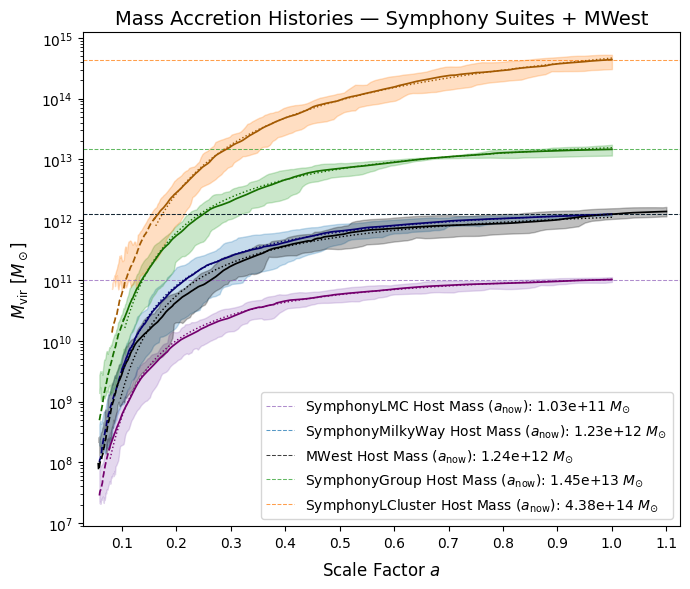

In [14]:
## STATISTICS + PLOTTER:

## STATISTICS: computes mean, median, standard deviation and 16-84% confidence band
def compute_MAH_stats(suite_data):

    masses = suite_data["masses"]                    # (N, T)
    scale_factors = suite_data["scale_factors"]      # (T,)
    redshifts = suite_data["redshifts"]              # (T,)
    particle_mass = suite_data["particle_mass"]
    a_now = suite_data["a_now"]

    # keep all masses for plotting
    mean_plot = np.nanmean(masses, axis = 0)

    # remove unresolved masses from the statistics themselves (continuation from the "ok" cut in load_MAH_suite_data)
    mass_cut = min_particles * particle_mass
    masses_resolved = np.where(masses >= mass_cut, masses, np.nan)
    n_resolved = np.sum(~np.isnan(masses_resolved), axis = 0)
    valid_mask = n_resolved > 0

    # fraction of hosts below 300 particle resolution
    ## transition from dashed to solid happens when < 5% of the hosts are resolved with fewer than 300 particles 
    n_hosts_total = np.sum(~np.isnan(masses), axis = 0)
    n_hosts_unresolved = np.sum((masses < mass_cut) & ~np.isnan(masses), axis = 0)
    frac_unresolved = np.divide(n_hosts_unresolved, n_hosts_total, out = np.ones_like(n_hosts_unresolved, dtype = float), where = n_hosts_total > 0)
    resolution_mask = frac_unresolved <= 0.05

    mean = np.nanmean(masses_resolved, axis = 0)              # (T,)
    median = np.nanmedian(masses_resolved, axis = 0)          # (T,)
    std = np.nanstd(masses_resolved, axis = 0)                # (T,)
    p16 = np.nanpercentile(masses_resolved, 16, axis = 0)     # (T,)
    p84 = np.nanpercentile(masses_resolved, 84, axis = 0)     # (T,)

    ## final snapshot should be a_now
    ## mass at a_now = value at the redshift-closest-to-zero snapshot on this suite's reference axis
    idx_now = int(np.argmin(np.abs(redshifts)))
    final_mass_anow = float(mean[idx_now]) if np.isfinite(mean[idx_now]) else np.nan

    return {"suite": suite_data["suite"],
            "scale_factors": scale_factors,
            "redshifts": redshifts,
            "a_now": a_now,
            
            # statistics
            "mean": mean,
            "median": median,
            "std": std,
            "p16": p16,
            "p84": p84,
            
            # plotting only
            "mean_plot": mean_plot,
            
            "final_mass_anow": final_mass_anow,
            "particle_mass": particle_mass,
            
            "frac_unresolved": frac_unresolved,
            "resolution_mask": resolution_mask,
            "valid_mask": valid_mask}

## function to run the statistics over all suites
def compute_all_MAH_stats(all_MAH_data):
    
    all_MAH_stats = {suite: compute_MAH_stats(suite_data) for suite, suite_data in all_MAH_data.items()}
    
    return all_MAH_stats

#####################################################################################################################

## FITTING:

## simple exponential MAH model: M(z_rel) = M(a_now)*exp(-alpha*z_rel) [Wechsler+ 2002 form] 
def mah_wechsler_model(z, M0, alpha):
    
    return M0*np.exp(-alpha*z)

## power-law correction
def mah_mcbride_model(z, M0, beta, gamma):
    return M0 * (1 + z)**beta * np.exp(-gamma * z)

## fit M(z) = M0*exp(-alpha*z) to the MEAN MAH of the suite
## returns dict with keys:
## M0: fitted mass at a_now (z_relative = 0)
## alpha: fitted formation rate parameter
## x_fit: x-values for plotting the fit curve
## y_fit: y-values for plotting the fit curve
## popt: raw [M0, alpha]
## pcov: covariance matrix
def fit_mah_wechsler(suite_stats, x_axis):

    valid = suite_stats["valid_mask"]
    x = suite_stats["redshifts"][valid]     ## always fit in redshift space, regardless of what the toggle is set to
    y = suite_stats["mean"][valid]

    std = suite_stats["std"][valid]
    mass_cut = min_particles * suite_stats["particle_mass"]

    ## fit in log-mass space
    fit_mask = (x >= 0) & suite_stats["resolution_mask"][valid] & np.isfinite(y) & (std > 0)
    x_fit_data = x[fit_mask]
    y_fit_data = y[fit_mask]

    log_y = np.log(y_fit_data)
    log_sigma = std[fit_mask] / y_fit_data          ## σ_log(M) ≈ σ_M / M
    p0 = [np.log(suite_stats["final_mass_anow"]), 0.5]
    popt, pcov = curve_fit(lambda z, logM0, alpha: logM0 - alpha * z,
                           x_fit_data, log_y, sigma = log_sigma, absolute_sigma = True,
                           p0 = p0, maxfev = 10000)
    
    logM0, alpha = popt
    M0 = np.exp(logM0)

    ## generate smooth curve for plotting
    ## starts at the x-value corresponding to the 5% hosts above 300 particles threshold
    z_start = x_fit_data.max()
    x_smooth = np.linspace(0, z_start, 500)
    y_smooth = mah_wechsler_model(x_smooth, M0, alpha)

    ## convert x_smooth to scale factor if required by toggle
    x_plot = x_smooth if x_axis == "redshift" else (1.0/(x_smooth + 1.0))

    return {"M0": M0,
            "alpha": alpha,
            "x_fit": x_plot,
            "y_fit": y_smooth,
            "popt": popt,
            "pcov": pcov}

def fit_mah_mcbride(suite_stats, x_axis):

    valid = suite_stats["valid_mask"]
    x = suite_stats["redshifts"][valid]
    y = suite_stats["mean"][valid]
    
    std = suite_stats["std"][valid]
    mass_cut = min_particles * suite_stats["particle_mass"]

    ## same as in the wechsler fit
    fit_mask = (x >= 0) & suite_stats["resolution_mask"][valid] & np.isfinite(y) & (std > 0)
    x_fit_data = x[fit_mask]
    y_fit_data = y[fit_mask]

    ## fit in log-space: log(M) = log(M0) + beta*log(1+z) - gamma*z
    log_y = np.log(y_fit_data)
    log_sigma = std[fit_mask] / y_fit_data                ## σ_log(M) ≈ σ_M / M
    p0 = [np.log(suite_stats["final_mass_anow"]), 0.5, 0.5]
    popt, pcov = curve_fit(lambda z, logM0, beta, gamma: logM0 + beta * np.log(1 + z) - gamma * z,
                           x_fit_data, log_y, sigma = log_sigma, absolute_sigma = True,
                           p0 = p0, maxfev = 10000)
    
    logM0, beta, gamma = popt
    M0 = np.exp(logM0)

    ## starts at the x-value corresponding to the 5% hosts above 300 particles threshold
    z_start = x_fit_data.max()
    x_smooth = np.linspace(0, z_start, 500)
    y_smooth = mah_mcbride_model(x_smooth, M0, beta, gamma)
    x_plot = x_smooth if x_axis == "redshift" else (1.0 / (x_smooth + 1.0))

    return {"M0": M0,
            "beta": beta,
            "gamma": gamma,
            "x_fit": x_plot,
            "y_fit": y_smooth,
            "popt": popt,
            "pcov": pcov}


def fit_all_mah_wechsler(all_MAH_stats, x_axis):
    return {suite: fit_mah_wechsler(suite_stats, x_axis = x_axis) for suite, suite_stats in all_MAH_stats.items()}

def fit_all_mah_mcbride(all_MAH_stats, x_axis):
    return {suite: fit_mah_mcbride(suite_stats, x_axis = x_axis) for suite, suite_stats in all_MAH_stats.items()}

def fit_mah_suite(suite_stats, suite, x_axis):
    model = mah_fit_model.get(suite, "wechsler")   ## default to wechsler if suite not in dict
    if model == "wechsler":
        return fit_mah_wechsler(suite_stats, x_axis)
    elif model == "mcbride":
        return fit_mah_mcbride(suite_stats, x_axis)

def fit_all_mah(all_MAH_stats, x_axis):
    return {suite: fit_mah_suite(suite_stats, suite, x_axis) for suite, suite_stats in all_MAH_stats.items()}

#####################################################################################################################

## MAIN PLOTTER:

## plotting helpers:

## getting the correct x-axis
def get_xaxis(suite_stats, x_axis):
    
    if x_axis == "scale_factor":
        return suite_stats["scale_factors"]
    elif x_axis == "redshift":
        return suite_stats["redshifts"]
    else:
        raise ValueError(f"x_axis must be 'scale_factor' or 'redshift', but got {x_axis!r}")

## configuring axes
def ax_config_MAH(ax, x_axis, x_lim = None, title = None, yscale = "log"):
    
    ax.set_yscale(yscale)
    ax.set_ylabel(r"$M_\mathrm{vir}\ [M_\odot]$", fontsize = mah_label_fs, labelpad = 8)

    ax.tick_params(axis = "both", labelsize = mah_tick_fs)

    if x_axis == "scale_factor":
        ax.set_xticks(MAH_ticks_sf)
        ax.set_xlabel(r"Scale Factor $a$", fontsize = mah_label_fs, labelpad = 8)

        if x_lim is not None:
            ax.set_xlim(x_lim)

    elif x_axis == "redshift":
        ax.set_xscale("log")
        ax.set_xticks(MAH_ticks_z)
        ax.set_xticklabels(z_labels)
        ax.set_xlabel(r"Redshift $z$", fontsize = mah_label_fs)
        
        if x_lim is not None:
            ax.set_xlim(x_lim)
            
        else:
            ax.set_xlim(MAH_redshift_xlim)    ## default only if not overridden

    if title is not None:
        ax.set_title(title, fontsize = mah_title_fs)

## dashed to solid transition for mean MAHs
## segments share their boundary point with the neighboring segment so the transition renders as a continuous line rather than a gap
def plot_resolved_split(ax, x, y, resolved, valid, color, lw, alpha, label = None, zorder = None):
    
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return

    ## group into contiguous runs of the same resolved-state
    groups = []
    start = prev = idx[0]
    state = resolved[idx[0]]
    for i in idx[1:]:
        if i == prev + 1 and resolved[i] == state:
            prev = i
        else:
            groups.append((start, prev, state))
            start = prev = i
            state = resolved[i]
    groups.append((start, prev, state))

    labeled = False
    for gi, (s, e, state) in enumerate(groups):
        lo = s - 1 if gi > 0 else s                     ## overlap with previous group's last point
        hi = e + 1 if gi < len(groups) - 1 else e       ## overlap with next group's first point
        seg_label = label if (state and not labeled) else None
        if state:
            labeled = True
        ax.plot(x[lo:hi + 1], y[lo:hi + 1], color = color, lw = lw, alpha = alpha,
                linestyle = "-" if state else "--", label = seg_label, zorder = zorder)

## plotting per-suite data:
def plot_suite_MAH(ax, suite, suite_data, suite_stats, x_axis, show_hosts = True, show_confidence = True, show_fit = False, mah_fits = None):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    mass_cut = min_particles * suite_stats["particle_mass"]

    ## individual hosts --> split solid-dashed line at 300 particle masses
    if show_hosts:
        for host_sf, host_mass, a_now in zip(suite_data["host_scale_factors"], suite_data["host_masses"], suite_data["host_a_now"]):

            ## each host has its own time axis:
            host_x = host_sf if x_axis == "scale_factor" else (a_now / host_sf) - 1.0

            ## resolved if above the mass cut:
            resolved = host_mass >= mass_cut

            ## solid where resolved:
            ax.plot(np.where(resolved, host_x, np.nan), np.where(resolved, host_mass, np.nan),
                    color = color, lw = mah_host_lw, alpha = mah_host_alpha)

            ## dashed where unresolved:
            ax.plot(np.where(~resolved, host_x, np.nan), np.where(~resolved, host_mass, np.nan),
                    color = color, lw = mah_host_lw, alpha = mah_host_alpha, linestyle = "--")

    ## 16-84% confidence band:
    if show_confidence:
        ax.fill_between(x[valid], suite_stats["p16"][valid], suite_stats["p84"][valid], color = color, alpha = mah_confidence_band_alpha)

    ## mean --> split solid/dashed at 300 particles, with a continuous transition
    mean = suite_stats["mean_plot"]
    resolved_mean = suite_stats["resolution_mask"] & valid
    plot_resolved_split(ax, x, mean, resolved_mean, valid, color = avg_color, lw = mah_avg_lw, alpha = 1.0, label = suite, zorder = 3)

    ## exponential fit:
    if show_fit and mah_fits is not None and suite in mah_fits:
        fits = mah_fits[suite]
        ax.plot(fits["x_fit"], fits["y_fit"], color = avg_colors[suite], lw = 1.0, linestyle = ":", zorder = 4)

    ## final mass line:
    fm = suite_stats["final_mass_anow"]
    if np.isfinite(fm):
        ax.axhline(fm, color = colors[suite], linestyle = "--", lw = 0.75, alpha = 0.75, label = rf"Host Mass ($a_{{\rm now}}$): {fm:.2e}")


## adding the option to normalize by the z = 0 mass accretion history:
## for the normalized panel, normalize by a_now (1.0 for Symphony, a_lmc_50 for MWest)
def compute_normalized_masses(suite_data):

    host_scale_factors = suite_data["host_scale_factors"]
    host_masses = suite_data["host_masses"]
    host_a_now = suite_data["host_a_now"]

    final_masses = []

    for sf, m, a_now in zip(host_scale_factors, host_masses, host_a_now):
        idx_now = int(np.argmin(np.abs(sf - a_now)))
        fm = m[idx_now]
        final_masses.append(fm if np.isfinite(fm) else np.nan)
    final_masses = np.array(final_masses)

    masses = suite_data["masses"].copy()
    norm_masses = masses / final_masses[:, None]
    return norm_masses

def plot_suite_MAH_normalized(ax, suite, suite_data, suite_stats, x_axis, show_hosts, show_confidence = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    fm = suite_stats["final_mass_anow"]

    norm_masses = compute_normalized_masses(suite_data)
    norm_mean = np.nanmean(norm_masses, axis = 0)
    norm_p16 = np.nanpercentile(norm_masses, 16, axis = 0)
    norm_p84 = np.nanpercentile(norm_masses, 84, axis = 0)

    ## individual hosts normalized by their own mass at a_now:
    if show_hosts:
        
        for host_sf, host_mass, a_now in zip(suite_data["host_scale_factors"], suite_data["host_masses"], suite_data["host_a_now"]):
            host_x = host_sf if x_axis == "scale_factor" else (a_now / host_sf) - 1.0
            idx_now = int(np.argmin(np.abs(host_sf - a_now)))
            host_fm = host_mass[idx_now]
            if np.isfinite(host_fm) and host_fm != 0:
                ax.plot(host_x, host_mass / host_fm, color = color, lw = mah_host_lw, alpha = mah_host_alpha)

    if show_confidence:
        ax.fill_between(x[valid], norm_p16[valid], norm_p84[valid], color = color, alpha = mah_confidence_band_alpha)
    ax.plot(x[valid], norm_mean[valid], color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

## putting it all together:
## all_MAH_data = data dictionary from load_all_MAH_data
## all_MAH_stats = data dictionary from compute_all_MAH_stats
## outputs a single-panel figure (or double-panel if "dual" = True)

def plot_all_MAH(all_MAH_data, all_MAH_stats, suites, x_axis = "scale_factor", show_hosts = True, dual = False,
                 show_confidence = False, show_fit = False, figsize_single = (7, 6), figsize_dual = (14, 6),
                 title = "Mass Accretion Histories — Symphony Suites + MWest"):

    if suites is None:
        suites = [s for s in suite_list if s in all_MAH_data]

    figsize = figsize_dual if dual else figsize_single
    ncols = 2 if dual else 1
    
    fig, axes = plt.subplots(ncols = ncols, figsize = figsize, squeeze = False)
    
    ax_main = axes[0, 1] if dual else axes[0, 0]
    ax_norm = axes[0, 0] if dual else None

    ## compute fits if needed
    mah_fits = fit_all_mah(all_MAH_stats, x_axis = x_axis) if show_fit else None

    for suite in suites:
        plot_suite_MAH(ax_main, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis, show_hosts = show_hosts,
                       show_confidence = show_confidence, show_fit = show_fit, mah_fits = mah_fits)

        if dual:
            plot_suite_MAH_normalized(ax_norm, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis,
                                      show_hosts = show_hosts, show_confidence = show_confidence)

    ## compute x-axis limits from data to avoid clipping any hosts
    if x_axis == "scale_factor":
        x_min = min(sf.min() for s in suites for sf in all_MAH_data[s]["host_scale_factors"])
        x_max = max(sf.max() for s in suites for sf in all_MAH_data[s]["host_scale_factors"])
        x_lim = (x_min - 0.025, x_max + 0.025)
        
    elif x_axis == "redshift":
        all_z = [(all_MAH_data[s]["a_now"] / sf - 1.0) for s in suites for sf in all_MAH_data[s]["host_scale_factors"]]
        z_min = max(min(z.min() for z in all_z), 0.05)                ## don't go below 0.05 on log axis
        z_max_data = min(max(z.max() for z in all_z), 16.0)
        x_lim = (z_max_data, z_min)                                   ## reversed for redshift axis

    ax_config_MAH(ax_main, x_axis, x_lim = x_lim, title = title, yscale = "log")
    
    if dual:
        ax_config_MAH(ax_norm, x_axis, x_lim = x_lim, title = f"{title} (Normalized)", yscale = "log")
        ax_norm.set_ylabel(r"$M_\mathrm{vir}\ /\ M_\mathrm{vir}(a_\mathrm{now})$", fontsize = mah_label_fs)

    legend_handles = []
    for s in suites:
        if show_fit and mah_fits is not None and s in mah_fits:
            fit = mah_fits[s]
            if mah_fit_model.get(s, "wechsler") == "wechsler":
                alpha_str = f"α = {fit['alpha']:.2f}, $M_0$ = {fit['M0']:.2e}"
                print(f"{s}: {alpha_str}")
            else:
                alpha_str = f"β = {fit['beta']:.2f}, γ = {fit['gamma']:.2f}, $M_0$ = {fit['M0']:.2e}"
                print(f"{s}: {alpha_str}")
        else:
            alpha_str = ""
        #legend_handles.append(Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = f"{s}{alpha_str}"))

        ## add a_now Mvir to axis legends
        if np.isfinite(all_MAH_stats[s]["final_mass_anow"]):
            legend_handles.append(Line2D([0], [0], color = colors[s], lw = 0.75, alpha = 0.75, linestyle = "--",
                                         label = rf"{s} Host Mass ($a_{{\rm now}}$): {all_MAH_stats[s]['final_mass_anow']:.2e} $M_{{\odot}}$"))
            
    ax_main.legend(handles = legend_handles, loc = "best", fontsize = mah_legend_fs)
    
    if dual:
        ## normalized panel only needs suite name labels, no final mass lines
        norm_handles = [Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = s) for s in suites]
        ax_norm.legend(handles = norm_handles, loc = "best", fontsize = mah_legend_fs)

    
    fig.tight_layout()

    return fig, axes

#####################################################################################################################

## entrypoint to generate stats & plots
MAH_stats = compute_all_MAH_stats(MAH_data)
fig, axes = plot_all_MAH(MAH_data, MAH_stats, suite_list, x_axis = "scale_factor", show_hosts = False, dual = False,
                         show_confidence = True, show_fit = True)

#fig.savefig(f"updating MAHs with normalization.png", dpi = 100, bbox_inches = "tight")
plt.show()

## MAH UNITS HAVE BEEN CHECKED
## a_now logic has been implemented
## logic has been double checked --> Rockstar used for getting host data (Symfind has no host data)

<a id = "subhalo_mass_functions"></a>
## Subhalo Mass Functions:
[Back to Table of Contents](#table_of_contents)

* "Subhalo mass functions" are histograms of # of subhalos separated by mass.
* 300 particle cut and "ok" survival cut also apply here, but only as a threshold for transitioning the line from solid to dashed
* Host is NOT included; this focuses on SUBHALOS
* Two kinds: differential and cumulative
* Differential --> slope expected to be ~ -1.9 to -2.0
* Cumulative --> slope expected to be ~ -0.9 to -1.0
* Symfind is used in place of Rockstar here (more accurate halo finder, especially for smaller subhalos)

For MilkyWay-est only:
* Because each host has its own "analysis snapshot" (effectively its "z = 0" snapshot), these values are read in from the results of the script above.

In [15]:
## HELPERS + DATALOADER:

## returns the snapshot closest to a given redshift
def snap_at_redshift(sim_dir, target_z):
    
    scale = symlib.scale_factors(sim_dir)
    a_target = 1.0 / (1.0 + target_z)
    
    return int(np.argmin(np.abs(scale - a_target)))

## read in all data relevant for the ratio and absolute SHMFs
def calculate_shmfs(r, s, snap, ratio_bins, abs_bins, particle_mass):

    ## read_rockstar() for host data
    host = r[0, snap]
    r_host = host["rvir"]
    m_host = host["m"]

    ## read_symfind() for subhalo data
    sub = s[:, snap]
    sub_mass = sub["m"]
    sub_ok = sub["ok"]
    sub_x = sub["x"]

    ## distance from host center
    ## Symfind x is already the displacement from host center, so no need to subtract host position vector
    r2 = np.sum(sub_x**2, axis = 1)

    ## 300 particle + ok + inside host Rvir
    valid = ((sub_mass >= 300 * particle_mass) & sub_ok & (r2 < r_host**2))
    m_sub = sub_mass[valid]

    ## no valid subhalos
    if len(m_sub) == 0:

        empty = np.zeros(len(ratio_bins) - 1)

        return (empty,       ## ratio cumulative
                empty,       ## ratio differential
                empty,       ## absolute cumulative
                empty,       ## absolute differential
                m_host)

    ## RATIO SHMF
    ratio = m_sub / m_host
    n_ratio, _ = np.histogram(ratio, bins = ratio_bins)

    ## cumulative: N(> Msub/Mhost)
    n_ratio_cumul = np.cumsum(n_ratio[::-1])[::-1].astype(float)

    ## differential: dN / d(log Msub/Mhost)
    dlog_ratio = np.diff(np.log10(ratio_bins))

    n_ratio_diff = (n_ratio / dlog_ratio).astype(float)

    
    ## ABSOLUTE SHMF
    n_abs, _ = np.histogram(m_sub, bins = abs_bins)

    ## cumulative: N(> Msub)
    n_abs_cumul = np.cumsum(n_abs[::-1])[::-1].astype(float)

    ## differential: dN / d(log Msub)
    dlog_abs = np.diff(np.log10(abs_bins))

    n_abs_diff = (n_abs / dlog_abs).astype(float)

    return (n_ratio_cumul, n_ratio_diff, n_abs_cumul, n_abs_diff, m_host)

    
#######################################################################################################################

## CACHE: loops over dataloaders and stores all the important information into dictionaries
cached_data_ratio = {}  ## Msub/Mhost --> used for suite panels
cached_data_abs   = {}  ## absolute Msub --> used for redshift panels

for suite in suite_list:

    n_hosts = symlib.n_hosts(suite)

    ## temporary storage for this suite
    ## creating dictionaries where z is the key and [] is the value
    ratio_results = {z: [] for z in redshifts_shmf}
    abs_results = {z: [] for z in redshifts_shmf}

    ratio_conv = {z: [] for z in redshifts_shmf}
    abs_conv = {z: [] for z in redshifts_shmf}

    host_ref_masses = {z: [] for z in redshifts_shmf}

    ratio_bins = np.logspace(np.log10(shmf_ratio_min), np.log10(shmf_ratio_max), n_bins + 1)
    ratio_centers = np.sqrt(ratio_bins[:-1] * ratio_bins[1:])

    abs_bins = None
    abs_centers = None

    ## getting cosmological parameters
    sim_dir_0 = symlib.get_host_directory(base_dir, suite, 0)
    params = symlib.simulation_parameters(sim_dir_0)
    h100 = params["h100"]
    Om0 = params["Om0"]
    particle_mass = params["mp"]
    physical_particle_mass = particle_mass / h100        ## params needs to be converted from comoving units
    cosmo = FlatLambdaCDM(H0 = h100 * 100, Om0 = Om0)

    if suite == "MWest":
        host_ids = MWest_halos
    else:
        host_ids = list(range(n_hosts))

    for i_host, host_id in enumerate(host_ids):

        print(f"{suite}: Host {i_host+1}/{n_hosts}")

        sim_dir = symlib.get_host_directory(base_dir, suite, host_id)

        ## read everything ONCE
        r, r_hist = symlib.read_rockstar(sim_dir, comoving = False)
        s, s_hist = symlib.read_symfind(sim_dir)
        scale_factors = symlib.scale_factors(sim_dir)

        if abs_bins is None:
            m_min_suite = min_particles * physical_particle_mass * 0.1
            abs_bins = np.logspace(np.log10(m_min_suite), np.log10(m_max), n_bins + 1)
            abs_centers = np.sqrt(abs_bins[:-1] * abs_bins[1:])


        ## define this host's reference epoch: a_lmc_50 for MWest, 1.0 (z ~= 0) for everyone else
        if suite == "MWest":
            a_now = Table2_MWest[host_id][0]
        else:
            a_now = 1.0

        ## a_now-relative redshift transform: 1+z = a_now/a  -->  a = a_now/(1+z)
        ## this reduces to the ordinary a = 1/(1+z) whenever a_now = 1.0
        snap_lookup = {z: int(np.argmin(np.abs(scale_factors - a_now/(1.0 + z)))) for z in redshifts_shmf}

        print("\nCosmic times at target snapshots:")
        
        for z in redshifts_shmf:
            
            snap = snap_lookup[z]
            a_snap = scale_factors[snap]
            z_snap = 1.0 / a_snap - 1.0
            t_snap = cosmo.age(z_snap).value

            if suite == "MWest" and z == 0.0:
                print(f"LMC infall snapshot: a_target = {a_now:.4f}, a_used = {a_snap:.4f}, z_used = {z_snap:.3f}, t = {t_snap:.2f} Gyr")
                
            else:
                print(f"Target z = {z:.1f}: z_used = {z_snap:.3f}, a = {a_snap:.4f}, t = {t_snap:.2f} Gyr")

            ## CALCULATE BOTH SHMFs
            (ratio_cumul, ratio_diff, abs_cumul, abs_diff, m_host) = calculate_shmfs(r, s, snap, ratio_bins, abs_bins, physical_particle_mass)

            ## STORE RATIO SHMF
            ratio_results[z].append((ratio_cumul, ratio_diff))
            ratio_conv[z].append(min_particles * physical_particle_mass / m_host)

            ## STORE ABSOLUTE SHMF
            abs_results[z].append((abs_cumul, abs_diff))
            abs_conv[z].append(min_particles * physical_particle_mass)

            ## HOST REFERENCE INFORMATION
            host_ref_masses[z].append({"m_ref": m_host,
                                       "a_ref": a_snap,
                                       "z_ref": z_snap})

## convert to cached format
    for z in redshifts_shmf:

        if ratio_results[z]:
            nc = np.array([x[0] for x in ratio_results[z]])
            nd = np.array([x[1] for x in ratio_results[z]])
            cached_data_ratio[(suite, z)] = (ratio_centers, nc, nd, np.array(ratio_conv[z]), np.array(host_ref_masses[z]))

        if abs_results[z]:
            nc = np.array([x[0] for x in abs_results[z]])
            nd = np.array([x[1] for x in abs_results[z]])

            cached_data_abs[(suite, z)] = (abs_centers, nc, nd, np.array(abs_conv[z]), np.array(host_ref_masses[z]))

print("\nAll data cached.")

SymphonyLMC: Host 1/39

Cosmic times at target snapshots:
Target z = 2.0: z_used = 1.993, a = 0.3341, t = 3.31 Gyr
Target z = 1.0: z_used = 0.990, a = 0.5024, t = 5.91 Gyr
Target z = 0.5: z_used = 0.504, a = 0.6651, t = 8.56 Gyr
Target z = 0.2: z_used = 0.258, a = 0.7951, t = 10.62 Gyr
Target z = 0.1: z_used = 0.093, a = 0.9148, t = 12.43 Gyr
Target z = 0.0: z_used = 0.000, a = 1.0000, t = 13.65 Gyr
SymphonyLMC: Host 2/39

Cosmic times at target snapshots:
Target z = 2.0: z_used = 1.993, a = 0.3341, t = 3.31 Gyr
Target z = 1.0: z_used = 0.990, a = 0.5024, t = 5.91 Gyr
Target z = 0.5: z_used = 0.504, a = 0.6651, t = 8.56 Gyr
Target z = 0.2: z_used = 0.258, a = 0.7951, t = 10.62 Gyr
Target z = 0.1: z_used = 0.093, a = 0.9148, t = 12.43 Gyr
Target z = 0.0: z_used = 0.000, a = 1.0000, t = 13.65 Gyr
SymphonyLMC: Host 3/39

Cosmic times at target snapshots:
Target z = 2.0: z_used = 1.993, a = 0.3341, t = 3.31 Gyr
Target z = 1.0: z_used = 0.990, a = 0.5024, t = 5.91 Gyr
Target z = 0.5: z_used

In [16]:
## STATISTICS
## computes summary statistics from the per-host SHMF array
## returns:
## mean_ncumul: mean cumulative SHMF across hosts, shape (n_bins,)
## p16, p84: 16th and 84th percentiles of host-to-host scatter
## median_conv_mass: median convergence limit in M_sun across hosts
def compute_shmf_stats(all_n, conv_masses):
    
    mean_n = np.mean(all_n, axis = 0)
    p16 = np.percentile(all_n, 16, axis = 0)
    p84 = np.percentile(all_n, 84, axis = 0)
    median_conv_mass = np.median(conv_masses)

    print(f"Convergence limit: {median_conv_mass:.3e}")

    return mean_n, p16, p84, median_conv_mass

## fits a power law (linear in log-log space) to y
## lower bound is the mass bin corresponding to the 300 particles "convergence limit"
## upper bound is the mass bin corresponding closest to where the mean SHMF crosses over 10^-1
def fit_powerlaw(bin_centers, y, solid_mask, p16, p84, y_floor = 1e-1):
    
    fit_mask = solid_mask & (y > y_floor)

    if np.sum(fit_mask) < 2:
        print("Warning: fewer than 2 bins in fit range, skipping fit.")
        return None

    log_x = np.log10(bin_centers[fit_mask])
    log_y = np.log10(y[fit_mask])

    ## weights: inverse variance in log space from 16-84% band
    log_p16 = np.log10(p16.clip(min = 0.01)[fit_mask])
    log_p84 = np.log10(p84.clip(min = 0.01)[fit_mask])
    log_sigma = (log_p84 - log_p16) / 2.0
    log_sigma = np.where(log_sigma > 0, log_sigma, np.min(log_sigma[log_sigma > 0]))  ## avoid zero weights
    weights = 1.0 / log_sigma**2

    slope, intercept = np.polyfit(log_x, log_y, 1, w = weights)

    ## weighted R²
    log_y_pred = slope * log_x + intercept
    log_y_mean = np.average(log_y, weights = weights)
    ss_res = np.sum(weights * (log_y - log_y_pred)**2)
    ss_tot = np.sum(weights * (log_y - log_y_mean)**2)
    r2 = 1 - ss_res / ss_tot

    return slope, intercept, r2

## mixes in increasing amounts of red into the colors based on the redshift of the line being plotted
## objective is to visually represent the transition from high to low redshift
## MWest and Cluster are special cases, since MWest is black and Cluster is already red
## for those cases:
## MWest transitions from gray at high redshifts to black at low redshifts
## Cluster transitions from deep red at high redshifts to normal red at low redshifts
def redshift_color(suite, target_z, max_red_mix = 0.25):
    z_max = max(redshifts_shmf) if len(redshifts_shmf) > 1 else 1.0
    t = target_z / z_max        ## 0 at z=0, 1 at z = z_max

    base = np.array(mcolors.to_rgb(avg_colors[suite]))

    if suite == "MWest":
        ## black at z = 0, light gray at z = z_max
        gray = np.array([0.65, 0.65, 0.65])
        return tuple((1 - t) * base + t * gray)

    elif suite == "SymphonyCluster":
        ## lighter red at z = 0, darker red at z = z_max
        dark_red = np.array([0.45, 0.0, 0.0])
        return tuple((1 - t) * base + t * dark_red)

    else:
        ## all other suites: blend toward red with increasing redshift
        red = np.array([1.0, 0.0, 0.0])
        return tuple((1 - t) * base + t * (red * max_red_mix + base * (1 - max_red_mix)))
    
#######################################################################################################################

## CORE PLOTTER:
## plots the SHMF line for one suite and one redshift on the given axes
## affected by the show_host_shmf and show_confidence_shmf toggles
## line_color and line_label are passed in by the panel function
def plot_shmf_line(ax, suite, target_z, line_color, line_label, use_ratio = True):

    cache = cached_data_ratio if use_ratio else cached_data_abs

    ## unpacking the dictionary created in the previous step
    bin_centers, all_ncumul, all_ndiff, conv_masses, host_masses = cache[(suite, target_z)]
    #median_host_mass = np.median(host_masses)
    n_hosts = all_ncumul.shape[0]

    ## choose differential or cumulative:
    if show_differential:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ndiff, conv_masses)
        ylabel = r"$dN_{\rm sub}/d\log M_{\rm sub}$"
        all_n = all_ndiff

    else:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ncumul, conv_masses)
        ylabel = r"$N_{\rm sub}(> M_{\rm sub})$"
        all_n = all_ncumul

    ## solid-dashed split at the bin where x = median_conv_mass (min_particles * mp)
    split_idx = np.searchsorted(bin_centers, median_conv_mass)
    solid_mask = np.arange(len(bin_centers)) >= split_idx
    dashed_mask = ~solid_mask

    x0 = median_conv_mass
    y0 = np.interp(x0, bin_centers, mean_n)

    p16_0 = np.interp(x0, bin_centers, p16)
    p84_0 = np.interp(x0, bin_centers, p84)
    p16_plot = p16.clip(min = 0.01)
    p84_plot = p84.clip(min = 0.01)

    ## plot per-host lines:
    if show_hosts_shmf:
        for i in range(n_hosts):
            ax.plot(bin_centers[solid_mask], all_n[i][solid_mask], color = line_color, lw = shmf_host_lw, alpha = shmf_host_alpha)

            if show_dashed:
                ax.plot(bin_centers[dashed_mask], all_n[i][dashed_mask], color = line_color,
                        lw = shmf_host_lw, alpha = shmf_host_alpha, linestyle = "--")

    ## plot mean line:
    ax.plot(np.r_[x0, bin_centers[solid_mask]], np.r_[y0, mean_n[solid_mask]], color = line_color, lw = shmf_avg_lw, label = line_label)
    if show_dashed:
        ax.plot(np.r_[bin_centers[dashed_mask], x0], np.r_[mean_n[dashed_mask], y0], color = line_color, lw = shmf_avg_lw, linestyle = "--")

    ## plot 16-84% confidence band
    if show_confidence_shmf:
        ax.fill_between(np.r_[x0, bin_centers[solid_mask]],
                        np.r_[p16_0, p16_plot[solid_mask]],
                        np.r_[p84_0, p84_plot[solid_mask]],
                        color = line_color, alpha = shmf_confidence_band_alpha)
        if show_dashed:
            ax.fill_between(np.r_[bin_centers[dashed_mask], x0],
                            np.r_[p16_plot[dashed_mask], p16_0],
                            np.r_[p84_plot[dashed_mask], p84_0],
                            color = line_color, alpha = shmf_confidence_band_alpha)

    ## vertical line at convergence limit:
    if convergence:
        ax.axvline(median_conv_mass, color = line_color, lw = 0.75, linestyle = ":")

    ## linear fit:
    slope_out = None
    r2_out = None
    if show_shmf_fit:
        result = fit_powerlaw(bin_centers, mean_n, solid_mask, p16, p84)
        if result is not None:
            slope, intercept, r2 = result
            slope_out = slope
            r2_out = r2
            x_plot = bin_centers[solid_mask & (mean_n > 0)]
            y_plot = 10**(intercept + slope * np.log10(x_plot))
            ax.plot(x_plot, y_plot, color = line_color, lw = 1.5, linestyle = ":")
            print(f"{labels[suite]} z = {target_z}: slope = {slope:.3f}, intercept = {intercept:.3f}, R² = {r2:.4f}")

    return ylabel, slope_out, r2_out

## apply axes formatting and legend, shared by both the "suite" and "redshift" panel ordering modes
def finalize_panel(ax, ylabel, key_list, slope_dict, r2_dict, use_ratio = True):

    ax.set_xscale("log")
    ax.set_yscale("log")

    if use_ratio:
        ax.set_xlabel(r"$M_{\rm sub}/M_{\rm host}$", fontsize = 16)
        ax.set_xlim(shmf_ratio_min, shmf_ratio_max)

    else:
        ax.set_xlabel(r"$M_{\rm sub}\ [M_\odot]$", fontsize = 16)
        ax.set_xlim(1e6, max(x_max_shmf[s] for s in suite_list))
    ax.set_ylabel(ylabel, fontsize = 16)
    ax.set_ylim(1e-1, 1e4)

    handles, leg_labels = ax.get_legend_handles_labels()
    new_labels = []
    for lbl, key in zip(leg_labels, key_list):
        #r2 = r2_dict.get(key, None)
        slope = slope_dict.get(key, None)
        if slope is not None:
            new_labels.append(f"{lbl} (slope = {slope:.3f})")
            #new_labels.append(f"{lbl} (R² = {r2:.3f}, slope = {slope:.3f})")
        else:
            new_labels.append(lbl)
    ax.legend(handles, new_labels, fontsize = 12, framealpha = 0.75)
    

## PANEL MODE: one panel per redshift, one line per suite
def plot_redshift_panel(ax, target_z):
    
    print(f"\nPlotting panel for z = {target_z}...")
    
    ylabel = None
    slope_dict = {}
    r2_dict = {}

    for suite in suite_list:
        line_color = avg_colors[suite]
        line_label = labels[suite]
        ylabel, slope, r2 = plot_shmf_line(ax, suite, target_z, line_color, line_label, use_ratio = False)
        slope_dict[suite] = slope
        r2_dict[suite] = r2

    if target_z == 0.0:
        ax.set_title(r"$z=0$ (MWest: LMC infall)", fontsize = 15)
    else:
        ax.set_title(f"z = {target_z}", fontsize = 15)
        
    finalize_panel(ax, ylabel, suite_list, slope_dict, r2_dict, use_ratio = False)

    print(f"Panel for z = {target_z} complete.")

## PANEL MODE: one panel per suite, one line per redshift
def plot_suite_panel(ax, suite):
    
    print(f"\nPlotting panel for {suite}...")
    
    ylabel = None
    slope_dict = {}
    r2_dict = {}

    for target_z in redshifts_shmf:
        line_color = redshift_color(suite, target_z)
        
        if suite == "MWest" and target_z == 0.0:
            line_label = "LMC infall (50 kpc)"
        
        else:
            line_label = f"z = {target_z}"
        
        ylabel, slope, r2 = plot_shmf_line(ax, suite, target_z, line_color, line_label, use_ratio = True)
        slope_dict[target_z] = slope
        r2_dict[target_z] = r2

    ax.set_title(labels[suite], fontsize = 15)
    finalize_panel(ax, ylabel, redshifts_shmf, slope_dict, r2_dict, use_ratio = True)
    
    print(f"Panel for {suite} complete.")

The cell below adjusts all the SHMF toggles and runs the plotter:

Starting SHMF plot — panel_by = 'suite'
Suites: ['SymphonyLMC', 'SymphonyMilkyWay', 'MWest', 'SymphonyGroup', 'SymphonyLCluster']
Redshifts: [2.0, 1.0, 0.5, 0.25, 0.1, 0.0]
Toggles — host lines: False, confidence band: False, linear fit: True, differential: False, convergence: True


Plotting panel for SymphonyLMC...
Convergence limit: 4.505e-04
SymphonyLMC z = 2.0: slope = -0.858, intercept = -1.325, R² = 0.9982
Convergence limit: 2.448e-04
SymphonyLMC z = 1.0: slope = -0.959, intercept = -1.742, R² = 0.9968
Convergence limit: 1.795e-04
SymphonyLMC z = 0.5: slope = -0.866, intercept = -1.470, R² = 0.9974
Convergence limit: 1.633e-04
SymphonyLMC z = 0.25: slope = -1.028, intercept = -2.044, R² = 0.9958
Convergence limit: 1.487e-04
SymphonyLMC z = 0.1: slope = -0.936, intercept = -1.766, R² = 0.9997
Convergence limit: 1.436e-04
SymphonyLMC z = 0.0: slope = -0.954, intercept = -1.861, R² = 0.9995
Panel for SymphonyLMC complete.

Plotting panel for SymphonyMilkyWay...
Convergence limit: 4

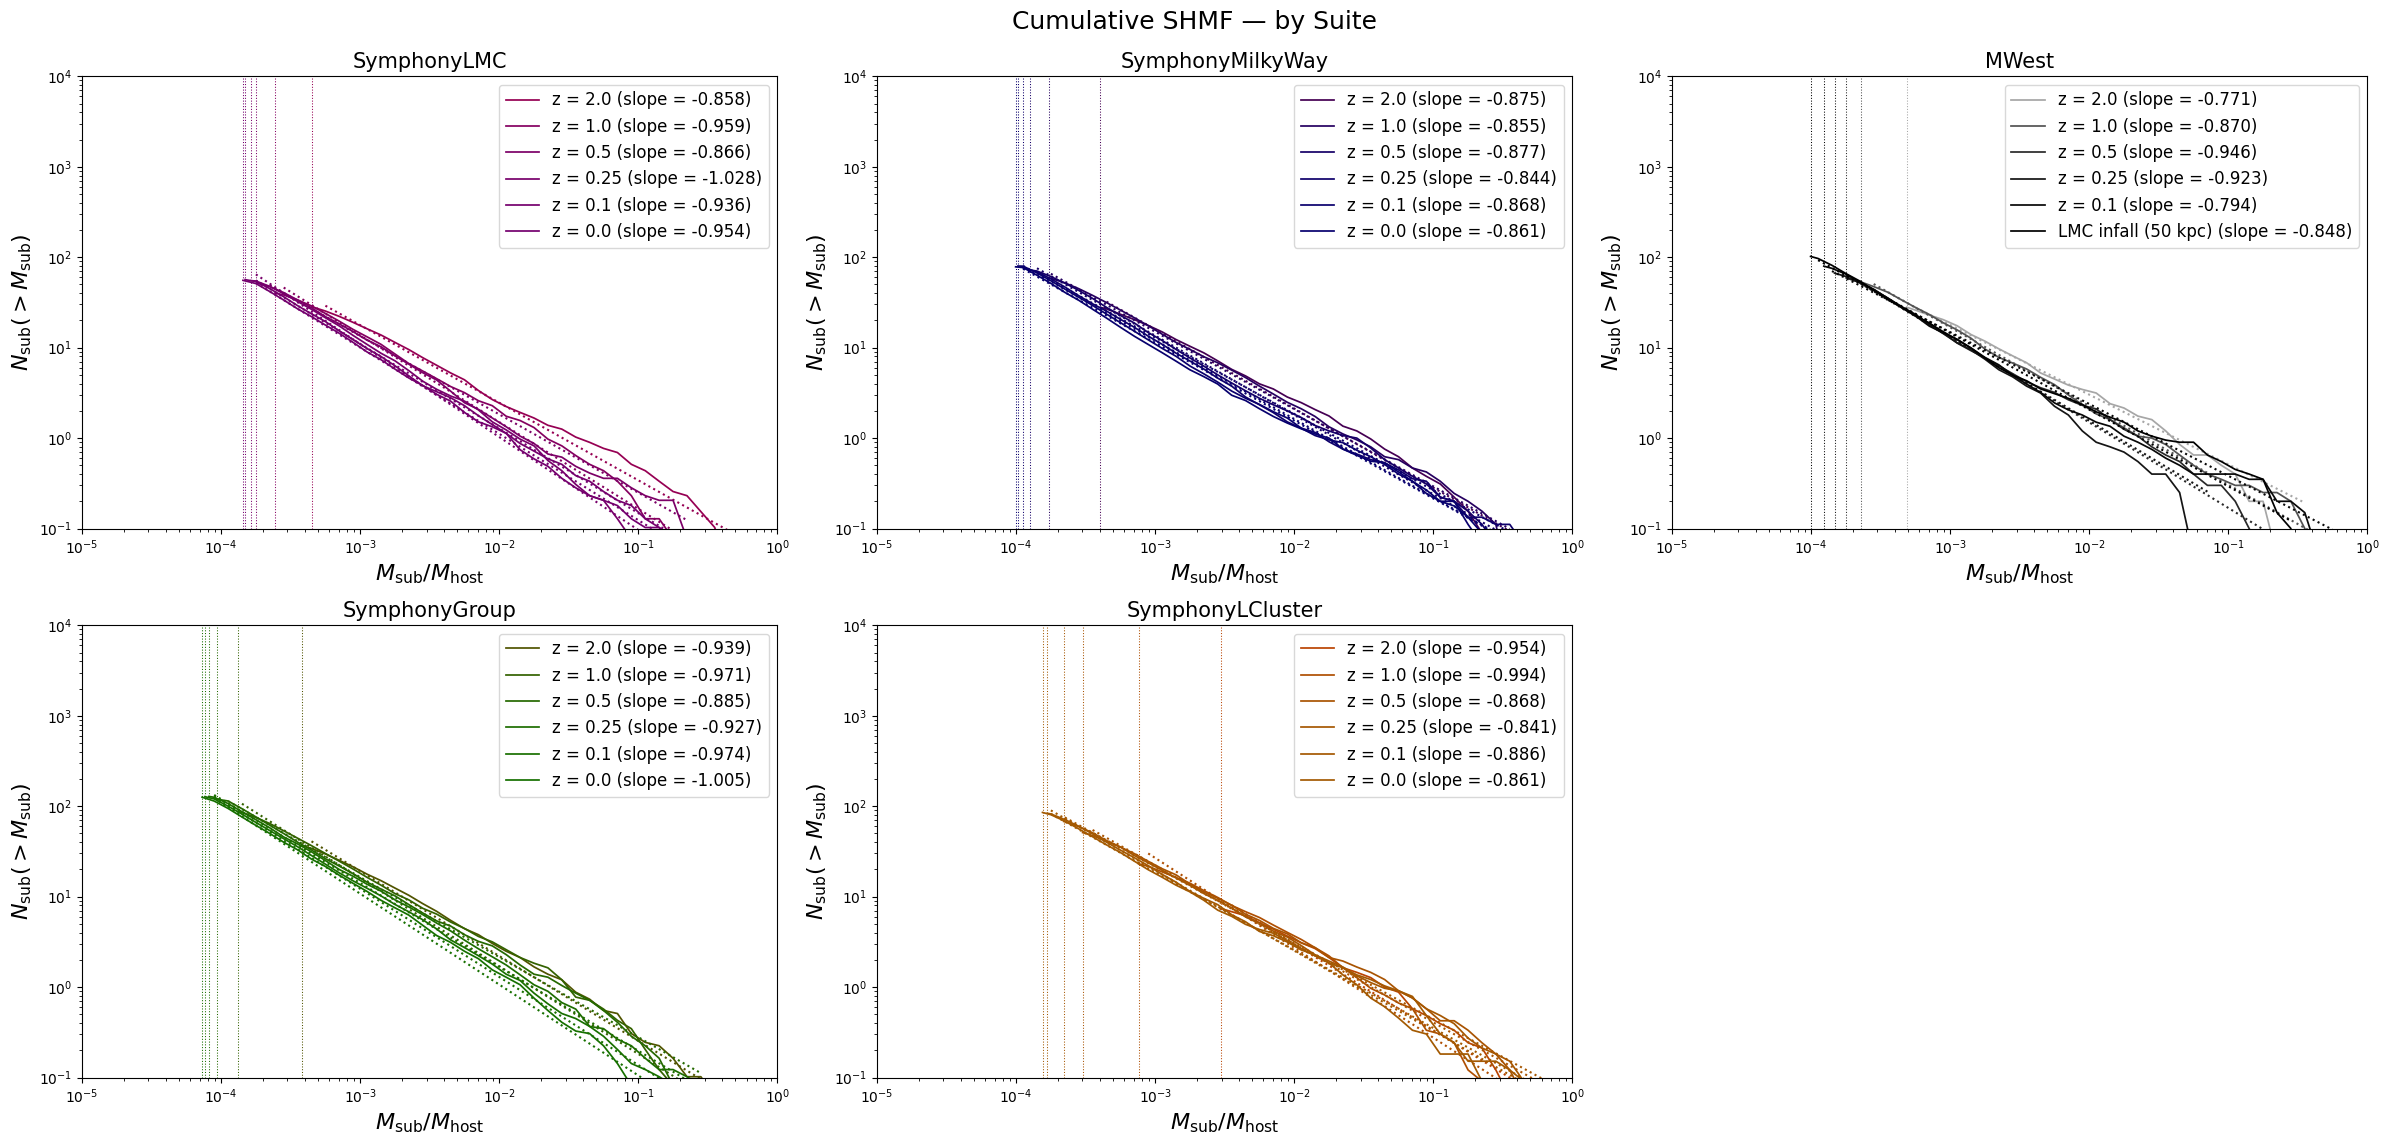

In [17]:
#TOGGLES:

## plot individual per-host lines
show_hosts_shmf = False

## plot 16-84% host-to-host scatter band
show_confidence_shmf = False

## plot linear fit to mean SHMF. True = on
## two points used for the linear fit:
## 1. bin corresponding to 300 particles
## 2. bin corresponding to where the mean SHMF crosses the 10^-1 point on the y-axis
show_shmf_fit = True

## if True, plot dN/d(log Msub) (differential SHMF)
## if False, plot N(>M) (cumulative SHMF)
show_differential = False

## if True, show the vertical line at 300 * mp (convergence)
convergence = True

## if True, the SHMF below 300 * mp is shown
show_dashed = False

## "suite" or "redshift" panel ordering
## "suite" plots all SHMFs in a given suite in their own panel
## "redshift" plots all SHMFS at a given redshift in their own panel
panel_by = "suite"


## ENTRYPOINT:
if panel_by == "suite":
    panel_list = suite_list
    panel_fn = plot_suite_panel
    title_type = "by Suite"
else:
    panel_list = redshifts_shmf
    panel_fn = plot_redshift_panel
    title_type = "by Redshift"

print(f"Starting SHMF plot — panel_by = '{panel_by}'")
print(f"Suites: {suite_list}")
print(f"Redshifts: {redshifts_shmf}")
print(f"Toggles — host lines: {show_hosts_shmf}, confidence band: {show_confidence_shmf}, "
      f"linear fit: {show_shmf_fit}, differential: {show_differential}, convergence: {convergence}\n")

n_panels = len(panel_list)
max_cols = 3                                 ## maximum # of panels per row
n_cols = min(n_panels, max_cols)
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize = (8 * n_cols, 6 * n_rows), squeeze = False)

## hide any unused axes in the last row
for idx in range(n_panels, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

for p_idx, panel in enumerate(panel_list):
    ax = axes[p_idx // n_cols, p_idx % n_cols]
    panel_fn(ax, panel)

shmf_type = "Differential" if show_differential else "Cumulative"
fig.suptitle(f"{shmf_type} SHMF — {title_type}", fontsize = 18, y = 0.95)
plt.tight_layout(rect = [0, 0, 1, 0.96])
#fig.savefig(f"updating SHMFs (ordered by {panel_by}).png", bbox_inches = "tight")
plt.show()

## SHMF UNITS HAVE BEEN CHECKED
## a_now logic has been implemented
## Symfind implemented (except for Symphony Cluster) --> Rockstar still used to get host data
## issue with SymphonyCluster: cores_fid3.dat file does not exist (i.e no Symfind data)...

<a id = "nsubs_mhost_vs_redshift"></a>
## N_subs(z) & Mhost(z) vs. Redshift
[Back to Table of Contents](#table_of_contents)

* Looking at how the host mass accretion tracks with the # of subhalos as a function of "time" (redshift)

Loading suite SymphonyLMC... (39 hosts)
Host 39/39
Loaded 39/39 hosts (0 skipped)
z_max used for this suite: 16.000
RMSE_host_mass = 0.66%
RMSE_nsubs = 1.80%, χ^2_nsubs = 2.72
Loading suite SymphonyMilkyWay... (45 hosts)
Host 1/45

C:\Users\steph\AppData\Local\Temp\ipykernel_22208\1272916952.py:245: RuntimeWarning: Mean of empty slice
  avg_norm_host_mass = np.nanmean(norm_host_mass, axis = 0)
C:\Users\steph\AppData\Local\Temp\ipykernel_22208\1272916952.py:256: RuntimeWarning: Mean of empty slice
  avg_norm_num_nsubs = np.nanmean(norm_num_nsubs, axis = 0)


Host 45/45
Loaded 45/45 hosts (0 skipped)
z_max used for this suite: 16.000
RMSE_host_mass = 0.50%
RMSE_nsubs = 1.92%, χ^2_nsubs = 1.72
Loading suite MWest... (20 hosts)
Host 20/20
Loaded 20/20 hosts (0 skipped)
z_max used for this suite: 16.000
RMSE_host_mass = 1.28%
RMSE_nsubs = 2.20%, χ^2_nsubs = 2.57
Loading suite SymphonyGroup... (49 hosts)
Host 49/49
Loaded 49/49 hosts (0 skipped)
z_max used for this suite: 16.000
RMSE_host_mass = 0.97%
RMSE_nsubs = 2.32%, χ^2_nsubs = 7.91
Loading suite SymphonyLCluster... (33 hosts)
Host 33/33
Loaded 33/33 hosts (0 skipped)
z_max used for this suite: 11.172
RMSE_host_mass = 0.49%
RMSE_nsubs = 1.04%, χ^2_nsubs = 3.70


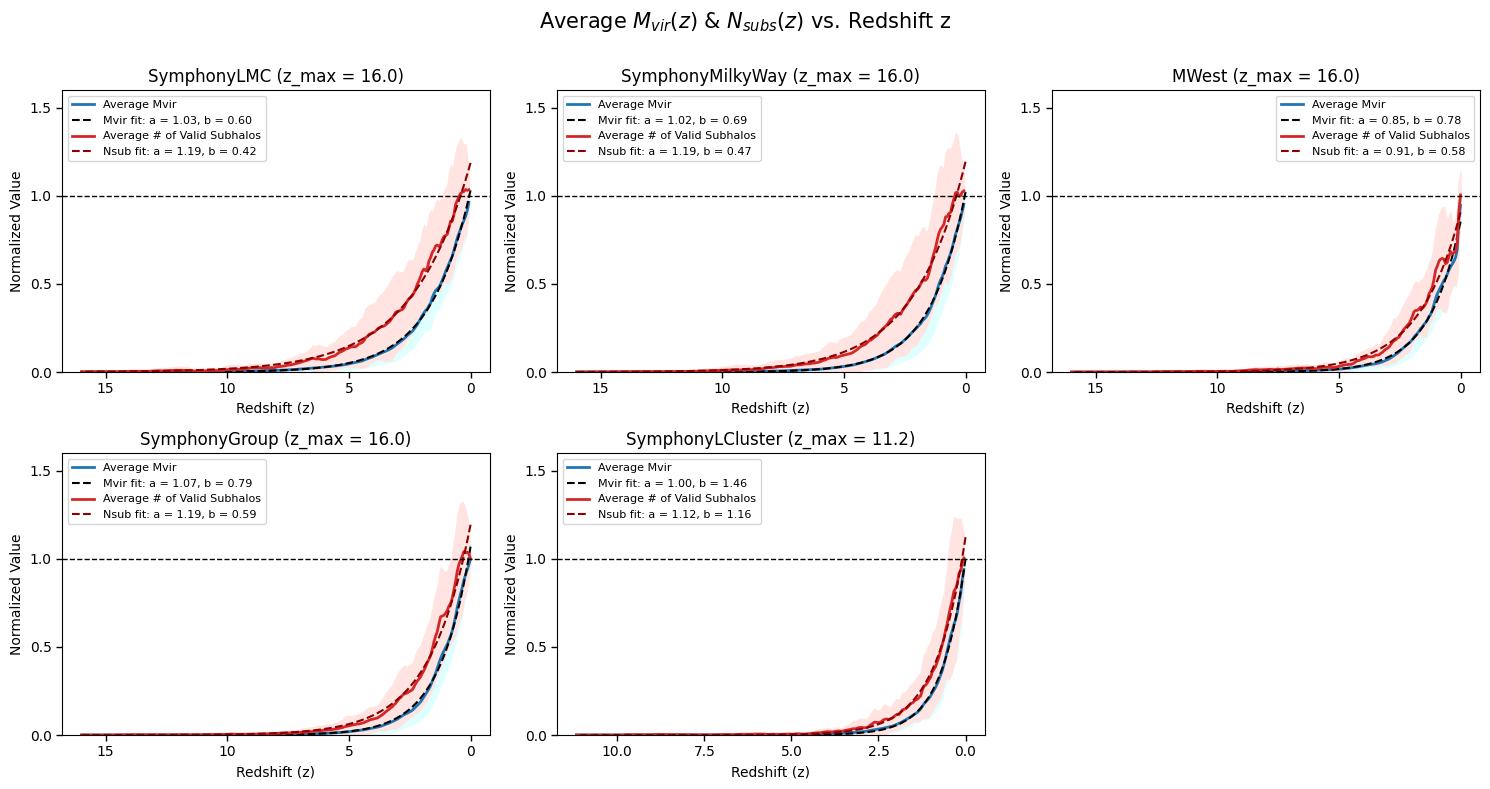

In [18]:
## defining the fitting functions from the Symphony paper
e = np.exp(1)

## FITTING FUNCTIONS:

## simple exponential decay model
def exponentialfit(x, a, b):
        return (a * e**(-1 * b * x))

## power-law + exponential correction (currently unused)
def linearcorrection(x, beta, gamma):
    return (((1 + x) ** beta) * (e ** (-1 * gamma * x)))

########################################################################################

## DATALOADER:

## useful maybe?
def get_mass_bins(suite_name, n_bins, m_max, min_particles):
    
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]
    
    return {"params": params, "m_min": m_min, "m_max": m_max, "bins": bins,
            "left_bins": left_bins, "h100": params["h100"]}

## reads the raw subhalo catalog for one host
def load_host(suite_name, host_id, base_dir):

    ## host_id = host_name for MWest (to guarantee consistency), int for Symphony
    sim_dir = symlib.get_host_directory(base_dir, suite_name, host_id)
    scale_factors = symlib.scale_factors(sim_dir)
    r, r_hist = symlib.read_rockstar(sim_dir)
    s, s_hist = symlib.read_symfind(sim_dir)

    return {"sim_dir": sim_dir,
            "scale_factors": scale_factors,
            "r": r,
            "r_hist": r_hist,
            "s": s,
            "s_hist": s_hist}

## uses the native simulation snapshots to construct Mvir(z) and Nsubs(z) (analysis is later restricted to 0 <= z <= min(native_max_z, 16)
## later interpolated onto a common redshift grid for suite averaging
## also applies the "ok" survival cut AND the 300-particle resolution cut to the host AND subhalos

## toggle: use_overlap_subtraction (False by default --> host_masses = Mvir within host Rvir, subhalos included)
## if True --> host_masses = Mvir - total subhalo mass overlapping the host rvir (sphere_overlap_fraction)
## num_subhalos is tracked in both modes, using the overlap fraction as the "inside host" criterion either way
def compute_host_curves(host_data, suite_name, a_now = 1.0, min_particles = 300, use_overlap_subtraction = False):

    r = host_data["r"]
    s = host_data["s"]
    scale_factors = host_data["scale_factors"]

    ## redshift of every snapshot
    redshifts = (a_now / scale_factors) - 1.0

    ## 300-particle mass-resolution cut
    params = symlib.simulation_parameters(suite_name)
    resolution_cut = params["mp"] / params["h100"] * min_particles

    host_masses = np.full(len(scale_factors), np.nan)
    num_subhalos = np.full(len(scale_factors), np.nan)

    for snap_index in range(len(scale_factors)):

        ## HOST VALIDITY
        host_ok = r["ok"][0, snap_index]
        host_mass = r["m"][0, snap_index]

        ## Host must be "ok" AND resolved with >= 300 particles
        host_valid = (host_ok and (host_mass >= resolution_cut))

        ## If host is invalid, neither Mvir nor Nsub is valid here
        if not host_valid:
            continue

        ## HOST MASS
        ## Mhost = host Mvir
        host_masses[snap_index] = host_mass

        ## SUBHALO DATA
        sub_pos = s["x"][:, snap_index]
        sub_rvir = s["r_tidal"][:, snap_index]   ## closest thing to Rockstar's Rvir that Symfind has...
        sub_mass = s["m"][:, snap_index]
        sub_ok = s["ok"][:, snap_index]

        host_pos = r["x"][0, snap_index]
        host_rvir = r["rvir"][0, snap_index]

        ## VALID SUBHALOS
        ## valid subhalos are "ok", have >= 300 particle masses, and have centers inside the host Rvir
        dist = np.sqrt(np.sum((sub_pos - host_pos) ** 2, axis = 1))
        valid_subhalos = (sub_ok & (sub_mass >= resolution_cut) & (dist <= host_rvir))

        ## Nsub(z)
        num_subhalos[snap_index] = np.sum(valid_subhalos)

        ## OPTIONAL OVERLAP-SUBTRACTED HOST MASS
        if use_overlap_subtraction:

            valid_sub_pos = sub_pos[valid_subhalos]
            valid_sub_rvir = sub_rvir[valid_subhalos]
            valid_sub_mass = sub_mass[valid_subhalos]

            if len(valid_sub_mass) > 0:

                valid_dist = np.sqrt(np.sum((valid_sub_pos - host_pos) ** 2, axis = 1))

                overlap_frac = sphere_overlap_fraction(valid_dist, host_rvir, valid_sub_rvir)

                tot_subhalo_mass_at_z = np.sum(overlap_frac * valid_sub_mass)

                host_masses[snap_index] = (host_mass - tot_subhalo_mass_at_z)

    ## z = 0 values
    z0_host_mass = host_masses[-1]
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "host_masses": host_masses,
            "num_subhalos": num_subhalos,
            "z0_host_mass": z0_host_mass,
            "z0_num_nsubs": z0_num_nsubs}

## loading all hosts:
def load_suite_hosts(suite_name, base_dir, mwest_snap_data = None, use_overlap_subtraction = False):

    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    if suite_name == "MWest" and mwest_snap_data is not None:
        host_ids = MWest_halos
    else:
        host_ids = list(range(n_hosts))

    host_curves = []
    skipped_hosts = []

    for i_host, host_id in enumerate(host_ids):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, host_id, base_dir)

            if suite_name == "MWest" and mwest_snap_data is not None:
                a_now = mwest_snap_data[host_id]["a_lmc_50"]
            else:
                a_now = 1.0

            host_curves.append(compute_host_curves(host_data, suite_name, a_now = a_now,
                                                   use_overlap_subtraction = use_overlap_subtraction))

        except Exception as e:
            print(f"\nSkipping host {host_id}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, host_id))

    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts

##########################################################################################################################################

## STATISTICS:

## normalize one host's raw mass_diffs & num_subhalos to their z0 value, and compute the Spearman rank correlation between them
def normalize_host_curves(curves):

    norm_host_mass = curves["host_masses"] / curves["z0_host_mass"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    ## Spearman correlation between normalized Mvir and Nsubs
    valid = np.isfinite(norm_host_mass) & np.isfinite(norm_num_nsubs)
    
    if valid.sum() >= 2:
        rho, p = scipy.stats.spearmanr(norm_host_mass[valid] / np.nanmax(norm_host_mass[valid]),
                                       norm_num_nsubs[valid] / np.nanmax(norm_num_nsubs[valid]))
    else:
        rho, p = np.nan, np.nan

    return {"redshifts": curves["redshifts"],
            "norm_host_mass": norm_host_mass,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}

## computes the root-mean-squared error (RMSE) between the suite-averaged curve and the exponential fit
def rmse(y_data, y_model):
    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)
    return np.sqrt(np.mean((y_data - y_model)**2))

## computes the reduced chi-squared (residuals normalized by per-bin uncertainty)
## sigma here is the standard error of the mean (SEM, the standard deviation across hosts divided by sqrt(n_hosts))
def reduced_chi_squared(y_data, y_model, sigma, n_params):
    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)
    sigma = np.asarray(sigma)
    valid = sigma > 0
    chi_sq = np.sum(((y_data[valid] - y_model[valid]) / sigma[valid])**2)
    dof = np.sum(valid) - n_params
    return chi_sq / dof


## given a list of raw per-host curves:
## - normalize each host
## - interpolate onto a COMMON redshift grid spanning the full range actually present
##   across all hosts in the suite (not a fixed z=2->0 window)
## - average across hosts, then fit
def aggregate_suite(host_curves, n_grid = 235, use_overlap_subtraction = False):

    normalized = [normalize_host_curves(c) for c in host_curves]

    valid_max_z = [np.nanmax(n["redshifts"][np.isfinite(n["norm_host_mass"])])
                  for n in normalized if np.any(np.isfinite(n["norm_host_mass"]))]
    
    ## analysis domain: restrict to the well-defined redshift range
    z_max_analysis = 16.0

    suite_z_max = min(max(valid_max_z), z_max_analysis) if valid_max_z else z_max_analysis

    common_redshifts = np.linspace(0, suite_z_max, n_grid)

    fields = ["norm_host_mass", "norm_num_nsubs"]

    def interp_host(n):
        out = {}
        for field in fields:
            valid = np.isfinite(n[field])
            if valid.sum() < 2:
                out[field] = np.full(n_grid, np.nan)
                continue
            z_valid = n["redshifts"][valid][::-1]
            out[field] = np.interp(common_redshifts, z_valid, n[field][valid][::-1], left = np.nan, right = np.nan)
        return out

    resampled = [interp_host(n) for n in normalized]

    redshifts = common_redshifts

    ## host mass
    norm_host_mass = np.array([r["norm_host_mass"] for r in resampled])
    avg_norm_host_mass = np.nanmean(norm_host_mass, axis = 0)
    std_norm_host_mass = np.nanstd(norm_host_mass, axis = 0)

    fit_host_mass_mask = np.isfinite(avg_norm_host_mass)
    fit_host_mass, _ = curve_fit(exponentialfit, redshifts[fit_host_mass_mask], avg_norm_host_mass[fit_host_mass_mask], maxfev = 10000)

    n_hosts = len(host_curves)
    rmse_mass = rmse(avg_norm_host_mass[fit_host_mass_mask], exponentialfit(redshifts[fit_host_mass_mask], *fit_host_mass))

    ## Nsubs
    norm_num_nsubs = np.array([r["norm_num_nsubs"] for r in resampled])
    avg_norm_num_nsubs = np.nanmean(norm_num_nsubs, axis = 0)
    std_norm_num_nsubs = np.nanstd(norm_num_nsubs, axis = 0)

    fit_nsubs_mask = np.isfinite(avg_norm_num_nsubs)

    fit_nsubs, _ = curve_fit(exponentialfit, redshifts[fit_nsubs_mask], avg_norm_num_nsubs[fit_nsubs_mask], maxfev = 10000)

    sigma_nsubs = np.where(std_norm_num_nsubs > 0, std_norm_num_nsubs / np.sqrt(n_hosts), np.nan)

    rmse_nsubs = rmse(avg_norm_num_nsubs[fit_nsubs_mask], exponentialfit(redshifts[fit_nsubs_mask], *fit_nsubs))

    reduced_chisq_nsubs = reduced_chi_squared(avg_norm_num_nsubs[fit_nsubs_mask], exponentialfit(redshifts[fit_nsubs_mask], *fit_nsubs),
                                              sigma_nsubs[fit_nsubs_mask], n_params = 2)

    ## RESULT:
    result = {"redshifts": redshifts,
              "suite_z_max": suite_z_max,
              
              ## Mvir
              "avg_norm_host_mass": avg_norm_host_mass,
              "std_norm_host_mass": std_norm_host_mass,
              "fit_host_mass": fit_host_mass,
              "rmse_mass": rmse_mass,
              
              ## Nsub
              "avg_norm_num_nsubs": avg_norm_num_nsubs,
              "std_norm_num_nsubs": std_norm_num_nsubs,
              "fit_nsubs": fit_nsubs,
              "rmse_nsubs": rmse_nsubs,
              "reduced_chisq_nsubs": reduced_chisq_nsubs,
              
              ## Per-host correlation
              "rho_suite": [n["rho"] for n in normalized],
              "p_suite": [n["p"] for n in normalized]}

    print(f"z_max used for this suite: {suite_z_max:.3f}")
    print(f"RMSE_host_mass = {(rmse_mass * 100):.2f}%")
    print(f"RMSE_nsubs = {(rmse_nsubs * 100):.2f}%, "
          f"χ^2_nsubs = {reduced_chisq_nsubs:.2f}")

    return result

##################################################################################################################################

## PLOTTER:

def plot_suite(axs, row, col, suite_name, suite_result, colors, use_overlap_subtraction = False):

    redshifts = suite_result["redshifts"]
    ax = axs[row, col]

    ## HOST MASS
    mass_label = ("Average Mass Difference (host - subhalos)" if use_overlap_subtraction else "Average Mvir")

    ax.plot(redshifts, suite_result["avg_norm_host_mass"], color = "tab:blue", lw = 2, label = mass_label)

    ax.fill_between(redshifts, suite_result["avg_norm_host_mass"] + suite_result["std_norm_host_mass"],
                    suite_result["avg_norm_host_mass"] - suite_result["std_norm_host_mass"], color = "lightcyan")

    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_host_mass"]), color = "black", ls = "--",
            label = (f"Mvir fit: a = {suite_result['fit_host_mass'][0]:.2f}, b = {suite_result['fit_host_mass'][1]:.2f}"))

    ## NSUBS
    ax.plot(redshifts, suite_result["avg_norm_num_nsubs"], color = "tab:red", lw = 2, label = "Average # of Valid Subhalos")

    ax.fill_between(redshifts, suite_result["avg_norm_num_nsubs"] + suite_result["std_norm_num_nsubs"],
                    suite_result["avg_norm_num_nsubs"] - suite_result["std_norm_num_nsubs"], color = "mistyrose")

    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_nsubs"]), color = "darkred", linestyle = "--",
            label = (f"Nsub fit: a = {suite_result['fit_nsubs'][0]:.2f}, b = {suite_result['fit_nsubs'][1]:.2f}"))

    ## FORMATTING
    ax.invert_xaxis()
    ax.set_xlabel("Redshift (z)")
    ax.set_ylabel("Normalized Value")
    ax.set_ylim(0.0, 1.6)

    ax.axhline(y = 1, color = "black", lw = 1, linestyle = "--")

    ax.locator_params(axis = "x", nbins = 5)
    ax.locator_params(axis = "y", nbins = 5)

    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")

    ax.legend(loc = "best", fontsize = 8)

    ax.set_title(f"{suite_name} (z_max = {suite_result['suite_z_max']:.1f})")


def plot_all_suites(suite_results, colors, use_overlap_subtraction = False):

    suite_names = list(suite_results.keys())
    n_suites = len(suite_names)

    max_cols = 3
    ncols = min(max_cols, n_suites)
    nrows = int(np.ceil(n_suites / max_cols))

    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5 * ncols, 4 * nrows), squeeze = False)

    for suite_index, suite_name in enumerate(suite_names):
        row, col = divmod(suite_index, max_cols)
        plot_suite(axs, row, col, suite_name, suite_results[suite_name], colors, use_overlap_subtraction = use_overlap_subtraction)

    for empty_index in range(n_suites, nrows * ncols):
        row, col = divmod(empty_index, max_cols)
        axs[row, col].axis("off")

    fig.suptitle(r"Average $M_{vir}(z)$ & $N_{subs}(z)$ vs. Redshift z", fontsize = 15)
    fig.tight_layout(rect = [0, 0, 1, 0.975])
    #fig.savefig("updated Mvir & Nsubs vs. Redshift z.png")
    plt.show()

    return fig, axs

#######################################################################################################################

## ENTRYPOINT:

def run_all_suites(suite_list, base_dir, colors, mwest_snap_data = lmc_analog_sub_data, use_overlap_subtraction = False):

    suite_results = {}
    all_skipped = []

    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir, mwest_snap_data = mwest_snap_data,
                                                      use_overlap_subtraction = use_overlap_subtraction)
        all_skipped.extend(skipped_hosts)
        suite_results[suite_name] = aggregate_suite(host_curves, use_overlap_subtraction = use_overlap_subtraction)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, host_id in all_skipped:
            print(f"{suite_name}, host {host_id}")

    fig, axs = plot_all_suites(suite_results, colors, use_overlap_subtraction = use_overlap_subtraction)
    return fig, axs, suite_results, all_skipped


## default: Mvir only, no subhalo work
fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors, use_overlap_subtraction = False)

## overlap-subtraction version:
#fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors, use_overlap_subtraction = True)

## UNITS HAVE BEEN CHECKED
## a_now logic has been implemented (?)
## overlap logic implemented --> either use the spherical overlap formula as an approximation, or just ignore it completely and use M inside host Rvir
## Symfind implemented (except SymphonyCluster...)

<a id = "norm_nsubs_vs_norm_host_mass"></a>
## Nsubs(z)/Nsubs(z=0) vs. Host Mass(z)/Host Mass(z=0):
[Back to Table of Contents](#table_of_contents)

* Individual hosts as a faint line, mean as a bold line (colored by suite) --> add 16-84% confidence as well maybe
* Time series of points starting at (0, 0) and ending at (1, 1)
* Perfect correlation would traverse along the 1-to-1 line

Goal: assess how well MAH predicts Nsub on an individual host and an average basis

(The dataloader cell is necessary for the [Machine Learning](#machine_learning) section below)

In [19]:
## DATALOADER:
## this dataloader cell is also necessary for the "Machine Learning" section below...

def get_mass_bins(suite_name, n_bins, m_max, min_particles):
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]
    return {"params": params, "m_min": m_min, "m_max": m_max, "bins": bins,
            "left_bins": left_bins, "h100": params["h100"]}

def load_host(suite_name, host_id, base_dir):

    ## host_id = halo name for MWest (guarantees consistency with a_lmc_50 lookup), int index otherwise
    sim_dir = symlib.get_host_directory(base_dir, suite_name, host_id)
    scale_factors = symlib.scale_factors(sim_dir)
    
    r, r_hist = symlib.read_rockstar(sim_dir)
    s, s_hist = symlib.read_symfind(sim_dir)
    return {"sim_dir": sim_dir, 
            "suite_name": suite_name, 
            "scale_factors": scale_factors, 
            "r": r,
            "r_hist": r_hist,
            "s": s,
            "s_hist": s_hist}


## toggle: use_overlap_subtraction (False by default --> uses M within host Rvir (including subhalos))
## if True --> host_masses = host_mass - total subhalo mass overlapping the host rvir (using sphere_overlap_fraction)
## num_subhalos is tracked in both modes, using the overlap fraction as the "inside host" criterion either way
## z_max: any snapshot with redshift > z_max is skipped --> caps the usable redshift range at 16.0 by default
## still allowing a suite whose native range doesn't reach that high to simply use whatever its own real max redshift is
def compute_host_curves(host_data, a_now = 1.0, min_particles = 300, use_overlap_subtraction = False, z_max_cap = 16.0):

    r = host_data["r"]
    s = host_data["s"]
    scale_factors = host_data["scale_factors"]

    ## TRUE redshift of every snapshot, derived directly from the real scale factors
    ## note this is the standard 1+z = 1/a relation (a_now = 1 implicitly), NOT the a_now-relative
    ## "1+z = a_now/a" convention used elsewhere in this project -- see note below usage.
    redshifts = (1.0 / scale_factors) - 1.0

    host_masses = np.full(len(scale_factors), np.nan)
    num_subhalos = np.full(len(scale_factors), np.nan)

    params = symlib.simulation_parameters(host_data["suite_name"])
    resolution_cut = params["mp"] / params["h100"] * min_particles

    for snap_index in range(len(scale_factors)):

        ## snapshots beyond z_max_cap are skipped (left as NaN)
        ## if this host's native range never reaches z_max_cap, this condition never
        ## triggers and every real snapshot is used, up to whatever the true max is.
        if redshifts[snap_index] > z_max_cap:
            continue

        host_mass = r["m"][0, snap_index]

        ## HOST VALIDITY: must be "ok" AND >= 300 particles.
        ## failing either means this snapshot's host data is invalid.
        host_ok = r["ok"][0, snap_index]
        host_valid = host_ok and (host_mass >= resolution_cut)

        ## host_masses/num_subhalos stay NaN for this snapshot (NaN by default, overwritten if condition changes)
        if not host_valid:
            continue

        host_rvir = r["rvir"][0, snap_index]
        host_pos = r["x"][0, snap_index]
        
        sub_rvir = s["r_tidal"][1:, snap_index]   ## closest thing to Rockstar's Rvir
        sub_pos = s["x"][1:, snap_index]
        sub_mass = s["m"][1:, snap_index]

        sub_ok = s["ok"][1:, snap_index]
        above_res_limit = sub_mass >= resolution_cut
        valid = sub_ok & above_res_limit

        ok_sub_pos = sub_pos[valid]
        ok_sub_rvir = sub_rvir[valid]
        ok_sub_mass = sub_mass[valid]

        dist = np.sqrt(np.sum((ok_sub_pos - host_pos) ** 2, axis = 1))
        overlap_frac = sphere_overlap_fraction(dist, host_rvir, ok_sub_rvir)

        num_subhalos[snap_index] = np.sum(overlap_frac > 0)

        if use_overlap_subtraction:
            tot_subhalo_mass_at_z = np.sum(overlap_frac * ok_sub_mass)
            host_masses[snap_index] = host_mass - tot_subhalo_mass_at_z
        else:
            host_masses[snap_index] = host_mass   ## total mass inside host rvir, subhalos included

    ## "z0" here means a=1 (true present day), the LAST snapshot in the array --
    ## this is unaffected by a_now, since it's just indexing the final real snapshot
    z0_host_mass = host_masses[-1]
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "host_masses": host_masses,
            "num_subhalos": num_subhalos,
            "z0_host_mass": z0_host_mass,
            "z0_num_nsubs": z0_num_nsubs}


## loading all hosts:
def load_suite_hosts(suite_name, base_dir, mwest_snap_data = None, use_overlap_subtraction = False, z_max_cap = 16.0):

    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    if suite_name == "MWest" and mwest_snap_data is not None:
        host_ids = MWest_halos
    else:
        host_ids = list(range(n_hosts))

    host_curves = []
    skipped_hosts = []

    for i_host, host_id in enumerate(host_ids):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, host_id, base_dir)

            if suite_name == "MWest" and mwest_snap_data is not None:
                a_now = mwest_snap_data[host_id]["a_lmc_50"]
            else:
                a_now = 1.0

            host_curves.append(compute_host_curves(host_data, a_now = a_now, use_overlap_subtraction = use_overlap_subtraction, z_max_cap = z_max_cap))

        except Exception as e:
            print(f"\nSkipping host {host_id}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, host_id))

    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts

## loads raw per-host curves for every suite
def load_all_suites(suite_list, base_dir, mwest_snap_data = lmc_analog_sub_data, use_overlap_subtraction = False, z_max_cap = 16.0):

    all_host_curves = {}
    all_skipped = []

    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir, mwest_snap_data = mwest_snap_data,
                                                      use_overlap_subtraction = use_overlap_subtraction,
                                                      z_max_cap = z_max_cap)
        all_host_curves[suite_name] = host_curves
        all_skipped.extend(skipped_hosts)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, host_id in all_skipped:
            print(f"{suite_name}, host {host_id}")

    return all_host_curves, all_skipped


## run once:

## direct host mass (default, smooth, no subtraction):
all_host_curves, all_skipped = load_all_suites(suite_list, base_dir, use_overlap_subtraction = False)

## overlap-subtraction version (the "mass difference" approach):
#all_host_curves, all_skipped = load_all_suites(suite_list, base_dir, use_overlap_subtraction = True)

## Nsubs(z)/Nsubs(z=0) vs. Mhost(z)/Mhost(z=0) UNITS CHECKED
## a_now definition properly implemented for Symphony & MWest
## Mhost = total mass within host rvir
## host "ok" + 300-particle validity check added
## z_max capped at 16.0 (or the suite's own true max, if lower)
## Symfind implemented (except SymphonyCluster...)

Loading suite SymphonyLMC... (39 hosts)
Host 2/39

C:\Users\steph\AppData\Local\Temp\ipykernel_22208\2206163148.py:134: RuntimeWarning: divide by zero encountered in divide
  partial_frac = np.clip(v_overlap / v_sub, 0.0, 1.0)
C:\Users\steph\AppData\Local\Temp\ipykernel_22208\2206163148.py:143: RuntimeWarning: divide by zero encountered in divide
  frac = np.where(host_fully_inside, np.clip(v_host / v_sub, 0.0, 1.0), frac)


Host 3/39

C:\Users\steph\AppData\Local\Temp\ipykernel_22208\2206163148.py:128: RuntimeWarning: invalid value encountered in subtract
  v_overlap = (np.pi * (R + r - d_safe)**2 * (d_safe**2 + 2*d_safe*(R + r) - 3*(R - r)**2)) / (12 * d_safe)


Host 39/39
Loaded 39/39 hosts (0 skipped)
Loading suite SymphonyMilkyWay... (45 hosts)
Host 45/45
Loaded 45/45 hosts (0 skipped)
Loading suite MWest... (20 hosts)
Host 20/20
Loaded 20/20 hosts (0 skipped)
Loading suite SymphonyGroup... (49 hosts)
Host 49/49
Loaded 49/49 hosts (0 skipped)
Loading suite SymphonyLCluster... (33 hosts)
Host 33/33
Loaded 33/33 hosts (0 skipped)


z_max used for this suite: 15.946
z_max used for this suite: 15.946
z_max used for this suite: 15.946
z_max used for this suite: 15.946
z_max used for this suite: 11.172


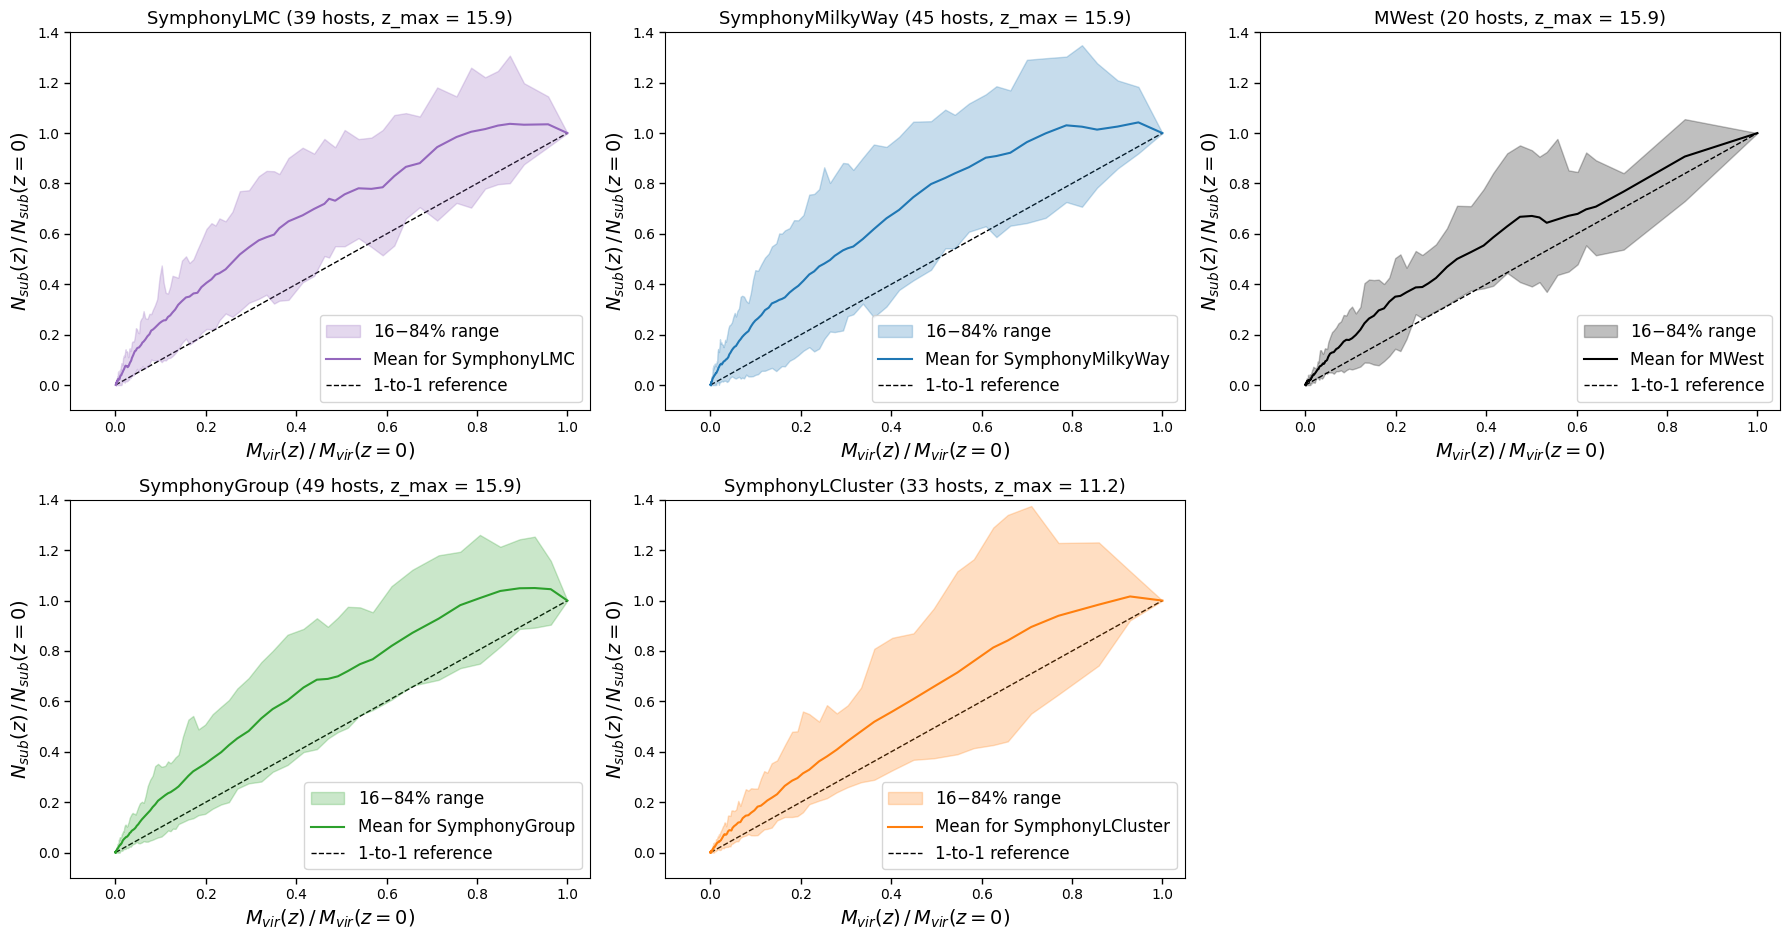

In [22]:
## STATS AND PLOTTER (not needed for any other section)

## STATISTICS:

## normalize one host's raw host_masses & num_subhalos to their value at a_now, and compute the Spearman rank correlation between them.
## NaN-aware, since invalid snapshots (host not "ok" / under-resolved / beyond z_max_cap) are NaN
def normalize_host_curves(curves):

    norm_host_mass = curves["host_masses"] / curves["z0_host_mass"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    valid = np.isfinite(norm_host_mass) & np.isfinite(norm_num_nsubs)
    if valid.sum() >= 2:
        rho, p = scipy.stats.spearmanr(norm_host_mass[valid] / np.nanmax(norm_host_mass[valid]),
                                       norm_num_nsubs[valid] / np.nanmax(norm_num_nsubs[valid]))
    else:
        rho, p = np.nan, np.nan

    return {"redshifts": curves["redshifts"],
            "norm_host_mass": norm_host_mass,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}

## interpolate one (already normalized) host's curves onto a common redshift grid
## restricted to that host's own valid points, with no extrapolation past its valid range
def resample_host_to_grid(normalized_curves, common_redshifts):

    redshifts = normalized_curves["redshifts"]
    valid = np.isfinite(normalized_curves["norm_host_mass"]) & np.isfinite(normalized_curves["norm_num_nsubs"])

    if valid.sum() < 2:
        return {"norm_host_mass": np.full(len(common_redshifts), np.nan),
                "norm_num_nsubs": np.full(len(common_redshifts), np.nan)}

    z_valid = redshifts[valid][::-1]   ## redshifts run high->low; np.interp needs ascending x

    return {"norm_host_mass": np.interp(common_redshifts, z_valid, normalized_curves["norm_host_mass"][valid][::-1],
                                        left = np.nan, right = np.nan),
            "norm_num_nsubs": np.interp(common_redshifts, z_valid, normalized_curves["norm_num_nsubs"][valid][::-1],
                                        left = np.nan, right = np.nan)}
## z_max:
## if None (default), use the suite's own actual max valid redshift across hosts
## if given explicitly, use that value directly as the grid's upper bound
## either to match the dataloader's z_max_cap, or to force a specific value across all suites for comparison)
def aggregate_suite_trajectory(host_curves, n_grid = 200, z_max = None):

    normalized = [normalize_host_curves(c) for c in host_curves]

    ## same z_max logic as the existing Mvir & Nsubs vs. z analysis
    valid_max_z = [np.nanmax(n["redshifts"][np.isfinite(n["norm_host_mass"])]) for n in normalized if np.any(np.isfinite(n["norm_host_mass"]))]
    
    ## analysis domain: cap at z = 16
    z_max_analysis = 16.0

    if z_max is None:
        z_max = min(max(valid_max_z), z_max_analysis) if valid_max_z else z_max_analysis
    else:
        ## even when a z_max is explicitly requested, still respect this suite's own actual data range
        ## a suite whose real max is below the requested cap should use its own true max, not extend into a region with no data at all
        z_max = min(z_max, max(valid_max_z), z_max_analysis) if valid_max_z else min(z_max, z_max_analysis)
    
    print(f"z_max used for this suite: {z_max:.3f}")

    common_redshifts = np.linspace(0, z_max, n_grid)
    common_redshifts[0] = np.nanmin([n["redshifts"][np.isfinite(n["norm_host_mass"]) & np.isfinite(n["norm_num_nsubs"])][-1] for n in normalized])

    resampled = [resample_host_to_grid(n, common_redshifts) for n in normalized]

    mass_matrix = np.array([r["norm_host_mass"] for r in resampled])
    nsubs_matrix = np.array([r["norm_num_nsubs"] for r in resampled])

    mean_mass = np.nanmean(mass_matrix, axis = 0)
    mean_nsubs = np.nanmean(nsubs_matrix, axis = 0)
    p16_nsubs = np.nanpercentile(nsubs_matrix, 16, axis = 0)
    p84_nsubs = np.nanpercentile(nsubs_matrix, 84, axis = 0)

    return {"redshifts": common_redshifts,
            "z_max": z_max,
            "mass_matrix": mass_matrix,
            "nsubs_matrix": nsubs_matrix,
            "mean_mass": mean_mass,
            "mean_nsubs": mean_nsubs,
            "p16_nsubs": p16_nsubs,
            "p84_nsubs": p84_nsubs,
            "n_hosts": len(host_curves)}


def aggregate_all_suites(all_host_curves, n_grid = 200, z_max = None):
    return {suite_name: aggregate_suite_trajectory(host_curves, n_grid = n_grid, z_max = z_max)
           for suite_name, host_curves in all_host_curves.items()}

##################################################################################################################################

## PLOTTER:

## fill in one panel: Nsubs(z)/Nsubs(z=0) vs Mass(z)/Mass(z=0) for a single suite
def plot_suite_trajectory(ax, suite_name, suite_result, colors):

    color = colors[suite_name]

    valid = np.isfinite(suite_result["mean_mass"]) & np.isfinite(suite_result["mean_nsubs"])

    ax.fill_between(suite_result["mean_mass"][valid], suite_result["p16_nsubs"][valid], suite_result["p84_nsubs"][valid],
                    color = color, alpha = 0.25, zorder = 2, label = "16$-$84% range")

    ax.plot(suite_result["mean_mass"][valid], suite_result["mean_nsubs"][valid], color = color, lw = 1.5, zorder = 3,
            label = f"Mean for {suite_name}")

    ax.plot([0, 1], [0, 1], color = "black", linestyle = "--", lw = 1, zorder = 0, label = "1-to-1 reference")

    ax.set_xlabel(r"$M_{vir}(z)\,/\, M_{vir}(z=0)$", fontsize = 14)
    ax.set_ylabel(r"$N_{sub}(z)\,/\, N_{sub}(z=0)$", fontsize = 14)
    ax.set_xlim(-0.1, 1.05)
    ax.set_ylim(-0.1, 1.4)
    ax.set_title(f"{suite_name} ({suite_result['n_hosts']} hosts, z_max = {suite_result['z_max']:.1f})", fontsize = 13)
    ax.legend(fontsize = 12, loc = "lower right")
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")


def plot_all_suites_trajectories(suite_results, colors, max_cols = 3):

    suite_names = list(suite_results.keys())
    n_suites = len(suite_names)
    ncols = min(max_cols, n_suites)
    nrows = int(np.ceil(n_suites / ncols))

    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (6 * ncols, 5 * nrows), squeeze = False)
    flat_axs = axs.flatten()

    for i, suite_name in enumerate(suite_names):
        plot_suite_trajectory(flat_axs[i], suite_name, suite_results[suite_name], colors)

    for j in range(n_suites, len(flat_axs)):
        fig.delaxes(flat_axs[j])

    fig.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

    return fig, axs


## ENTRYPOINT:

## default: each suite uses its own actual max redshift (already capped at the dataloader's z_max_cap)
#suite_results = aggregate_all_suites(all_host_curves)

## force a specific z_max across every suite, e.g. to directly match the dataloader's cap:
suite_results = aggregate_all_suites(all_host_curves, z_max = 16.0)

fig, axs = plot_all_suites_trajectories(suite_results, colors)

#fig.savefig(f"normalized Nsubs(z) vs. Mhost(z) (z_max = 16.0).png")

<a id = "smooth_vs_clumpy_accretion"></a>
## Smooth vs. Clumpy Accretion of Particles
[Back to Table of Contents](#table_of_contents)

Another interesting question is "what fraction of the host's mass is made of the "smooth" background particles being accreted onto the host versus "bursty" particles being accreted when subhalos fall in?"

The expectation is that because dark matter halos are supported against gravitational collapse by the random motions of the particles, all of the halos (including the host) should be made of mostly "smooth" particles, with only a small number of the particles being "bursty" or "clumpy." The host is so large and massive that it can "afford" to have some inhomogeneities in it, but the subhalos are all "smooth" on the inside.

The infalling particles are a different fraction of "smooth" versus "clumpy," possibly closer to 50-50? However, due to tidal stripping, the "clumpy" particles that belong to a particular subhalo become "smooth" as they get stripped away.

First, let's look at only the particles belonging to the main host (labeled as being part of the host by the halo finder, and also inside the host virial radius at a given time), and let's look at the fraction of the host mass that is also contained in subhalos. We will assume that the remaining mass is all "smooth" particles that aren't part of any substructure.

Starting on suite SymphonyLMC...
Current host: 39/39

C:\Users\steph\AppData\Local\Temp\ipykernel_12396\3505884803.py:110: RuntimeWarning: Mean of empty slice
  mean_clumpy = np.nanmean(all_clumpy, axis = 0)
C:\Users\steph\AppData\Local\Temp\ipykernel_12396\3505884803.py:114: RuntimeWarning: Mean of empty slice
  mean_smooth = np.nanmean(all_smooth, axis = 0)


Starting on suite SymphonyMilkyWay...
Starting on suite MWest...
Starting on suite SymphonyGroup...
Starting on suite SymphonyLCluster...
Starting on suite SymphonyCluster...
Current host: 81/81

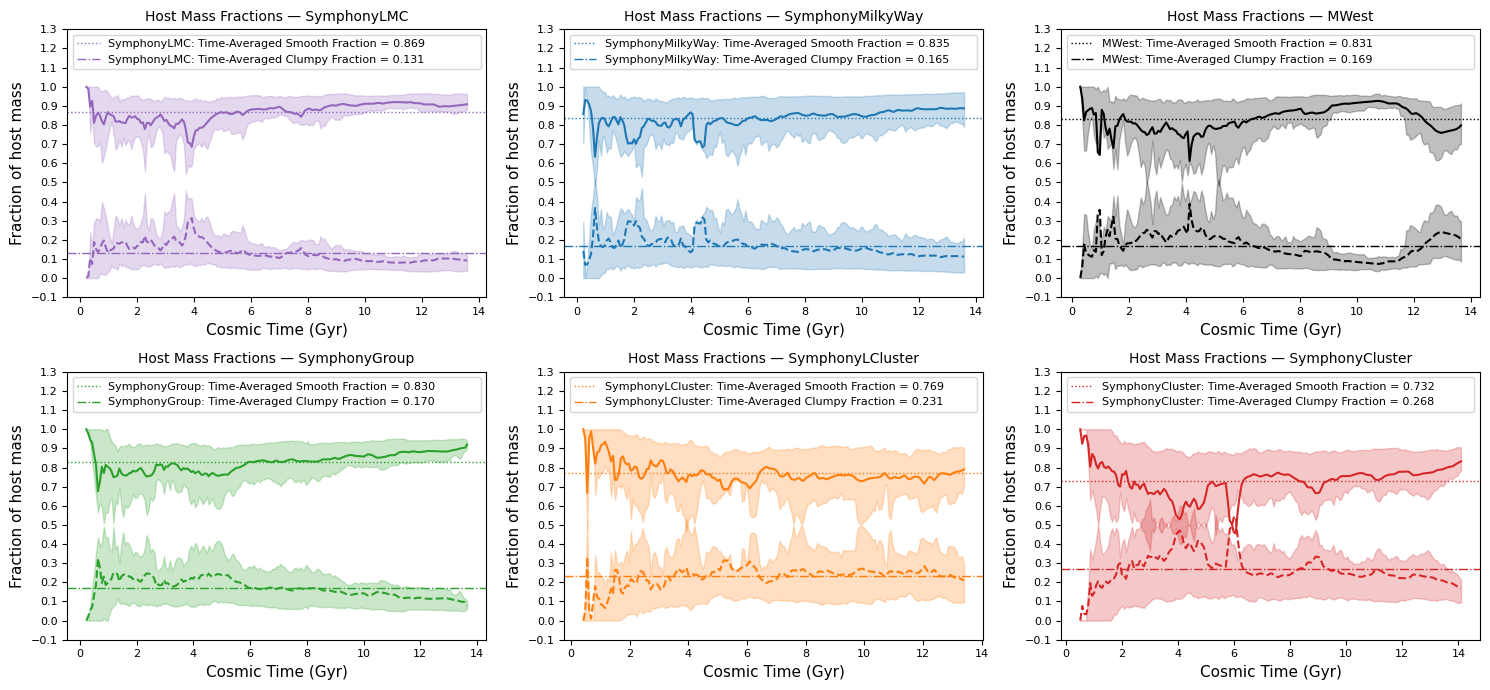

In [18]:
n_suites = len(suite_list)
ncols = 3 if n_suites > 1 else 1
nrows = int(np.ceil(n_suites / ncols))

n_grid = 200  # number of points in the common cosmic-time grid

fig, axes = plt.subplots(nrows, ncols, figsize = (5 * ncols, 3.5 * nrows), squeeze = False)
axes_flat = axes.flatten()

for suite_index, suite_name in enumerate(suite_list):
    ax = axes_flat[suite_index]

    print(f"Starting on suite {suite_name}...")

    n_hosts = symlib.n_hosts(suite_name)

    ## MWest needs to be indexed by halo name
    if suite_name == "MWest":
        host_ids = MWest_halos
    else:
        host_ids = list(range(n_hosts))

    all_clumpy = []
    all_smooth = []

    common_time_grid = None
    cosmo = None

    for i_host, host_id in enumerate(host_ids):

        print(f"Current host: {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        sim_dir = symlib.get_host_directory(base_dir, suite_name, host_id)
        scale_factors = symlib.scale_factors(sim_dir)
        snapshots = np.arange(0, len(scale_factors), 1)
        params = symlib.simulation_parameters(sim_dir)

        mp = params["mp"] / params["h100"]
        particle_cut = 300 * mp

        h, hist = symlib.read_subhalos(sim_dir)

        ## 300 particles and "ok" cut for the host and subhalos:
        ok = h["ok"]
        mvir = h["mvir"]

        host_ok = ok[0, :]
        host_mass_all_snaps = mvir[0, :]

        sub_ok = ok[1:, :]
        sub_mass = mvir[1:, :]

        ## position cut for subhalos:
        host_x = h["x"][0, :]
        sub_x = h["x"][1:, :]
        host_rvir = h["rvir"][0, :]

        r = np.sqrt(np.sum(sub_x**2, axis = -1))
        inside_rvir = r <= host_rvir

        mass_cut = sub_mass >= particle_cut
        valid = sub_ok & inside_rvir & mass_cut
        masked_sub_mass = np.where(valid, sub_mass, 0.0)

        ## total mass of subhalos that meet these criteria (on a per-snapshot basis):
        sub_mass_all_snaps = np.sum(masked_sub_mass, axis = 0)
        
        ## apply the "ok" cut and the 300-particle cut to the host:
        host_mass_cut = host_mass_all_snaps >= particle_cut
        valid_host = host_ok & host_mass_cut & (host_mass_all_snaps > 0)

        ## explicit clumpy and smooth fractions
        clumpy_frac = np.full_like(host_mass_all_snaps, np.nan, dtype = float)
        clumpy_frac[valid_host] = sub_mass_all_snaps[valid_host] / host_mass_all_snaps[valid_host]
        
        smooth_frac = np.full_like(host_mass_all_snaps, np.nan, dtype = float)
        smooth_frac[valid_host] = 1.0 - clumpy_frac[valid_host]

        ## convert this host's own scale factors to cosmic time
        ## real, absolute cosmic time -- not a_now-relative
        ## this plot doesn't normalize by any host's own "current" epoch, so no a_now transform applies here
        if cosmo is None:
            cosmo = FlatLambdaCDM(H0 = params["h100"] * 100, Om0 = params["Om0"])
            ## build the common 200-point cosmic-time grid once per suite,
            ## spanning from z_max down to z = 0 using this suite's cosmology
            t_min = cosmo.age(z_max).value
            t_max = cosmo.age(0.0).value
            common_time_grid = np.linspace(t_min, t_max, n_grid)

        redshift_host = 1.0 / scale_factors - 1.0
        cosmic_time_host = cosmo.age(redshift_host).value  # Gyr, monotonically increasing

        ## interpolate this host's fractions onto the common grid.
        ## only interpolate over the host's valid (non-NaN) points; anything outside that valid time range is left as NaN (not extrapolated).
        valid_idx = ~np.isnan(clumpy_frac)
        if valid_idx.sum() < 2:
            # not enough valid points to interpolate this host at all — skip it
            continue

        interp_clumpy = np.interp(common_time_grid, cosmic_time_host[valid_idx], clumpy_frac[valid_idx], left = np.nan, right = np.nan)
        interp_smooth = np.interp(common_time_grid, cosmic_time_host[valid_idx], smooth_frac[valid_idx], left = np.nan, right = np.nan)
        
        all_clumpy.append(interp_clumpy)
        all_smooth.append(interp_smooth)

    ## stack into (n_hosts, n_snaps) arrays and average over hosts, ignoring NaNs
    all_clumpy = np.vstack(all_clumpy)
    all_smooth = np.vstack(all_smooth)

    mean_clumpy = np.nanmean(all_clumpy, axis = 0)
    p16_clumpy = np.nanpercentile(all_clumpy, 16, axis = 0)
    p84_clumpy = np.nanpercentile(all_clumpy, 84, axis = 0)
    
    mean_smooth = np.nanmean(all_smooth, axis = 0)
    p16_smooth = np.nanpercentile(all_smooth, 16, axis = 0)
    p84_smooth = np.nanpercentile(all_smooth, 84, axis = 0)

    ax.plot(common_time_grid, mean_smooth, color = colors[suite_name], lw = 1.5)
    ax.fill_between(common_time_grid, p16_smooth, p84_smooth, color = colors[suite_name], alpha = 0.25)

    ax.plot(common_time_grid, mean_clumpy, color = colors[suite_name], lw = 1.5, linestyle = "--")
    ax.fill_between(common_time_grid, p16_clumpy, p84_clumpy, color = colors[suite_name], alpha = 0.25)

    ## plotting horizontal lines for the time-averaged fractions over all snapshots (ignoring NaNs)
    time_avg_smooth = np.nanmean(mean_smooth)
    time_avg_clumpy = np.nanmean(mean_clumpy)

    ax.axhline(time_avg_smooth, color = colors[suite_name], lw = 1.0, linestyle = ":",
               label = f"{suite_name}: Time-Averaged Smooth Fraction = {time_avg_smooth:.3f}")
    ax.axhline(time_avg_clumpy, color = colors[suite_name], lw = 1.0, linestyle = "-.",
               label = f"{suite_name}: Time-Averaged Clumpy Fraction = {time_avg_clumpy:.3f}")

    ax.set_xlabel("Cosmic Time (Gyr)", fontsize = 11)
    ax.set_ylabel("Fraction of host mass", fontsize = 11)
    ax.set_ylim(-0.1, 1.3)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.tick_params(axis = "both", which = "major", labelsize = 8)
    ax.set_title(f"Host Mass Fractions — {suite_name}", fontsize = 10)
    ax.legend(loc = "best", bbox_to_anchor = (0.0, 0.85, 1.0, 0.15), ncol = 1, mode = "expand", fontsize = 8, frameon = True)

## remove any unused axes (when n_suites doesn't evenly fill the grid)
for j in range(n_suites, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
#plt.savefig("test.png")
plt.show()

<a id = "subhalo_infalls"></a>
## Subhalo Infalls
[Back to Table of Contents](#table_of_contents)

Although subhalo infall events constitute a fairly small portion of the overall mass


Current suite: SymphonyLMC

Age of universe from conversion: 13.647485185443239 Gyr

Min/Max dt:
0.003758078845689128
0.17660077088716086

Starting halo data read-in process:

Halo 1/39: 0
Per-halo PREPROCESSING FRACTION:
Preprocessed fraction (event-weighted): 0.2766

##############################################################################################################################

Halo 2/39: 1
Per-halo PREPROCESSING FRACTION:
Preprocessed fraction (event-weighted): 0.4587

##############################################################################################################################

Halo 3/39: 2
Per-halo PREPROCESSING FRACTION:
Preprocessed fraction (event-weighted): 0.3333

##############################################################################################################################

Halo 4/39: 3
Per-halo PREPROCESSING FRACTION:
Preprocessed fraction (event-weighted): 0.2312

###############################################################

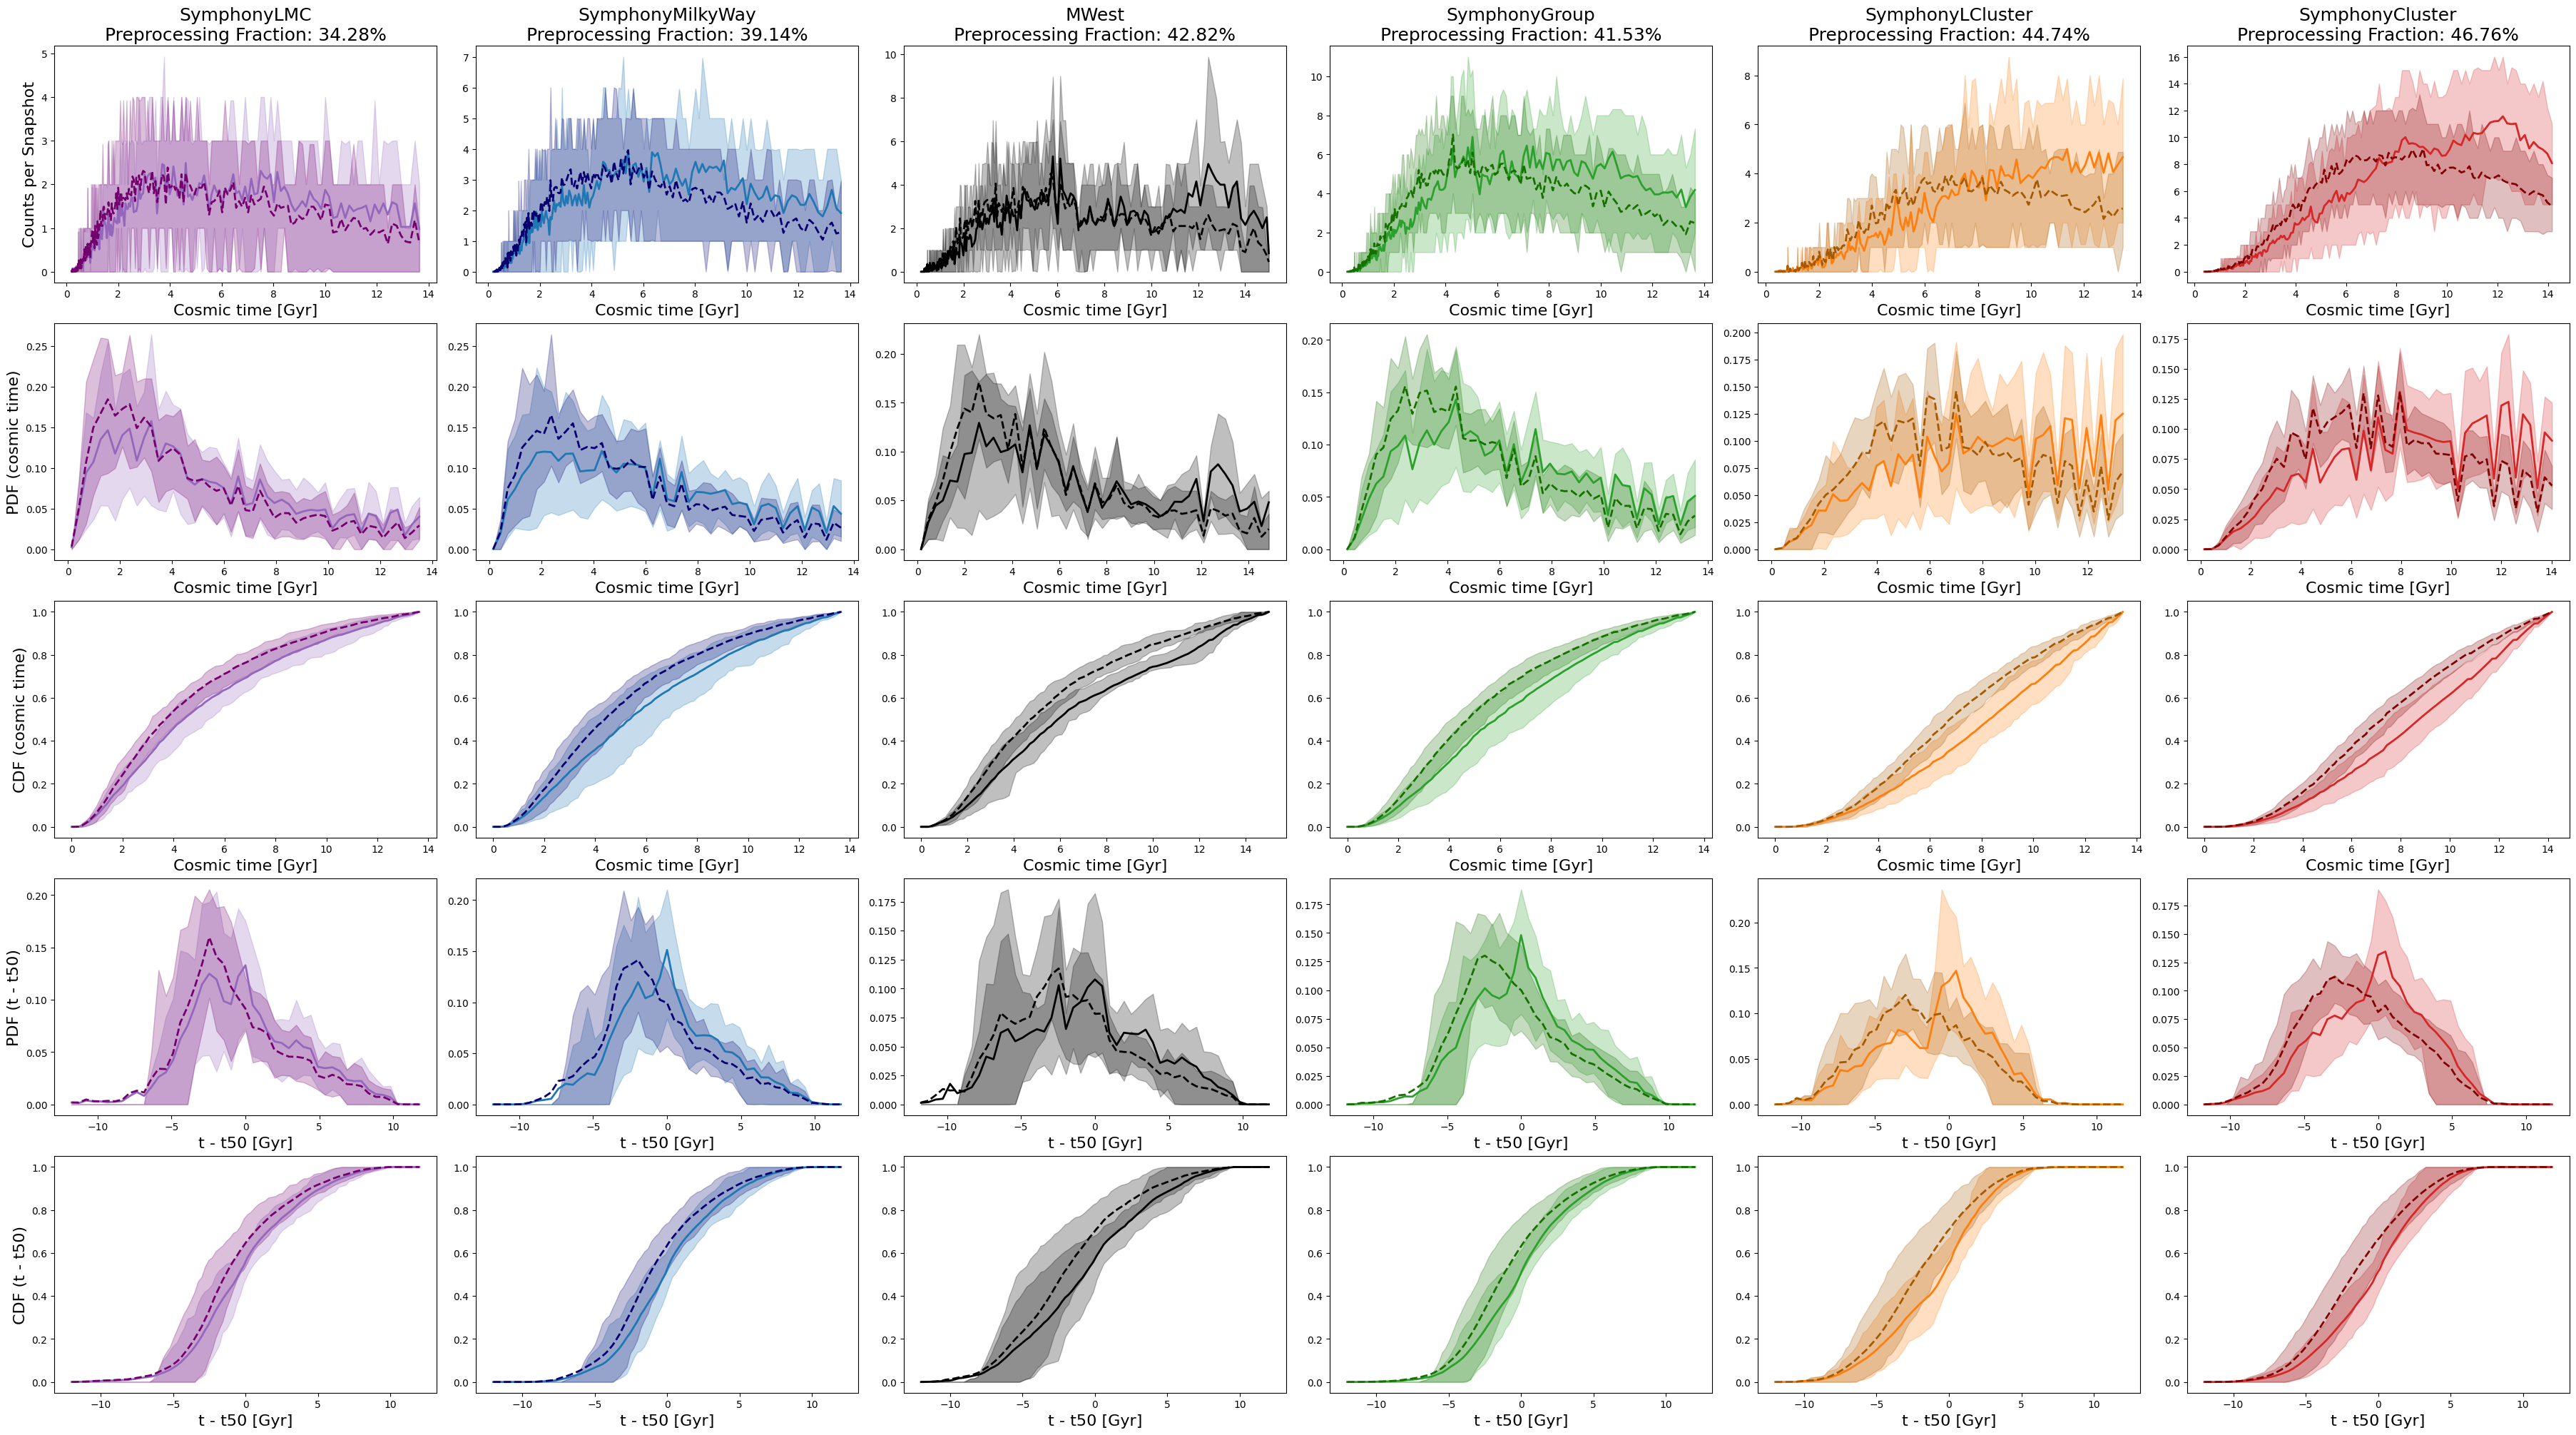

In [19]:
## merger_snap --> first infall into main host
## first_infall_snap --> first infall into ANY halo larger than itself

def load_infall_data(base_dir, suite_list, colors, avg_colors, labels, mwest_snap_data):

    suite_data = {}

    for suite in suite_list:

        print(f"\n\033[1mCurrent suite: {suite}\033[0m")

        halo_names = DEFAULT_HALO_NAMES[suite]
        sim_dir0 = symlib.get_host_directory(base_dir, suite, halo_names[0])
        scale_factors = symlib.scale_factors(sim_dir0)
        params = symlib.simulation_parameters(sim_dir0)
        nbins_suite = len(scale_factors)

        Om0 = params["Om0"]
        h100 = params["h100"]

        ## cosmic time conversion
        cosmo = FlatLambdaCDM(H0 = h100 * 100, Om0 = Om0)
        times = cosmo.age(1 / scale_factors - 1).value    ## time in Gyr

        print(f"\n\033[1mAge of universe from conversion:\033[0m {times[-1]} Gyr")

        print("\nMin/Max dt:")
        print(np.min(np.diff(times)))
        print(np.max(np.diff(times)))

        ## storing the per-host data
        hosts = []

        print(f"\n\033[1mStarting halo data read-in process:\033[0m")

        for halo_index, halo_name in enumerate(halo_names):
            print(f"\nHalo {halo_index + 1}/{len(halo_names)}: {halo_name}", end = "\r", flush = True)
            
            try:

                sim_dir = symlib.get_host_directory(base_dir, suite, halo_name)
                h, hist = symlib.read_subhalos(sim_dir)
                params = symlib.simulation_parameters(sim_dir)

                mp = params["mp"] / params["h100"]                ## particle mass used for this suite (converted to physical mp)

                host_infall_snap = hist["merger_snap"]            ## when subhalos fell into the main host
                first_infall_snap = hist["first_infall_snap"]     ## when subhalos fell into anything more massive than itself

                mvir = h["mvir"]     ## shape (# of subhalos, # of snapshots)
                ok = h["ok"]         ## shape (# of subhalos, # of snapshots)


                ## MAIN HOST INFALL:
                ## keep only subhalos which:
                ## 1. have valid infall snapshot (not interested in the main host behavior at the moment)
                ## 2. have infall mass greater than >= 300 particle masses
                ## 3. exist AT the infall snapshot (as determined by Rockstar/Symlib)

                ## removing the main host (always at snap = 0, biases results), and any
                ## subhalo whose merger_snap is a "no such event" sentinel (< 0)
                host_infall_no_main = host_infall_snap > 0                                       ## removing the main host / invalid infalls
                host_infall_rows_no_main = np.where(host_infall_no_main)[0]                      ## subhalo indices, excluding the main host
                host_infall_snaps_no_main = host_infall_snap[host_infall_no_main].astype(int)    ## subhalo infall snapshots, excluding the main host

                ## mass cut, removing subhalos below a 300 particle mass resolution limit
                mass_cut = mvir[host_infall_rows_no_main, host_infall_snaps_no_main] >= 300 * mp
                host_infall_rows_mass_ok = host_infall_rows_no_main[mass_cut]
                host_infall_snaps_mass_ok = host_infall_snaps_no_main[mass_cut]

                ## subhalo survival cut: does the subhalo exist AT the infall snapshot?
                ok_cut = ok[host_infall_rows_mass_ok, host_infall_snaps_mass_ok]
                host_infall_rows_ok = host_infall_rows_mass_ok[ok_cut]
                host_infall_snaps_ok = host_infall_snaps_mass_ok[ok_cut]

                ## INFALL INTO ANYTHING LARGER:
                first_infall_snaps_sel = first_infall_snap[host_infall_rows_ok].astype(int)
                
                valid = (host_infall_snaps_ok >= 0) & (first_infall_snaps_sel >= 0)

                host_infall_snaps_ok = host_infall_snaps_ok[valid]
                host_infall_rows_ok = host_infall_rows_ok[valid]
                first_infall_snaps_sel = first_infall_snaps_sel[valid]

                ## CONVERT FROM SNAPSHOT TO COSMIC TIME:
                host_infall_time = times[host_infall_snaps_ok]
                first_infall_time = times[first_infall_snaps_sel]

                ## t50/a50 normalization already uses each host's own peak-mass epoch, independent of a_now.
                ## lookback time specifically: "now" should match the same a_now convention used throughout the rest of this project
                ## a_lmc_50 for MWest, true z=0 (final snapshot) otherwise.
                if suite == "MWest" and halo_name in mwest_snap_data:
                    a_now = mwest_snap_data[halo_name]["a_lmc_50"]
                    t_now = cosmo.age(1.0/a_now - 1.0).value
                else:
                    t_now = times[-1]
                
                host_infall_tlb = t_now - host_infall_time
                first_infall_tlb = t_now - first_infall_time

                ## PREPROCESSING FRACTIONS:
                ## of this sample of subhalos that are NOT the main host, are above the 300 particle limit, AND are marked as "ok" by the halo finders,
                ## how many of them fell into something larger before falling into the main host?
                ## a subhalo is "preprocessed" if first_infall_snap < host_infall_snap
                ## construct time-series data f(t) --> the fraction of subhalos that were preprocessed by time (snapshot) t

                ## preprocessing label:
                is_preprocessed = first_infall_snaps_sel < host_infall_snaps_ok

                ## AUTOCORRELATION EVENT ARRAYS

                ## now building the time series information we need for the autocorrelation:
                infall_events = np.zeros(nbins_suite)
                preprocessed_events = np.zeros(nbins_suite)

                # valid bin range
                valid_bins = (host_infall_snaps_ok >= 0) & (host_infall_snaps_ok < nbins_suite)

                ## binning & accumulation (vectorized):
                host_bins = host_infall_snaps_ok[valid_bins]
                pre_bins = is_preprocessed[valid_bins].astype(int)

                ## total infall events & subset that are preprocessed
                np.add.at(infall_events, host_bins, 1)
                np.add.at(preprocessed_events, host_bins, pre_bins)

                ## convert to fraction (for diagnostics, per-snapshot-bin):
                preprocessing_fraction_t = np.full(nbins_suite, np.nan)
                mask = infall_events > 0
                preprocessing_fraction_t[mask] = preprocessed_events[mask] / infall_events[mask]


                ## infall events, weighted by the number of events that occurred
                total_infall_events = np.sum(infall_events)
                if total_infall_events > 0:
                    preprocessing_fraction_scalar = np.sum(preprocessed_events) / total_infall_events
                else:
                    preprocessing_fraction_scalar = np.nan

                print(f"\nPer-halo PREPROCESSING FRACTION:")
                print(f"Preprocessed fraction (event-weighted): {preprocessing_fraction_scalar:.4f}")
                print(f"\n##############################################################################################################################")


                ## NORMALIZATION USING A50:
                host_mvir = mvir[0, :]                                ## getting the host peak mass
                peak_mass = np.max(host_mvir)
                cross = np.where(host_mvir >= 0.5 * peak_mass)[0]     ## finding the snapshot when the host crossed over its 50% peak mass threshold

                ## SAFE NORMALIZATION
                if len(cross) == 0:
                    a50 = np.nan
                    t50 = np.nan
                else:
                    a50 = scale_factors[cross[0]]
                    t50 = times[cross[0]]

                ## normalizing time by t50
                if np.isfinite(t50):
                    host_infall_time_norm = host_infall_time - t50
                    first_infall_time_norm = first_infall_time - t50
                else:
                    host_infall_time_norm = np.full_like(host_infall_time, np.nan)
                    first_infall_time_norm = np.full_like(first_infall_time, np.nan)


                ## COUNTS: counting up # of subhalos per time bin
                host_infall_counts = np.zeros(nbins_suite)
                first_infall_counts = np.zeros(nbins_suite)

                if len(host_infall_snaps_ok) > 0:
                    u, c = np.unique(host_infall_snaps_ok, return_counts = True)
                    host_infall_counts[u] = c

                if len(first_infall_snaps_sel) > 0:
                    u, c = np.unique(first_infall_snaps_sel, return_counts = True)
                    first_infall_counts[u] = c


                ## STORING HOST DATA
                host_data = {"host_infall_snaps_ok": host_infall_snaps_ok,
                             "host_infall_rows_ok": host_infall_rows_ok,
                             "first_infall_snaps_sel": first_infall_snaps_sel,

                             ## infall scale factors (and normalizezd by a50)
                             "host_infall_sf": scale_factors[host_infall_snaps_ok],
                             "first_infall_sf": scale_factors[first_infall_snaps_sel],
                             "host_infall_sf_norm": scale_factors[host_infall_snaps_ok] / a50 if np.isfinite(a50) else np.nan,
                             "first_infall_sf_norm": scale_factors[first_infall_snaps_sel] / a50 if np.isfinite(a50) else np.nan,

                             ## infall cosmic times (and normalized by t50)
                             "host_infall_time": host_infall_time,
                             "first_infall_time": first_infall_time,
                             "host_infall_tlb": host_infall_tlb,
                             "first_infall_tlb": first_infall_tlb,
                             "host_infall_time_norm": host_infall_time_norm,
                             "first_infall_time_norm": first_infall_time_norm,
                             
                             ## infall counts
                             "host_infall_counts": host_infall_counts,
                             "first_infall_counts": first_infall_counts,

                             ## preprocessing
                             "is_preprocessed": is_preprocessed,
                             "infall_events": infall_events,
                             "preprocessed_events": preprocessed_events,
                             "preprocessing_fraction": preprocessing_fraction_scalar,
                             "preprocessing_fraction_t": preprocessing_fraction_t,

                             ## host properties
                             "host_mass": peak_mass,
                             "a50": a50,
                             "t50": t50}

                hosts.append(host_data)

            except Exception as e:
                print(f"\nSkipping halo {halo_index} ({halo_name}) in {suite}: {e}")
                continue

        ## STORING PER-SUITE DATA
        suite_data[suite] = {"scale_factors": scale_factors,
                             "times": times,
                             "hosts": hosts}

        print(f"\nSUITE PREPROCESSING SUMMARY")

        fractions = [h["preprocessing_fraction"] for h in hosts]
        print(f"Mean per-halo fraction:   {(np.nanmean(fractions) * 100):.2f}%")
        print(f"Median per-halo fraction: {(np.nanmedian(fractions) * 100):.2f}%")

        print(f"\nFinished suite: {suite} ({len(hosts)} halos)")
        print(f"========================================================================================================================")

    return suite_data


## load data once
suite_data = load_infall_data(base_dir, suite_list, colors, avg_colors, labels, mwest_snap_data = lmc_analog_sub_data)



## PLOTTING HELPERS --> functions to plot the raw, un-normalized data
def compute_raw_counts_stats(raw_counts):

    mean = np.mean(raw_counts, axis = 0)
    p16_raw = np.percentile(raw_counts, 16, axis = 0)
    p84_raw = np.percentile(raw_counts, 84, axis = 0)

    return mean, p16_raw, p84_raw


## linestyle is now an explicit parameter rather than being set after the fact via
## ax.lines[-1] -- see note on plot_pdf_hosts/plot_cdf_hosts below for why that mattered.
def plot_raw_counts(ax, x, raw_counts, color, fill = False, label = None, linestyle = "-"):

    mean, p16_raw, p84_raw = compute_raw_counts_stats(raw_counts)

    ax.plot(x, mean, color = color, lw = 2, label = label, linestyle = linestyle)

    if fill:
        ax.fill_between(x, p16_raw, p84_raw, color = color, alpha = 0.25)

#######################################################################################################################

## PDF HELPER FUNCTIONS
def compute_pdf(values, bins):

    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return None, None

    hist, edges = np.histogram(values, bins = bins, density = True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return centers, hist


def compute_pdf_stats_hosts(hosts, key, bins, mask_fn = None):

    pdf_stack = []
    centers = None

    for h in hosts:

        values = np.asarray(h[key])

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]

        if len(values) == 0:
            continue

        c, pdf = compute_pdf(values, bins)

        if pdf is None:
            continue

        centers = c
        pdf_stack.append(pdf)

    pdf_stack = np.asarray(pdf_stack)

    if len(pdf_stack) == 0:
        return None, None, None, None

    mean = np.mean(pdf_stack, axis = 0)
    p16  = np.percentile(pdf_stack, 16, axis = 0)
    p84  = np.percentile(pdf_stack, 84, axis = 0)

    return centers, mean, p16, p84


def plot_pdf_hosts(ax, hosts, key, bins, color, fill = False, mask_fn = None, label = None, linestyle = "-"):

    centers, mean, p16, p84 = compute_pdf_stats_hosts(hosts, key, bins, mask_fn)

    if mean is None:
        return

    ax.plot(centers, mean, color = color, lw = 2, label = label, linestyle = linestyle)

    if fill:
        ax.fill_between(centers, p16, p84, color = color, alpha = 0.25)

#######################################################################################################################

## CDF HELPER FUNCTIONS
def compute_cdf(values, grid):

    values = np.sort(values)
    if len(values) == 0:
        return np.zeros_like(grid)

    cdf = np.arange(1, len(values) + 1) / len(values)
    return np.interp(grid, values, cdf, left = 0, right = 1)


def compute_cdf_stats_hosts(hosts, key, grid, mask_fn = None):

    cdf_stack = []

    for h in hosts:

        values = h[key]

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue

        cdf_stack.append(compute_cdf(values, grid))

    cdf_stack = np.array(cdf_stack)

    if len(cdf_stack) == 0:
        return None, None, None

    mean = np.mean(cdf_stack, axis = 0)
    p16  = np.percentile(cdf_stack, 16, axis = 0)
    p84  = np.percentile(cdf_stack, 84, axis = 0)

    return mean, p16, p84


## same linestyle fix as plot_pdf_hosts above, same reasoning.
def plot_cdf_hosts(ax, hosts, key, grid, color, fill = False, mask_fn = None, label = None, linestyle = "-"):

    mean, p16, p84 = compute_cdf_stats_hosts(hosts, key, grid, mask_fn)

    if mean is None:
        return

    ax.plot(grid, mean, color = color, lw = 2, label = label, linestyle = linestyle)

    if fill:
        ax.fill_between(grid, p16, p84, color = color, alpha = 0.25)



## full infall figure
## solid lines --> main host infall
## dashed lines --> first infall into ANY larger halo

def make_infall_figure_full(suite_data, suite_list, colors, avg_colors, fill):

    nrows = 5
    ncols = len(suite_list)

    fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (6 * ncols, 4 * nrows), constrained_layout = True, squeeze = False)

    for i, suite in enumerate(suite_list):

        data = suite_data[suite]
        color = colors[suite]
        avg_color = avg_colors[suite]

        scale_factors = data["scale_factors"]
        hosts = data["hosts"]
        times = data["times"]

        ## defining time bins and grids
        t_bins = np.linspace(0, times[-1], 50)
        t_grid = np.linspace(0, times[-1], 100)
        trel_bins = np.linspace(-12, 12, 50)
        trel_grid = np.linspace(-12, 12, 100)

        ## preprocessing statistics (per-halo values, already event-weighted per host --
        ## see load_infall_data). nanmean/nanmedian used here since a host with zero
        ## valid infall events stores NaN for its own preprocessing_fraction.
        fractions = np.array([h["preprocessing_fraction"] for h in hosts])
        frac_mean = np.nanmean(fractions)
        frac_median = np.nanmedian(fractions)

#######################################################################################################################

        ## ROW 1: RAW COUNTS
        host_infall_counts = np.array([h["host_infall_counts"] for h in hosts])
        first_infall_counts = np.array([h["first_infall_counts"] for h in hosts])

        # main-host infall (solid)
        plot_raw_counts(ax[0, i], times, host_infall_counts, color = color, fill = fill, linestyle = "-")

        # first infall into any host (dashed)
        plot_raw_counts(ax[0, i], times, first_infall_counts, color = avg_color, fill = fill, linestyle = "--")

#######################################################################################################################

        ## ROW 2: RAW PDF --> "At what cosmic times does the average halo tend to infall?"

        plot_pdf_hosts(ax[1, i], hosts, key = "host_infall_time", bins = t_bins, color = color, fill = fill, linestyle = "-")
        plot_pdf_hosts(ax[1, i], hosts, key = "first_infall_time", bins = t_bins, color = avg_color, fill = fill, linestyle = "--")

#######################################################################################################################

        ## ROW 3: RAW CDF --> "By time t, what fraction of all infall events have already occurred?"

        plot_cdf_hosts(ax[2, i], hosts, key = "host_infall_time", grid = t_grid, color = color, fill = fill, linestyle = "-")
        plot_cdf_hosts(ax[2, i], hosts, key = "first_infall_time", grid = t_grid, color = avg_color, fill = fill, linestyle = "--")

#######################################################################################################################

        ## ROW 4: NORMALIZED PDF --> "Do infalls tend to happen before or after the host reaches half its peak mass?"

        plot_pdf_hosts(ax[3, i], hosts, key = "host_infall_time_norm", bins = trel_bins, color = color, fill = fill, linestyle = "-")
        plot_pdf_hosts(ax[3, i], hosts, key = "first_infall_time_norm", bins = trel_bins, color = avg_color, fill = fill, linestyle = "--")

#######################################################################################################################

        ## ROW 5: NORMALIZED CDF --> "Fraction of infalls occurring before/after formation epoch?"

        plot_cdf_hosts(ax[4, i], hosts, key = "host_infall_time_norm", grid = trel_grid, color = color, fill = fill, linestyle = "-")
        plot_cdf_hosts(ax[4, i], hosts, key = "first_infall_time_norm", grid = trel_grid, color = avg_color, fill = fill, linestyle = "--")

#######################################################################################################################

        ## AXIS LIMITS AND LABELS:
        ax[0, i].set_title(f"{suite}\nPreprocessing Fraction: {(frac_mean * 100):.2f}%", fontsize = 18)

    ## y-axis labels
    ax[0, 0].set_ylabel("Counts per Snapshot", fontsize = 16)
    ax[1, 0].set_ylabel("PDF (cosmic time)", fontsize = 16)
    ax[2, 0].set_ylabel("CDF (cosmic time)", fontsize = 16)
    ax[3, 0].set_ylabel("PDF (t - t50)", fontsize = 16)
    ax[4, 0].set_ylabel("CDF (t - t50)", fontsize = 16)

    ## x-labels
    for j in range(ncols):
        ax[0, j].set_xlabel("Cosmic time [Gyr]", fontsize = 16)
        ax[1, j].set_xlabel("Cosmic time [Gyr]", fontsize = 16)
        ax[2, j].set_xlabel("Cosmic time [Gyr]", fontsize = 16)
        ax[3, j].set_xlabel("t - t50 [Gyr]", fontsize = 16)
        ax[4, j].set_xlabel("t - t50 [Gyr]", fontsize = 16)

    return fig, ax


## entrypoint:
fig, ax = make_infall_figure_full(suite_data, suite_list, colors, avg_colors, fill = True)

#fig.savefig("Infalls (cosmic time using astropy).png", bbox_inches = "tight")
plt.show()

<a id = "correlation_functions"></a>
## Correlation Functions
[Back to Table of Contents](#table_of_contents)

[d'Souza & Bell (2021)](https://arxiv.org/pdf/2104.13249) describe a cross-correlation function (estimator 𝜉 (𝑡) = (𝑁_𝑅/𝑁_𝑆) * (𝐷𝐷(𝑡)/𝐷𝑅(𝑡))− 1). N_R is the "number of points in the random catalog," N_S is the "number of subhalos", DD(t) is the "count of pairs (subhalos-massive progenitors) accreted within time t and t + dt," and DR(t) is the "count of pairs (random-massive progenitors).

* First, we need to create this random catalog (d'Souza & Bell Figure 1)
* Next, we need to use it to generate their cross-correlation function using the random catalog and the estimator

The full workflow goes as follows:
1. Use subhalo Mpeaks to classify "massive progenitors" (subhalos with Mpeak >= 0.1 Mpeak_host). The general subhalo population has mass cuts derived from the number of particles corresponding to 1e9 (physical) Msun for SymphonyMilkyWay (i.e N_particles * particle_mass for that suite). We also need to exclude the massive progenitors from the list of "associated" subhalos, to avoid trivial 0-lag self-pairings
2. Build Figure 1 (general subhalo population, separated into "all," "destroyed by z = 0," "surviving at z = 0," and "surviving inside host Rvir at z = 0")
3. Use the Deason et. al. criterion described in the paper to tag subhalos as "associated." Associated subhalos have the condition that they were inside a massive progenitor's Rvir for at least 1 Gyr preceding the subhalo's infall into the main host. This creates two, related populations: all subhalos regardless of association, and subhalos "associated" with some massive progenitor. The Deason tagging does NOT exclude any subhalos, it's just another, stricter subset of the subhalos.
4. Compute the cross-correlation using the estimator $\xi(t)=\frac{N_R}{N_S} \frac{DD(t)}{DR(t)} - 1$. There will be two separate DD(t) computations, one built from all subhalos and another from only Deason-tagged subhalos. Bootstrap resampling of the random catalog (Figure 1) creates DR(t).

Reference suite: SymphonyMilkyWay
Particle mass in reference suite = 4.028e+05 Msun
1e9 Msun = 2482.4 particles is now the fixed particle count cutoff applied to every suite

Reference host Rvir (z=0, SymphonyMilkyWay host 0) = 272.0 kpc
80 kpc = 0.2941 x Rvir -- this FRACTION is now applied to every host's own Rvir to get its equivalent '80 kpc' point
Loading suite SymphonyLMC...
SymphonyLMC: particle mass = 5.035e+04 Msun, cutoff = 2482 particles = 1.250e+08 Msun (OK)
Starting on host 39/39
Total: 2247
Destroyed: 1081
Surviving: 1166
Surviving inside rvir: 885
Massive progenitors: 50, Subhaloes (MPs excluded): 2197, Deason-tagged: 125
MPs with valid crossing time (0.2941 x host Rvir): 46, without: 4
Destroyed subhaloes with valid destruction time (Fig 15 population): 1040

Loading suite SymphonyMilkyWay...
SymphonyMilkyWay: particle mass = 4.028e+05 Msun, cutoff = 2482 particles = 1.000e+09 Msun (OK)
Starting on host 45/45
Total: 3764
Destroyed: 1739
Surviving: 2025
Surviving inside 

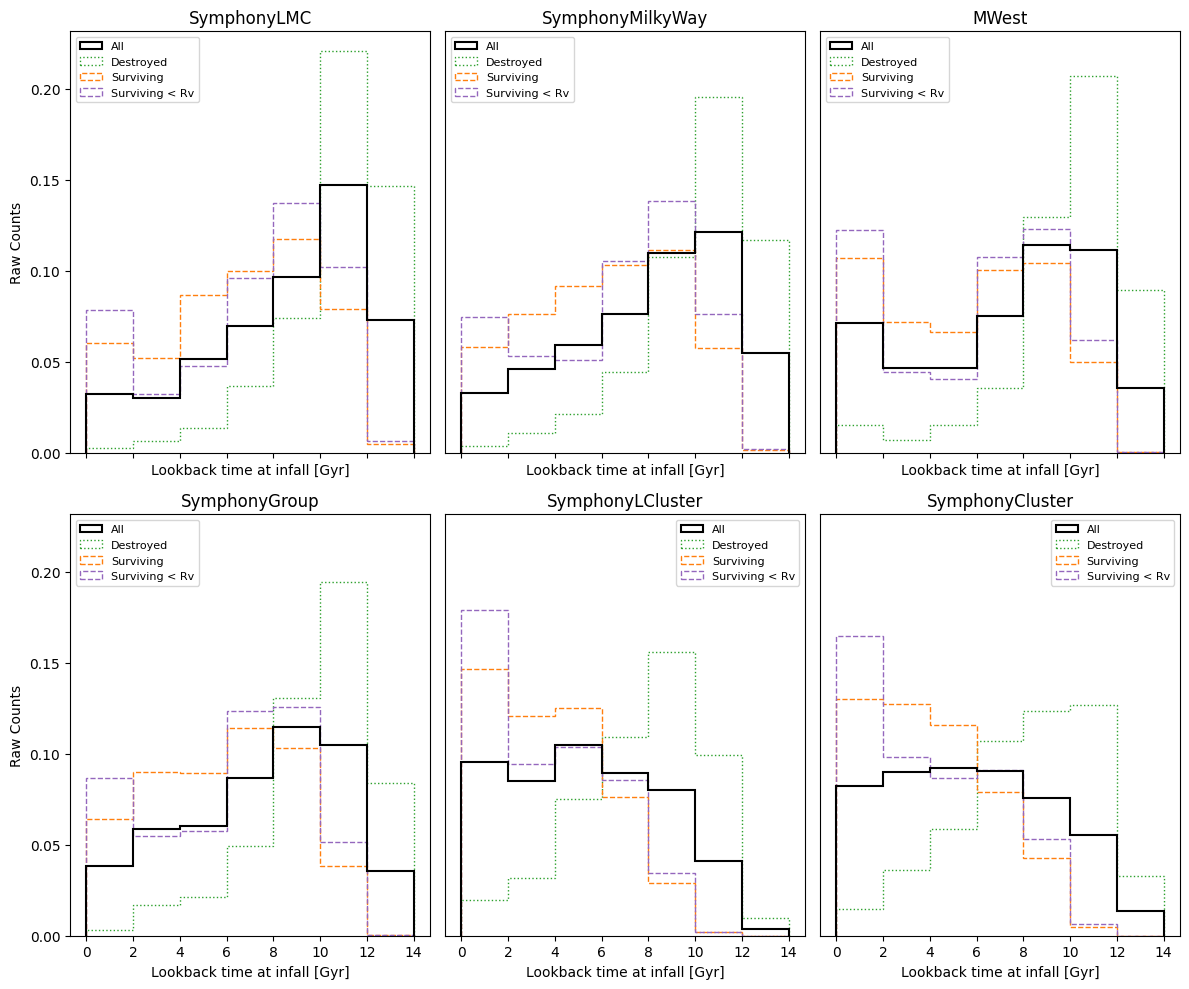

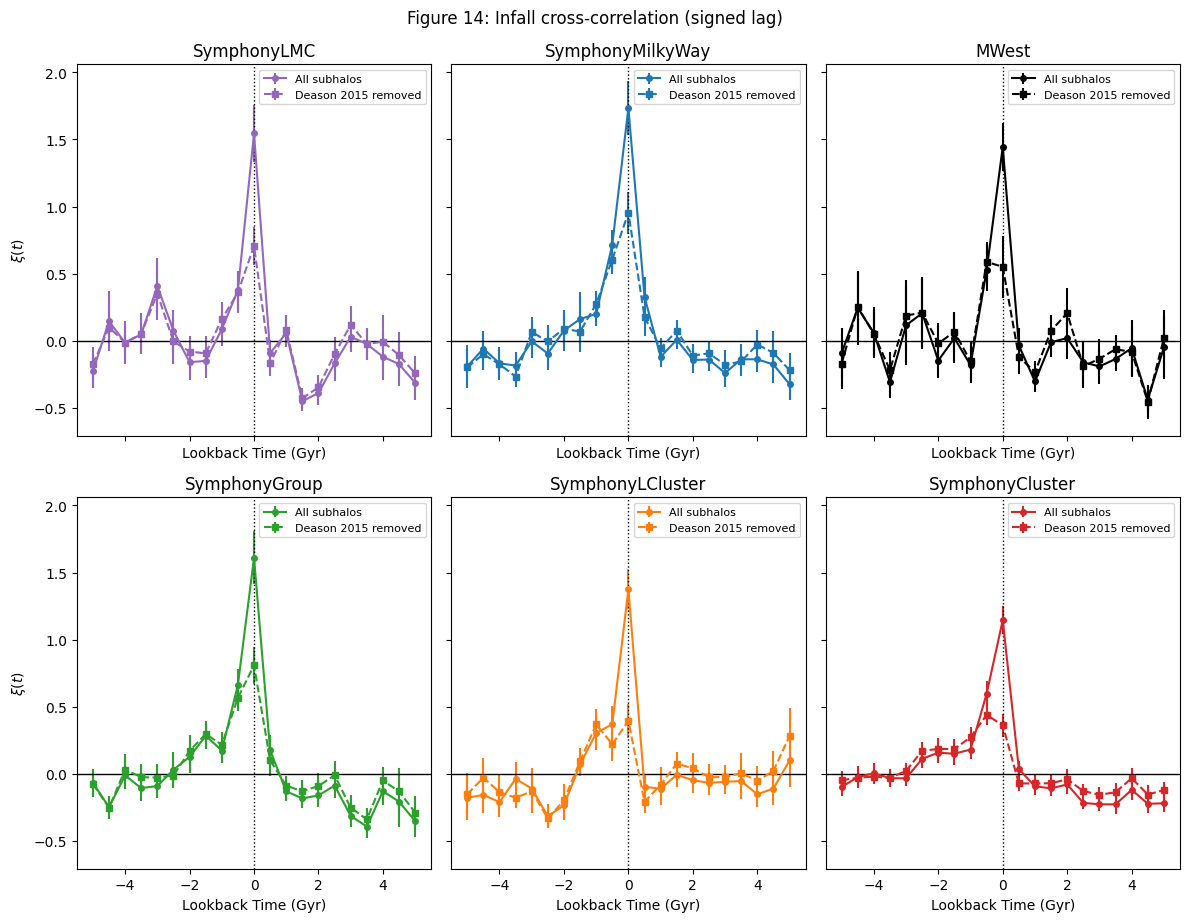

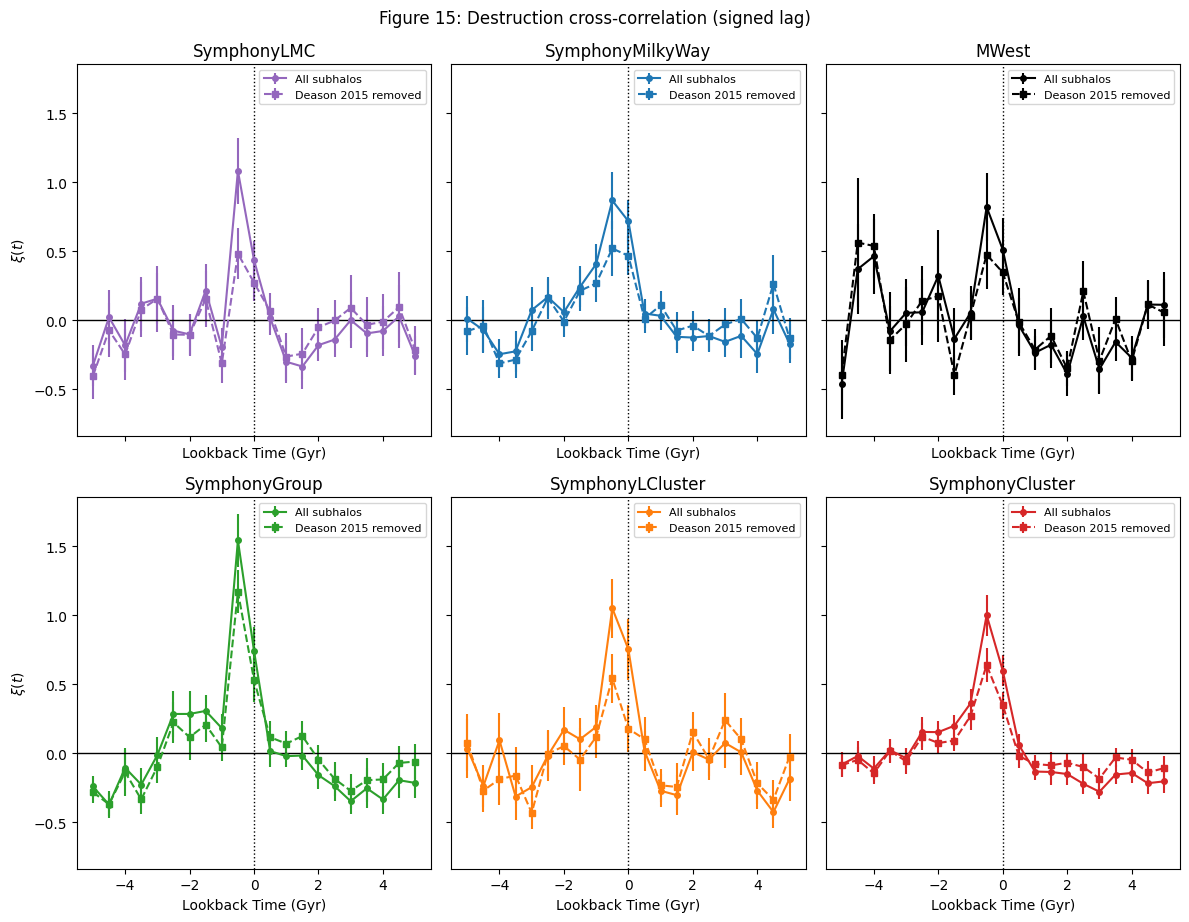

In [20]:
## PART 0: CONFIG
## Setup for all the physical/statistical choices throughout the pipeline:
## resolution-matched mass cutoff for the general subhalo population (Fig 1 + subhalos used in pairings in Fig 14)
## mass-ratio cutoff defining "massive progenitors"
## Deason et. al. (2015) spatio-temporal association window
## shared bin edges, so every suite/panel is directly comparable

## d'Souza & Bell use ELVIS, which is (somewhat) analogous to SymphonyMilkyWay
## They use a 10^9 Msun mass cutoff for their subhalos
## For consistent MASS RESOLUTION across suites of differing particle mass, this 10^9 Msun is converted to a PARTICLE COUNT using SymphonyMilkyWay
## and then that same particle count is used (converted through the particle mass of a given suite) to get the mass cutoff for that suite
## This is a "resolution-matched" analog of their analysis that should apply to all suites

ref_suite = "SymphonyMilkyWay"
ref_mass_msun = 1e9

ref_sim_dir = symlib.get_host_directory(base_dir, ref_suite, 0)
ref_params = symlib.simulation_parameters(ref_sim_dir)
ref_particle_mass_msun = ref_params["mp"] / ref_params["h100"]   ## convert from h^-1 Msun to physical Msun
n_particles_cut = ref_mass_msun/ref_particle_mass_msun

print(f"Reference suite: {ref_suite}")
print(f"Particle mass in reference suite = {ref_particle_mass_msun:.3e} Msun")
print(f"1e9 Msun = {n_particles_cut:.1f} particles is now the fixed particle count cutoff applied to every suite")
print()

## the Deason criterion referenced in d'Souza & Bell applies to subhalos that have been within the virial radius of a massive progenitor for
## "two consecutive timesteps" (in ELVIS), or a total CONTINUOUS time of 1 Gyr immediately prior to the subhalo's own infall into the main host
## Symphony's snapshot spacing is not necessarily the same as ELVIS, so instead the number of snapshots that span this 1 Gyr window is
## calculated per host and per subhalo rather than assuming a fixed window
deason_window_gyr = 1.0

## Massive progenitors are subhalos whose PEAK historical mass (Mpeak) is >= 10% of the main host's z = 0 virial mass (Mvir)
## This is computed directly per host (i.e against that host's z = 0 Mvir)
## Since the host's own mass grows significantly over time, an early-infalling major merger at some time can fail the 10% threshold criterion at z = 0,
## because the host mass generally only grows and subhalos generally get stripped and lose mass
## Worth keeping in mind...
## Mpeak / Mvir_host is already scale invariant, no conversions needed
progen_mass_ratio_cut = 0.1

## Fig 15's anchor point is this: "we find that referencing to a time when the massive progenitor first
## crosses a galacto-centric distance of 80 kpc maximises the cross-correlation signal for the
## destruction of subhaloes" -- NOT the massive progenitor's infall time (like in Fig. 14)
## Units: kpc, physical, matching h["x"], h["rvir"]'s existing units elsewhere in this pipeline.

## To generalize across suites the same way the mass cutoff is resolution-matched, instead the FRACTION of Rvir that 80 kpc represents
## in the reference suite (SymphonyMilkyWay) is fixed, then that same fraction, scaled by each HOST's own z=0 Rvir, becomes the crossing distance
## for every other host/suite.
mp_crossing_distance_kpc = 80.0
ref_h, ref_hist = symlib.read_subhalos(ref_sim_dir)
ref_scale_factors = symlib.scale_factors(ref_sim_dir)
ref_final_snap = len(ref_scale_factors) - 1
ref_host_rvir_z0 = ref_h["rvir"][0, ref_final_snap]
mp_crossing_frac_of_rvir = mp_crossing_distance_kpc / ref_host_rvir_z0

print(f"Reference host Rvir (z=0, {ref_suite} host 0) = {ref_host_rvir_z0:.1f} kpc")
print(f"{mp_crossing_distance_kpc:.0f} kpc = {mp_crossing_frac_of_rvir:.4f} x Rvir "
      f"-- this FRACTION is now applied to every host's own Rvir to get its equivalent '80 kpc' point")

## LAG MODE TOGGLE:
## "signed" keeps the sign of the difference (positive = infall before the anchor time, negative = infall after the anchor time)
## "absolute" folds both directions into one magnitude (more faithful to Fig 14)
## These toggles can be set independently for each figure (i.e if you want "signed" for Fig 14 but "absolute" for Fig 15)
fig14_lag_mode = "signed"     ## "signed" or "absolute"
fig15_lag_mode = "signed"     ## "signed" or "absolute"

## Bin edges appropriate to the lag mode:
## [0, max_lag] for "absolute", [-max_lag, max_lag] for "signed"
def make_bin_edges(lag_mode, max_lag = 5.0, step = 0.5):
    if lag_mode == "absolute":
        return np.arange(0.0, max_lag + step, step)
    elif lag_mode == "signed":
        # edges at -5.25, -4.75, ..., -0.25, 0.25, ..., so bin centers land on 0, ±0.5, ±1.0, ...
        half = step / 2.0
        return np.arange(-max_lag - half, max_lag + half + step, step)
    else:
        raise ValueError(f"Lag mode must be 'signed' or 'absolute', got {lag_mode!r}")

fig1_bin_edges = np.linspace(0.0, 14, 8)     ## 7 bins, 0 to 14 Gyr like Figure 1 --> unaffected by lag-mode toggle, Fig 1 isn't a time lag
fig14_bin_edges = make_bin_edges(fig14_lag_mode)
fig15_bin_edges = make_bin_edges(fig15_lag_mode)

oversample = 20                              ## random catalog size = oversample x N_subs per host
                                             ## reduces shot noise in DR(t)
RNG = np.random.default_rng(42)              ## random number generator with a seed for reproducible bootstrap draws/resampling

##############################################################################################################################

## PART 1: HELPERS (used inside the main dataloading loop and for the cross-correlation estimator)

## Returns the snapshot indices spanning the window_gyr period immediately preceding infall_snap (not including infall_snap itself)
## i.e "how far back do we need to look for this particular subhalo, given THIS host's own (possibly non-uniform) snapshot spacing
## Walks backward through THIS host's lookback_table until the elapsed time reaches window_gyr, or it runs out of earlier snapshots to check
## returns None if there isn't enough simulation history before infall_snap to span the window
def deason_window_snapshots(lookback_table, infall_snap, window_gyr = deason_window_gyr):

    infall_time = lookback_table[infall_snap]
    target_time = infall_time + window_gyr      ## further back = larger lookback time

    snap = infall_snap - 1
    if snap < 0:
        return None

    while snap > 0 and lookback_table[snap] < target_time:
        snap -= 1

    if lookback_table[snap] < target_time:
        return None                              ## ran out of history before spanning a full window

    return np.arange(snap, infall_snap)

## For each subhalo in sub_idx_pop, check whether it was CONTINUOUSLY within a massive progenitor's Rvir across the ~1 Gyr window
## immediately preceding ITS OWN infall into the main host
## A subhalo is tagged True as soon as it satisfies this criterion against ANY ONE of the massive progenitors in mp_sub_idx
## Subhalos do not need to be tested against multiple massive progenitors, since there is no meaningful difference between
## "associated with 1 massive progenitor" and "associated with 2+," at least for the purposes of Fig 14's tagging
## Returns a Boolean array of the same length/order as sub_idx_pop
def tag_deason_subhalos(h, lookback_table, mp_sub_idx, sub_idx_pop, sub_infall_snap_pop):

    deason_tag = np.zeros(len(sub_idx_pop), dtype = bool)

    for j in range(len(sub_idx_pop)):
        s_idx = sub_idx_pop[j]
        s_infall_snap = sub_infall_snap_pop[j]

        window_snaps = deason_window_snapshots(lookback_table, s_infall_snap)
        if window_snaps is None:
            continue              ## not enough simulation history before infall to test

        for k in range(len(mp_sub_idx)):
            mp_idx = mp_sub_idx[k]

            ## both the subhalo and the massive progenitor must actually exist at EVERY snapshot in the window
            ## if either drops out ("ok" = False) anywhere in the window, we can't evaluate their separation there, so skip this MP
            ok_window = h["ok"][s_idx, window_snaps] & h["ok"][mp_idx, window_snaps]
            if not np.all(ok_window):
                continue

            ## physical separation between the subhalo and the massive progenitor at every snapshot in the window,
            ## compared against the massive progenitor's Rvir at that snapshot (i.e "was the subhalo a subhalo of the massive progenitor")
            sep = np.linalg.norm(h["x"][s_idx, window_snaps] - h["x"][mp_idx, window_snaps], axis = 1)
            rvir_mp = h["rvir"][mp_idx, window_snaps]

            ## np.all is what makes this a "continuous" association test
            ## EVERY snapshot in the window must satisfy sep < rvir_mp
            if np.all(sep < rvir_mp):
                deason_tag[j] = True
                break                      ## subhalo tagged to at least one massive progenitor, no need to check others

    return deason_tag

## The snapshot at which a subhalo is destroyed/merges with the main progenitor branch --> D'Souza & Bell's t_disruption.
## Defined as the first snapshot AFTER the last snapshot the subhalo was tracked ("ok" = True)
## i.e. the snapshot immediately following its last real appearance in the catalog, Symlib's check for when it merged/was disrupted"
## Uses the LAST TRUE occurrence (rather than the first False after some earlier True),
## so a single transient "ok = False" blip (halo-finder noise) doesn't get mistaken for the actual destruction event,
## if the subhalo is re-detected at a later snapshot.
 
## Returns None if the subhalo is still tracked at final_snap
## (i.e. it's a SURVIVOR, not a destroyed subhalo, there's no destruction time to compute).
def find_destruction_snap(h, s_idx, final_snap):

    ## tracking "ok" for all valid subhalo indices s_idx
    ok_track = h["ok"][s_idx, :final_snap + 1]
    true_snaps = np.where(ok_track)[0]
    
    if len(true_snaps) == 0:
        return None                      ## never actually tracked (shouldn't happen given upstream selection)
        
    last_true = true_snaps[-1]
    
    if last_true == final_snap:
        return None                      ## still exists at z=0 --> this is a survivor, not destroyed
    
    return last_true + 1

## The first snapshot AT OR AFTER the massive progenitor's own infall at which its galactocentric distance from the host drops below crossing_kpc
## D'Souza & Bell's Fig. 15 anchor time ("first crosses a galacto-centric distance of 80 kpc").
 
## crossing_kpc is passed in explicitly since it is HOST-SPECIFIC: mp_crossing_frac_of_rvir x this host's own z=0 Rvir,
## so the crossing distance scales with the host's own dynamical scale
 
## Searches forward from mp_infall_snap (not from snap 0) since the massive progenitor must already be inside the host's virial radius before
## it can be meaningfully "crossing" some fraction of the host's Rvir -- this crossing generically happens some time AFTER infall.
 
## Returns None if the massive progenitor never gets that close before the simulation ends
## (e.g. destroyed while still far out, or still approaching at z=0).
def find_mp_crossing_snap(h, mp_idx, mp_infall_snap, final_snap, crossing_kpc):

    for snap in range(mp_infall_snap, final_snap + 1):
        
        if not h["ok"][mp_idx, snap]:
            continue
            
        r = np.linalg.norm(h["x"][mp_idx, snap])
        
        if r < crossing_kpc:
            return snap
            
    return None


## Pairwise (event_time - mp_time) lags for one halo's anchor time(s) against one population of event times
## --> (real data, for DD(t), or random-catalogue draws, for DR(t)).
## lag_mode = "signed": positive = event happened BEFORE the anchor time, negative = AFTER the anchor time.
## lag_mode = "absolute": turns both directions into a single magnitude |lag| (matches D'Souza & Bell's own Fig. 14/15 axes, which only run 0-5 Gyr).
## Returns every (event, anchor) 
def pair_lags(mp_times, event_times, mode = "signed"):
    
    if len(mp_times) == 0 or len(event_times) == 0:
        return np.array([])
 
    lag = (event_times[:, None] - mp_times[None, :]).ravel()
    return np.abs(lag) if mode == "absolute" else lag


## Computes the Davis & Peebles cross-correlation estimator xi(t) = (N_R/N_S)*(DD(t)/DR(t))-1
## DD(t) = count of (massive progenitor, associated subhalo) pairs whose infall time lag falls in bin t
## DR(t) = count of (massive progenitor, random subhalo) pairs whose infall time lag falls in bin t
## N_S = total number of subhalos actually paired (summed across all hosts in this suite)
## N_R = total number of random-catalog points actually paired (summed across all hosts in this suite)

## N_R/N_S prefactor corrects for the fact that N_R is deliberately made much larger than N_S to reduce shot noise in DR(t)
## Without it, DD/DR would be systematically suppressed simply because the random catalog has more points feeding it, nothing to do with real clustering

## PARAMETERS:
## host_data = list of per-host dicts with "mp_infall_time", "sub_infall_time", "deason_tag"
## all_sub_times = pooled empirical subhalo infall time distribution for THIS suite
##                (the random catalog is drawn from Fig 1 (without massive progenitors) via bootstrap resampling WITH REPLACEMENT)
## remove_deason = if True, subhalos with deason_tag = True are removed from the
##                 subhalo population before pairing (this produces the "Deason-removed curve")
## DD and DR pairs are pooled across every host in a suite prior to binning,
## then binned once at the end (rather than computing xi for each and averaging)
## This gives much better small-number statistics than a per-host calculation, since the median number of massive progenitors per host is only ~1.

## this function is used for both the surviving subhalos cross-correlation and the destroyed subhalos cross-correlation
def compute_xi(host_data, all_event_times, bin_edges, mp_key, event_key, deason_key = None,
               remove_deason = False, lag_mode = "signed", oversample = oversample, rng = RNG):
    
    dd_all, dr_all = [], []
    n_s_total = 0
    n_r_total = 0

    for hd in host_data:
        event_t = hd[event_key]
        
        if remove_deason:
            event_t = event_t[~hd[deason_key]]
        mp_t = hd[mp_key]

        n_s_total += len(event_t)
        dd_all.append(pair_lags(mp_t, event_t, mode = lag_mode))

        ## Random catalog: bootstrap draw (with replacement) from this suite's pooled, empirical subhalo infall-time distribution
        ## sized to "oversample" x this host's own (real) subhalo count, so DR(t) has much better statistics than DD(t) alone would
        n_draw = max(int(len(event_t) * oversample), 1)
        rand_t = rng.choice(all_event_times, size = n_draw, replace = True)
        n_r_total += len(rand_t)
        dr_all.append(pair_lags(mp_t, rand_t, mode = lag_mode))

    dd_lags = np.concatenate(dd_all) if dd_all else np.array([])
    dr_lags = np.concatenate(dr_all) if dr_all else np.array([])

    DD, _ = np.histogram(dd_lags, bins = bin_edges)
    DR, _ = np.histogram(dr_lags, bins = bin_edges)

    norm = n_r_total / n_s_total if n_s_total > 0 else np.nan

    ## bins where DR = 0 (no random pairs landed there) would otherwise raise a divide-by-zero error
    ## errstate suppresses the warning and lets xi come out as inf/nan in those bins, which is the correct behavior since
    ## the estimator is truly undefined there rather than crashing
    with np.errstate(divide = "ignore", invalid = "ignore"):
        xi = norm * (DD/DR) - 1.0

    centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    return centers, xi, DD, DR
    
## halo-level bootstrap error on xi(t):
## resample the hosts in this suite WITH REPLACEMENT n_boot times, recompute xi(t) each time (pooling DD/DR across the resampled set of hosts),
## and take the standard deviation across bootstrap realizations as the errorbar in each bin
## this captures halo-to-halo scatter (e.g some hosts having unusually many/few massive progenitors or subhalos) better than a naive Poisson-counting
## error on the pooled DD/DR pair counts would, since it doesn't assume all pairs are statistically independent draws
## (pairs from the same host share that host's particular accretion history)

## this is also generalized to work for both surviving and destroyed subhalos
def bootstrap_xi(host_data, all_event_times, bin_edges, mp_key, event_key, deason_key = None,
                  remove_deason = False, lag_mode = "signed", n_boot = 200, oversample = oversample):

    n_h = len(host_data)
    boot_xis = []
    centers = None

    for _ in range(n_boot):
        idx = RNG.integers(0, n_h, size = n_h)      ## resample host INDICES with replacement
        boot_data = [host_data[i] for i in idx]     ## build the resampled host list
        centers, xi, _, _ = compute_xi(boot_data, all_event_times, bin_edges, mp_key, event_key,
                                       deason_key = deason_key, remove_deason = remove_deason,
                                       lag_mode = lag_mode, oversample = oversample, rng = RNG)
        
        boot_xis.append(xi)

    boot_xis = np.array(boot_xis)

    return centers, np.nanstd(boot_xis, axis = 0)

#################################################################################################################################

## PART 2: MAIN LOOP
## for each suite, for each host, load data ONCE and build BOTH:
## a) the Fig 1 populations (All / Destroyed / Surviving / Surviving < Rvir)
## b) Fig 14 data structures (massive progenitor infall times, subhalo infall times, Deason association tag)
## Both are done in the same pass, since both figures need the same underlying per-host quantities (infall_times, masses, positions)

suite_fig1_results = {}
suite_fig14_hostdata = {}
suite_fig15_hostdata = {}

for suite_index, suite_name in enumerate(suite_list):

    ## Fig 1 accumulators --> flat lists across ALL hosts in this suite, converted to arrays after the loop finishes
    all_infall_times = []    
    destroyed_infall_times = []
    surviving_infall_times = []
    surviving_inside_rvir_infall_times = []

    ## Fig 14 and 15 accumulator: one dict per HOST (kept separate, unlike Fig 1)
    host_data_fig14 = []
    host_data_fig15 = []

    print(f"Loading suite {suite_name}...")

    ## particle mass and cosmology parameters are constant across a suite, so we can just use the first host to get these quantities
    sim_dir_0 = symlib.get_host_directory(base_dir, suite_name, 0)
    params = symlib.simulation_parameters(sim_dir_0)
    scale_factors = symlib.scale_factors(sim_dir_0)
    h100 = params["h100"]
    Om0 = params["Om0"]
    particle_mass_physical = params["mp"]/h100      ## convert from h^-1 Msun to physical Msun

    ## astropy cosmology object, used to convert every host's own snapshot scale factors into lookback times (Gyr) further down
    ## also constant across a suite, no need to compute multiple times
    cosmo = FlatLambdaCDM(H0 = h100 * 100, Om0 = Om0)

    ## this suite's mass cutoff --> same particle count as 1e9 Msun in SymphonyMilkyWay
    ## but converted using THIS suite's particle mass
    ## equal resolving power across suites, not equal absolute Msun
    mass_cut_suite = n_particles_cut * particle_mass_physical
    
    print(f"{suite_name}: particle mass = {particle_mass_physical:.3e} Msun, "
          f"cutoff = {n_particles_cut:.0f} particles = {mass_cut_suite:.3e} Msun "
          f"({'OK' if n_particles_cut >= 300 else 'BELOW 300-particle floor!'})")

    n_hosts = symlib.n_hosts(suite_name)

    ## diagnostics for the NEW Fig. 15 quantities specifically -- how often do we actually get
    ## a valid 80kpc-crossing time / destruction time, vs. how often is one unavailable
    n_mp_no_crossing = 0
    n_mp_with_crossing = 0
    
    for i_host in range(n_hosts):

        print(f"Starting on host {i_host+1}/{n_hosts}", end = "\r", flush = True)
        
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        h, hist = symlib.read_subhalos(sim_dir)

        ## scale factors (and everything derived from it: lookback_table, final_snap, etc) must be read PER HOST, not reused from host 0
        ## this is because snapshot spacing can differ slightly between hosts in a given suite (e.g after restarting partway through), so
        ## reusing host 0's timing risks misaligned snapshots, final snaps, and lookback tables
        scale_factors = symlib.scale_factors(sim_dir)
        z = (1.0/scale_factors) - 1.0
        lookback_table = (cosmo.age(0) - cosmo.age(z)).value
        final_snap = len(scale_factors) - 1

        ## host's z = 0 virial mass
        host_mvir_z0 = h["mvir"][0, final_snap]

        ## remove host, get valid infall times
        sub_idx = np.arange(1, len(hist))       ## removing the host

        ## 2. select valid infall times
        infall_snap = hist["merger_snap"][sub_idx]  ## snapshot when subhalos first fell into the host's virial radius
        valid_infall = infall_snap >= 0             ## removing any -1's
        sub_idx = sub_idx[valid_infall]
        infall_snap = infall_snap[valid_infall]
        infall_time = lookback_table[infall_snap]   ## convert snapshot --> lookback time (Gyr)

        mpeak = hist["mpeak"][sub_idx]              ## each subhalo's PEAK mass (Msun)

        ## FIG 1:
        ## for Fig 1, resolution-matched mpeak cutoff only
        valid_mass = mpeak >= mass_cut_suite         ## mass cutoff described above
        sub_idx_fig1 = sub_idx[valid_mass]
        infall_time_fig1 = infall_time[valid_mass]

        ## "surviving" = still tracked (exists) at the z = 0 snapshot
        ## "destroyed" = merged/tidally disrupted by z = 0, no longer a tracked object
        ## h["ok"] is Symlib's existence flag, so the partition between "surviving" and "destroyed" is exact by construction
        surviving = h["ok"][sub_idx_fig1, final_snap]
        destroyed = ~surviving                           ## destroyed = not surviving

        ## of the surviving subhalos
        host_rvir_z0 = h["rvir"][0, final_snap]
        sub_pos_z0 = h["x"][sub_idx_fig1, final_snap]
        r_sub = np.linalg.norm(sub_pos_z0, axis = 1)
        inside_rvir = r_sub < host_rvir_z0
        surviving_inside_rvir = surviving & inside_rvir

        ## save populations
        all_infall_times.extend(infall_time_fig1)
        surviving_infall_times.extend(infall_time_fig1[surviving])
        destroyed_infall_times.extend(infall_time_fig1[destroyed])
        surviving_inside_rvir_infall_times.extend(infall_time_fig1[surviving_inside_rvir])

        ## FIG 14/15:
        
        ## Fig 14 massive progenitors and subhalo population (SAME resolution-matched cut as Fig 1) + Deason tagging'
        ## these variables are reused for Fig 15 as well
        is_subhalo = valid_mass                                        ## reusing Fig 1 mask
        is_mp = (mpeak / host_mvir_z0) >= progen_mass_ratio_cut        ## d'Souza & Bell's > 1:10 cut

        ## massive progenitors: their infall times (the "anchor" times for the cross-correlation)
        ## and their own catalog indices (needed below to look up position/Rvir history for Deason tagging of subhalos)
        mp_sub_idx = sub_idx[is_mp]
        mp_infall_time = infall_time[is_mp]
        mp_infall_snap = infall_snap[is_mp]

        ## subhalo population for the cross-correlation must EXCLUDE the massive progenitors, to avoid the trivial self-pairings
        ## these self-pairings would artificially spike DD(t) at t = 0
        sub_only_mask = is_subhalo & (~is_mp)
        sub_idx_pop = sub_idx[sub_only_mask]
        sub_infall_time_pop = infall_time[sub_only_mask]
        sub_infall_snap_pop = infall_snap[sub_only_mask]

        ## Deason et. al. (2015) tag: for each subhalo in the population above, was it CONTINUOUSLY within a massive progenitor's Rvir for the ~1Gyr
        ## immediately prior to its infall into the main host?
        ## this is a MASK, not a pairing rule --> doesn't affect "All Subhalos" curve at all, just removes subhalos to make the "Deason-removed" curve 
        deason_tag = tag_deason_subhalos(h, lookback_table, mp_sub_idx, sub_idx_pop, sub_infall_snap_pop)

        host_data_fig14.append({"mp_infall_time": mp_infall_time,
                                "sub_infall_time": sub_infall_time_pop,
                                "deason_tag": deason_tag})

        ## FIG 15 data:
        ## This host's own crossing distance: mp_crossing_frac_of_rvir x THIS host's z=0 Rvir
        host_crossing_kpc = mp_crossing_frac_of_rvir * host_rvir_z0

        ## Anchor: for each massive progenitor, the first snapshot >= its own infall at which
        ## it comes within host_crossing_kpc of the host -- NOT its infall time (that's Fig. 14's anchor).
        mp_crossing_time_list = []
        for k in range(len(mp_sub_idx)):
            crossing_snap = find_mp_crossing_snap(h, mp_sub_idx[k], mp_infall_snap[k], final_snap,
                                                    crossing_kpc = host_crossing_kpc)
            if crossing_snap is None:
                n_mp_no_crossing += 1
                continue
            n_mp_with_crossing += 1
            mp_crossing_time_list.append(lookback_table[crossing_snap])
        mp_crossing_time = np.array(mp_crossing_time_list)

        ## Event: destruction time of every DESTROYED subhalo in the general (MP-excluded) population
        ## survivors have no destruction time and are excluded here entirely
        ## (not just masked to False -- they simply don't belong to this population at all).
        destroyed_mask_pop = ~h["ok"][sub_idx_pop, final_snap]
        destroyed_idx_pop = sub_idx_pop[destroyed_mask_pop]
        destroyed_deason_tag = deason_tag[destroyed_mask_pop]   ## same tag, just restricted to the destroyed subset
 
        destruction_time_list = []
        keep_mask = np.zeros(len(destroyed_idx_pop), dtype=bool)
        for j in range(len(destroyed_idx_pop)):
            
            d_snap = find_destruction_snap(h, destroyed_idx_pop[j], final_snap)
            
            if d_snap is None:
                continue   ## shouldn't happen given destroyed_mask_pop, but defensive
            
            destruction_time_list.append(lookback_table[d_snap])
            keep_mask[j] = True
 
        destroyed_sub_time = np.array(destruction_time_list)
        destroyed_deason_tag = destroyed_deason_tag[keep_mask]

        host_data_fig15.append({"mp_crossing_time": mp_crossing_time,
                                "destroyed_sub_time": destroyed_sub_time,
                                "destroyed_deason_tag": destroyed_deason_tag})


    ## convert Fig 1 lists to arrays, store
    all_infall_times = np.asarray(all_infall_times)
    destroyed_infall_times = np.asarray(destroyed_infall_times)
    surviving_infall_times = np.asarray(surviving_infall_times)
    surviving_inside_rvir_infall_times = np.asarray(surviving_inside_rvir_infall_times)
    
    suite_fig1_results[suite_name] = {"all": all_infall_times,
                                      "destroyed": destroyed_infall_times,
                                      "surviving": surviving_infall_times,
                                      "surviving_inside_rvir": surviving_inside_rvir_infall_times}

    suite_fig14_hostdata[suite_name] = host_data_fig14
    suite_fig15_hostdata[suite_name] = host_data_fig15

    ## DIAGNOSTICS:
    print()
    n_mp_total = sum(len(hd["mp_infall_time"]) for hd in host_data_fig14)
    n_sub_total = sum(len(hd["sub_infall_time"]) for hd in host_data_fig14)
    n_tagged_total = sum(np.sum(hd["deason_tag"]) for hd in host_data_fig14)
    n_destroyed_total = sum(len(hd["destroyed_sub_time"]) for hd in host_data_fig15)
    print("Total:", len(all_infall_times))
    print("Destroyed:", len(destroyed_infall_times))
    print("Surviving:", len(surviving_infall_times))
    print("Surviving inside rvir:", len(surviving_inside_rvir_infall_times))
    print(f"Massive progenitors: {n_mp_total}, Subhaloes (MPs excluded): {n_sub_total}, "
          f"Deason-tagged: {n_tagged_total}")
    print(f"MPs with valid crossing time ({mp_crossing_frac_of_rvir:.4f} x host Rvir): "
          f"{n_mp_with_crossing}, without: {n_mp_no_crossing}")
    print(f"Destroyed subhaloes with valid destruction time (Fig 15 population): {n_destroyed_total}")
    print()

######################################################################################################################

## PART 3: Plotting Figure 1 for all suites

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize = (12, 5 * nrows), sharex = True, sharey = True)
axes = np.atleast_1d(axes).flatten()

for i, suite_name in enumerate(suite_list):
    
    ax = axes[i]
    data = suite_fig1_results[suite_name]

    ## every histogram here uses the SAME fig1_bin_edges (defined once in part 0), so bars from different populations
    ## and different suite panels are all directly comparable
    ax.hist(data["all"], bins = fig1_bin_edges, color = "black", histtype = "step", lw = 1.5, label = "All", zorder = 10, density = True)
    ax.hist(data["destroyed"], bins = fig1_bin_edges, color = "tab:green", histtype = "step", linestyle = ":", lw = 1, label = "Destroyed", density = True)
    ax.hist(data["surviving"], bins = fig1_bin_edges, color = "tab:orange", histtype = "step", linestyle = "--", lw = 1, label = "Surviving", density = True)
    ax.hist(data["surviving_inside_rvir"], bins = fig1_bin_edges, color = "tab:purple", histtype = "step",
            linestyle = "--", lw = 1, label = "Surviving < Rv", density = True)
    
    ax.set_title(suite_name)

    # only leftmost column gets y-axis label
    if i % ncols == 0:
        ax.set_ylabel("Raw Counts")
    else:
        ax.yaxis.set_visible(False)
        
    ax.set_xlabel("Lookback time at infall [Gyr]")
    ax.legend(fontsize = 8)

## removing unused axes:
for j in range(n_suites, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("d'Souza & Bell Figure 1 in Symphony (Raw Counts, including MWest).png")
plt.show()

##########################################################################################################################################

## PART 4: Compute + plot Figure 14 for all suites

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites / ncols))

fig14, axes14 = plt.subplots(nrows, ncols, figsize=(12, 4.5 * nrows), sharex = True, sharey = True)
axes14 = np.atleast_1d(axes14).flatten()

for i, suite_name in enumerate(suite_list):
    
    ax = axes14[i]
    host_data = suite_fig14_hostdata[suite_name]

    ## the random catalog for THIS suite is drawn from THIS suite's own pooled subhalo infall time distribution
    ## i.e its own Fig 1 "All" population, minus the massive progenitors
    all_sub_times_suite = np.concatenate([hd["sub_infall_time"] for hd in host_data])

    ## Curve 1: "All subhalos" --> every massive progenitor/subhalo pair, no association filtering
    centers, xi_all, DD_all, DR_all = compute_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                                 mp_key = "mp_infall_time", event_key = "sub_infall_time",
                                                 deason_key = "deason_tag", remove_deason = False, lag_mode = fig14_lag_mode)

    ## Curve 2: "Deason-removed" --> same pairing prodcedure, but Deason-tagged subhalos are removed from the population first
    centers, xi_noD, DD_noD, DR_noD = compute_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                                 mp_key = "mp_infall_time", event_key = "sub_infall_time",
                                                 deason_key = "deason_tag", remove_deason = True, lag_mode = fig14_lag_mode)

    ## halo level bootstrap error bars for each curve
    _, xi_all_err = bootstrap_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                 mp_key = "mp_infall_time", event_key = "sub_infall_time", deason_key = "deason_tag",
                                 remove_deason = False, lag_mode = fig14_lag_mode)
    _, xi_noD_err = bootstrap_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                 mp_key = "mp_infall_time", event_key = "sub_infall_time", deason_key = "deason_tag",
                                 remove_deason = True, lag_mode = fig14_lag_mode)

    ax.errorbar(centers, xi_all, yerr = xi_all_err, marker = "o", ms = 4, color = colors[suite_name], label = "All subhalos")
    ax.errorbar(centers, xi_noD, yerr = xi_noD_err, marker = "s", ms = 4, color = colors[suite_name], linestyle = "--", label = "Deason 2015 removed")
    
    ax.axhline(0, color = "black", lw = 1)                    ## xi = 0 reference line --> no excess clustering above random chance

    if fig14_lag_mode == "signed":
        ax.axvline(0, color = "black", lw = 1, linestyle = ":")   ## vertical line at the massive progenitor infall time
        ax.set_xlim(-5.5, 5.5)
    else:
        ax.set_xlim(0, 5)
    
    ax.set_title(suite_name)

    if i % ncols == 0:
        ax.set_ylabel(r"$\xi(t)$")

    ax.set_xlabel("Lookback Time (Gyr)")
    ax.legend(fontsize = 8)

for j in range(n_suites, len(axes14)):
    fig14.delaxes(axes14[j])

plt.tight_layout()
fig14.suptitle(f"Figure 14: Infall cross-correlation ({fig14_lag_mode} lag)", y = 1.02)
#fig14.savefig(f"C:/Users/steph/Symphony/figure14_infall_{fig14_lag_mode}_lag.png", dpi = 200, bbox_inches = "tight")
plt.show()

## PART 5: DESTRUCTION CROSS-CORRELATION
## same structure as Fig 14

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites / ncols))
 
fig15, axes15 = plt.subplots(nrows, ncols, figsize = (12, 4.5 * nrows), sharex = True, sharey = True)
axes15 = np.atleast_1d(axes15).flatten()

for i, suite_name in enumerate(suite_list):
    ax = axes15[i]
    host_data = suite_fig15_hostdata[suite_name]

    all_destruction_times_suite = np.concatenate([hd["destroyed_sub_time"] for hd in host_data])

    centers, xi_all, DD_all, DR_all = compute_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time",
                                                 deason_key = "destroyed_deason_tag", remove_deason = False, lag_mode = fig15_lag_mode)
    centers, xi_noD, DD_noD, DR_noD = compute_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time",
                                                 deason_key = "destroyed_deason_tag", remove_deason = True, lag_mode = fig15_lag_mode)

    _, xi_all_err = bootstrap_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time", deason_key = "destroyed_deason_tag",
                                 remove_deason = False, lag_mode = fig15_lag_mode)
    _, xi_noD_err = bootstrap_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time", deason_key = "destroyed_deason_tag",
                                 remove_deason = True, lag_mode = fig15_lag_mode)

    ax.errorbar(centers, xi_all, yerr = xi_all_err, marker = "o", ms = 4, color = colors[suite_name], label = "All subhalos")
    ax.errorbar(centers, xi_noD, yerr = xi_noD_err, marker = "s", ms = 4, color = colors[suite_name], linestyle = "--", label = "Deason 2015 removed")

    ax.axhline(0, color = "black", lw = 1)
    if fig15_lag_mode == "signed":
        ax.axvline(0, color = "black", lw = 1, linestyle = ":")
        ax.set_xlim(-5.5, 5.5)
    else:
        ax.set_xlim(0, 5)
 
    ax.set_title(suite_name)
    if i % ncols == 0:
        ax.set_ylabel(r"$\xi(t)$")
    ax.set_xlabel("Lookback Time (Gyr)")
    ax.legend(fontsize = 8)
 
for j in range(n_suites, len(axes15)):
    fig15.delaxes(axes15[j])
 
plt.tight_layout()
fig15.suptitle(f"Figure 15: Destruction cross-correlation ({fig15_lag_mode} lag)", y = 1.02)
#fig15.savefig(f"C:/Users/steph/Symphony/figure15_destruction_{fig15_lag_mode}_lag.png", dpi = 200, bbox_inches = "tight")
plt.show()

<a id = "host_concentration"></a>
## Host Concentration

[Back to Table of Contents](#table_of_contents)

What other information is useful to improve the prediction? Maybe the concentration?

Starting suite SymphonyLMC
Loading host 39/39 in suite SymphonyLMC
Starting suite SymphonyMilkyWay
Loading host 45/45 in suite SymphonyMilkyWay
Starting suite MWest
Loading host 1/20 in suite MWest

C:\Users\steph\AppData\Local\Temp\ipykernel_12396\3036894210.py:84: RuntimeWarning: Mean of empty slice
  suite_mean_cvir = np.nanmean(suite_cvirs, axis = 0)


Loading host 20/20 in suite MWest
Starting suite SymphonyGroup
Loading host 49/49 in suite SymphonyGroup
Starting suite SymphonyLCluster
Loading host 33/33 in suite SymphonyLCluster
Starting suite SymphonyCluster
Loading host 81/81 in suite SymphonyCluster


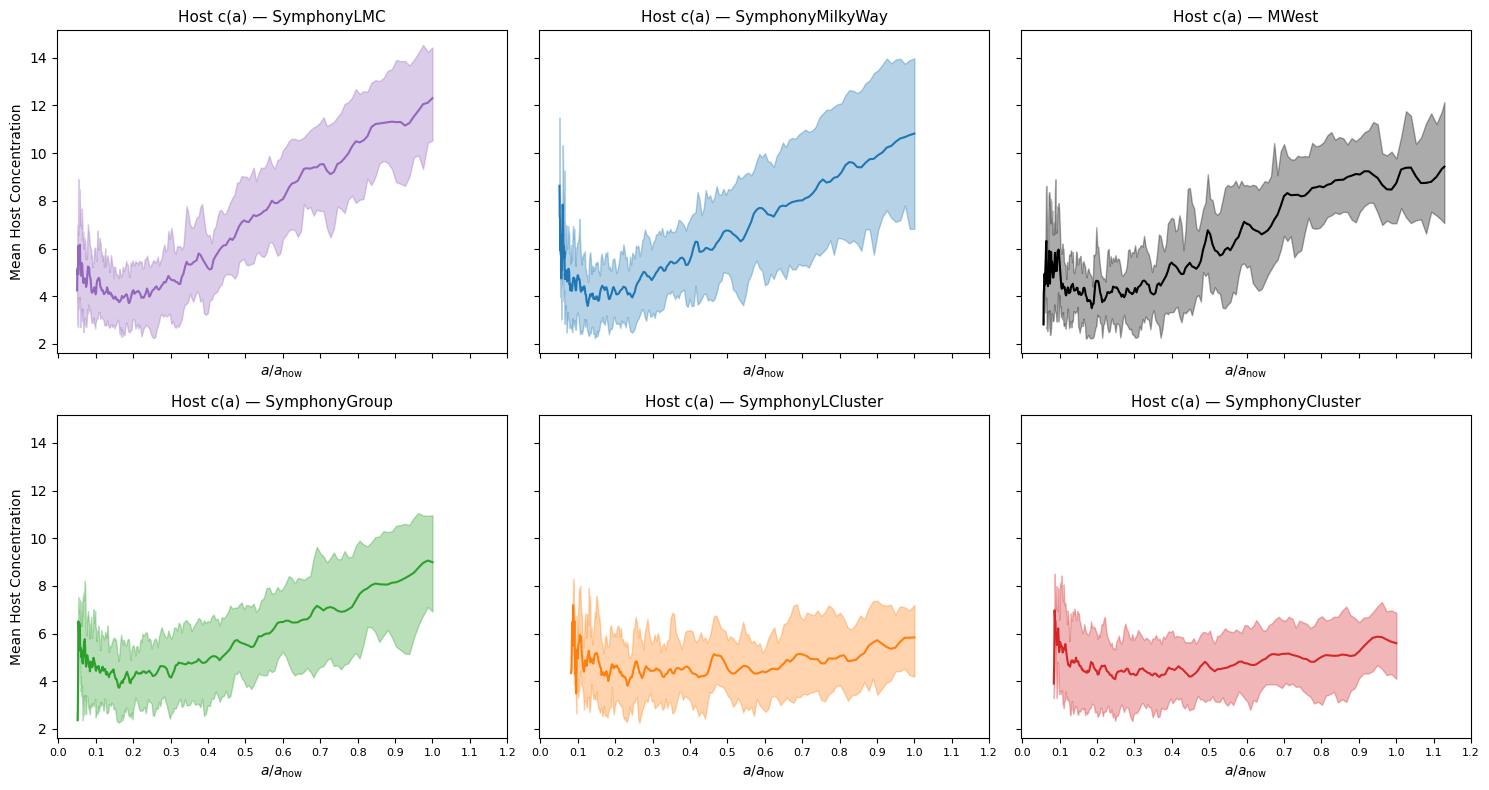

In [21]:
## host concentration --> c(a/a_now)

## same left-padding convention as MAH_nan_padding_stacking: aligns all histories at
## their final retained snapshot; shorter hosts get NaN-padded at the front
def nan_pad_stack(arrays, length):
    padded = [np.concatenate([np.full(length - len(a), np.nan), a]) for a in arrays]
    return np.vstack(padded)

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize = (5 * ncols, 4 * nrows), sharex = True, sharey = True)
axes = np.atleast_1d(axes).flatten()

for suite_index, suite_name in enumerate(suite_list):

    print(f"Starting suite {suite_name}")

    ax = axes[suite_index]

    n_hosts = symlib.n_hosts(suite_name)

    ## MWest needs to be indexed by halo name
    if suite_name == "MWest":
        host_ids = MWest_halos
    else:
        host_ids = list(range(n_hosts))

    ## suite-level params --> use the FIRST host_id to be consistent with MWest
    sim_dir_0 = symlib.get_host_directory(base_dir, suite_name, 0)
    params = symlib.simulation_parameters(sim_dir_0)
    h100 = params["h100"]
    particle_mass = params["mp"]/h100        ## physical Msun
    mass_cut = 300 * particle_mass

    suite_cvirs = []
    suite_a_norm = []

    for i_host, host_id in enumerate(host_ids):

        print(f"Loading host {i_host + 1}/{n_hosts} in suite {suite_name}", end = "\r", flush = True)

        sim_dir = symlib.get_host_directory(base_dir, suite_name, host_id)
        h, hist = symlib.read_subhalos(sim_dir)
        scale_factors = symlib.scale_factors(sim_dir)

        ## a_now: a_lmc_50 for MWest (per-host), true a=1 for every other suite
        if suite_name == "MWest":
            a_now = lmc_analog_sub_data[host_id]["a_lmc_50"]
        else:
            a_now = 1.0

        a_norm = scale_factors / a_now

        host_mass = h["mvir"][0, :]
        host_cvir = h["cvir"][0, :]
        ok = h["ok"][0, :]
        valid = (host_mass >= mass_cut) & ok

        ## plot each individual host
        #ax.plot(redshifts[valid], host_cvir[valid], color = colors[suite_name], lw = 0.75, alpha = 0.125)

        ## store a full-length, auto-NaN-padded array aligned by snapshot
        full_cvir = np.full(len(scale_factors), np.nan)
        full_cvir[valid] = host_cvir[valid]

        suite_cvirs.append(full_cvir)
        suite_a_norm.append(a_norm)

    print()

    ## NaN-pad to a common length (index-aligned, no resampling)
    ## reference a_norm axis for plotting comes from the host with the most snapshots
    max_len = max(len(a) for a in suite_a_norm)
    ref_idx = int(np.argmax([len(a) for a in suite_a_norm]))
    ref_a_norm = suite_a_norm[ref_idx]
    
    ## left-pad ref_a_norm itself too, in case it's not already the max length host (shape safety)
    ref_a_norm_padded = np.concatenate([np.full(max_len - len(ref_a_norm), np.nan), ref_a_norm])
    
    suite_cvirs = nan_pad_stack(suite_cvirs, max_len)

    suite_mean_cvir = np.nanmean(suite_cvirs, axis = 0)
    p16_cvir = np.nanpercentile(suite_cvirs, 16, axis = 0)
    p84_cvir = np.nanpercentile(suite_cvirs, 84, axis = 0)
    
    valid_mean = ~np.isnan(suite_mean_cvir) & ~np.isnan(ref_a_norm_padded)
    ax.plot(ref_a_norm_padded[valid_mean], suite_mean_cvir[valid_mean], color = colors[suite_name], lw = 1.5)
    ax.fill_between(ref_a_norm_padded[valid_mean], p16_cvir[valid_mean], p84_cvir[valid_mean], color = colors[suite_name], alpha = 0.33)

    ax.set_xlabel(r"$a / a_{\rm now}$", fontsize = 10)
    if suite_index % ncols == 0:
        ax.set_ylabel(r"Mean Host Concentration", fontsize = 10)
    ax.tick_params(axis = "x", labelsize = 8)
    ax.set_title(f"Host c(a) — {suite_name}", fontsize = 11)

## hide any unused trailing axes
for j in range(n_suites, len(axes)):
    fig.delaxes(axes[j])

axes[0].set_xticks(np.arange(0, 1.3, 0.1))

plt.tight_layout()
#fig.savefig("host concentration (added MWest).png", dpi = 100)
plt.show()

<a id = "machine_learning"></a>
## Machine Learning

[Back to Table of Contents](#table_of_contents)

The $N_{subs}(z)$ & $M_{host}(z)$ vs. redshift z correlations and the $N_{subs}(z)/N_{subs}(z=0)$ vs. $M_{host}(z)/M_{host}(z=0)$ plot show that there is a reasonably strong baseline correlation between the host mass accretion history and the subhalo population as a function of redshift. Expanding on this, we attempt to use machine learning to make explicit predictions of the subhalo mass function for all the different suites and at different redshifts.

* A reasonable first step is to try to simply predict the total number of subhalos given only the host mass.
* The code below depends on the [Nsubs(z)/Nsubs(z=0) vs. Mhost(z)/Mhost(z=0)](#norm_nsubs_vs_norm_host_mass) code --> that cell needs to be run before this one.

The logic goes as follows:
* Mhost(z)/Mhost(z=0) ranges from ~0 to ~1. We can chop this space up into a number of evenly-spaced "sample masses."
* Each individual host will eventually reach this sample mass, but the specific timestep/snapshot where it first reaches this point may vary (i.e host 1 reaches Mhost/Mhost(z=0) = 0.2 at snapshot 63, while host 2 reaches that same point at snapshot 54, etc).
* Using that timestep, we then collect the total number of "valid" subhalos at that timestep. This will also likely vary a lot across different systems.
* Therefore, once the full dataset has been read in, the x-axis should be a clean, linearly spaced set of masses ranging from ~0 to ~1. Each of these x-axis "sample masses" should show some spread/variation in total Nsubs --> due to some combination of the hosts reaching the sample mass at different times, genuine system-to-system scatter, and inherent differences between the systems at different mass ranges (when comparing across mass ranges)

Fitting suite 1/5: SymphonyLMC (39 hosts)
Host 39/39
SymphonyLMC: pooled fit slope = 1.187, intercept = 0.106, R² = 0.843 (8479 points)

Fitting suite 2/5: SymphonyMilkyWay (45 hosts)
Host 45/45
SymphonyMilkyWay: pooled fit slope = 1.221, intercept = 0.094, R² = 0.861 (9375 points)

Fitting suite 3/5: SymphonyGroup (49 hosts)
Host 49/49
SymphonyGroup: pooled fit slope = 1.181, intercept = 0.066, R² = 0.914 (10094 points)

Fitting suite 4/5: SymphonyLCluster (33 hosts)
Host 33/33
SymphonyLCluster: pooled fit slope = 1.189, intercept = 0.040, R² = 0.928 (5505 points)

Fitting suite 5/5: SymphonyCluster (81 hosts)
Host 81/81
SymphonyCluster: pooled fit slope = 1.154, intercept = 0.041, R² = 0.946 (14084 points)



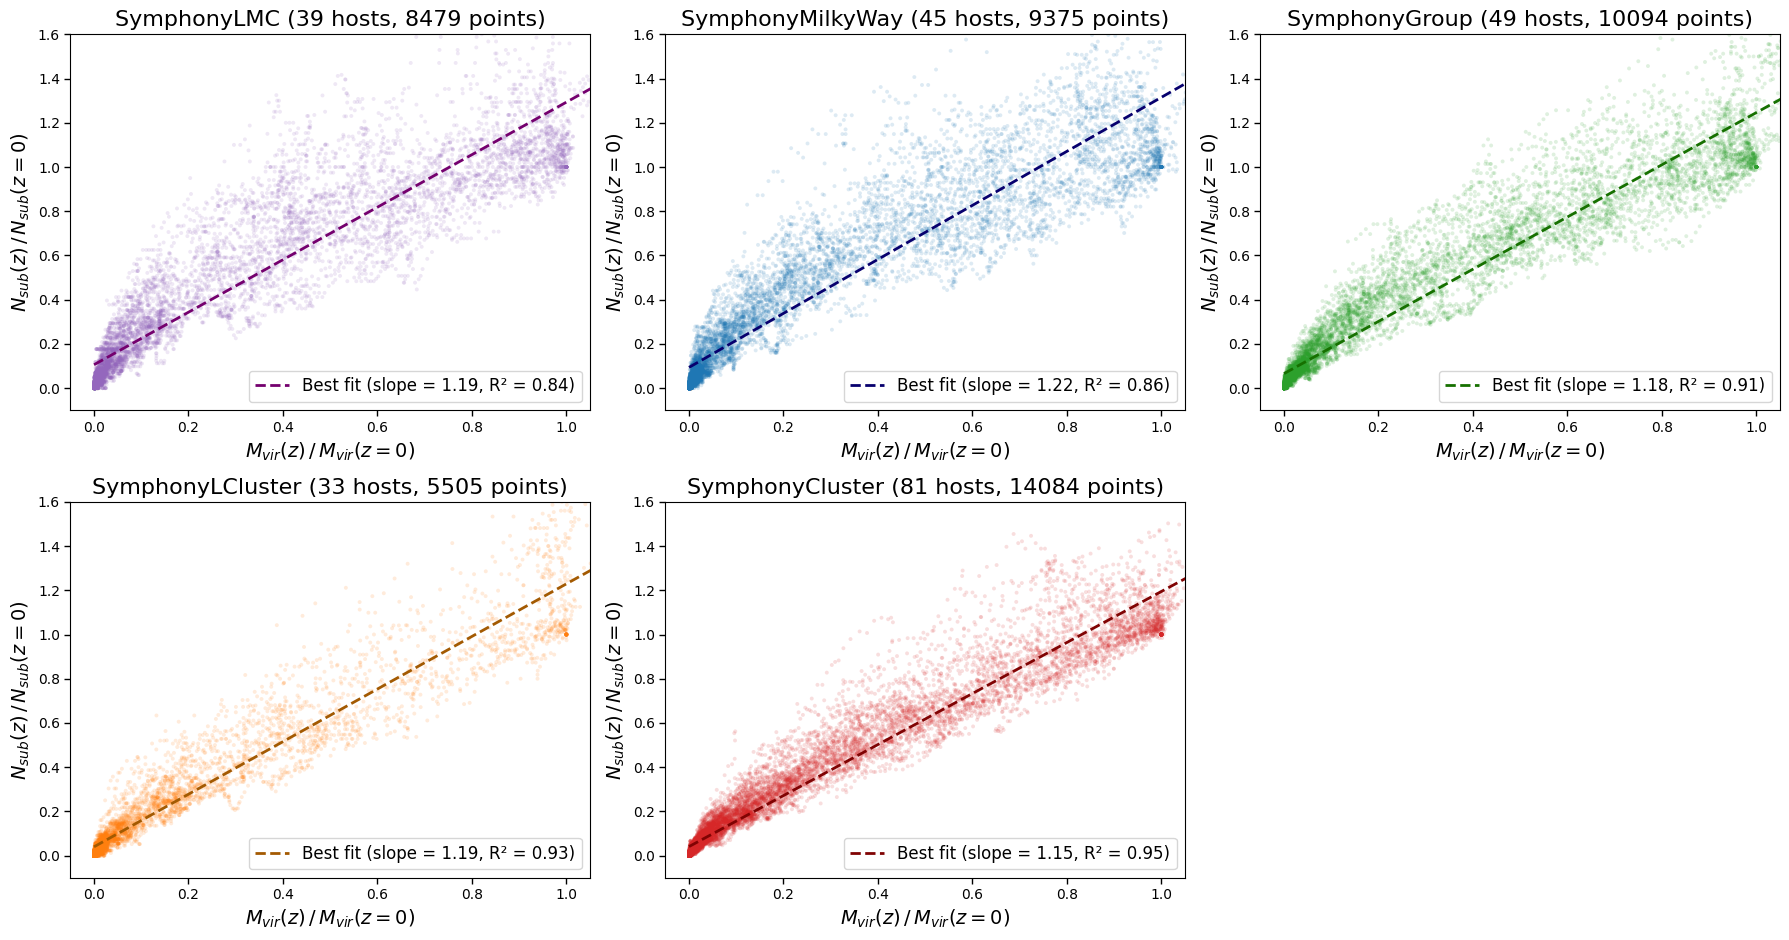


SymphonyLMC:
Suite SymphonyLMC --> particle mass cut: 1.511e+07
Host mass at earliest snapshot: 1.763e+06
Fraction of snapshots where host is BELOW the 300-particle cut: 0.042
  Host 0: z range = [0.000, 15.946]  (223 points)
  Host 1: z range = [0.000, 11.801]  (201 points)
  Host 2: z range = [0.000, 13.917]  (213 points)
  Host 3: z range = [0.000, 15.946]  (223 points)
  Host 4: z range = [0.000, 15.946]  (223 points)
  Host 5: z range = [0.000, 10.414]  (192 points)
  Host 6: z range = [0.000, 15.731]  (222 points)
  Host 7: z range = [0.000, 15.946]  (223 points)
  Host 8: z range = [0.000, 12.471]  (205 points)
  Host 9: z range = [0.000, 15.731]  (222 points)
  Host 10: z range = [0.000, 15.310]  (219 points)
  Host 11: z range = [0.000, 14.109]  (214 points)
  Host 12: z range = [0.000, 13.917]  (212 points)
  Host 13: z range = [0.000, 12.644]  (206 points)
  Host 14: z range = [0.000, 15.946]  (223 points)
  Host 15: z range = [0.000, 11.639]  (200 points)
  Host 16: z rang

'\nfig_3d, ax_3d, animation_3d = plot_3d_true_data_rotating(\n    suite_results_full, colors, initial_elev = 25, initial_azim = -55,\n    final_elev = 90.0, final_azim = -90.0, n_frames = 400, interval = 40, point_size = 4, alpha = 0.15)\nanimation_3d.save("true_data_rotation_LMC.gif", writer = PillowWriter(fps = 25))\nplt.close(fig_3d)\n'

In [10]:
## this uses the Nsubs(z)/Nsubs(z=0) vs. Mhost(z)/Mhost(z=0) dataloader (must be run prior to collect the "ground truth" datapoints)

## DATA MANIPULATION:
## for each host and each reference redshift:
## -> use EVERY valid snapshot from each host's trajectory (converted into redshift)
## -> record the host's normalized mass AND Nsubs there (both drawn from the same snapshot for that host)
## -> disadvantage: different hosts will have different lengths of "valid snapshots"...

## building a reference cosmic time axis that is evenly spaced in time, then converting to redshift
def build_full_redshift_dataset(host_curves, z_max = None):

    n_hosts = len(host_curves)

    mass_list = []       ## list of n_hosts arrays, one array per host (ragged lengths)
    nsubs_list = []
    redshift_list = []

    for curves in host_curves:

        redshifts = curves["redshifts"]     ## z_max -> 0, matches host_masses/num_subhalos index-for-index
        norm_mass = curves["host_masses"] / curves["z0_host_mass"]
        norm_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

        valid = np.isfinite(norm_mass) & np.isfinite(norm_nsubs)

        if z_max is not None:
            valid = valid & (redshifts <= z_max)

        mass_list.append(norm_mass[valid])
        nsubs_list.append(norm_nsubs[valid])
        redshift_list.append(redshifts[valid])

    return mass_list, nsubs_list, redshift_list

def build_cosmo_for_suite(suite_name, base_dir, mwest_snap_data = None):

    n_hosts = symlib.n_hosts(suite_name)

    if suite_name == "MWest" and mwest_snap_data is not None:
        host_ids = MWest_halos
    else:
        host_ids = list(range(n_hosts))

    sim_dir_0 = symlib.get_host_directory(base_dir, suite_name, host_ids[0])
    params = symlib.simulation_parameters(sim_dir_0)

    return FlatLambdaCDM(H0 = params["h100"] * 100, Om0 = params["Om0"])

def build_redshift_indexed_dataset(host_curves, target_redshifts):

    n_hosts = len(host_curves)
    n_z = len(target_redshifts)

    mass_at_z = np.full((n_hosts, n_z), np.nan)
    nsubs_at_z = np.full((n_hosts, n_z), np.nan)

    ## reading in the Nsubs(z)/Nsubs(z=0) vs. Mhost(z)/Mhost(z=0) "ground truth" data
    for i, curves in enumerate(host_curves):

        redshifts = curves["redshifts"]                                ## z_max -> 0, matches host_masses/num_subhalos index-for-index
        norm_mass = curves["host_masses"] / curves["z0_host_mass"]
        norm_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

        valid = np.isfinite(norm_mass) & np.isfinite(norm_nsubs)

        for j, target_z in enumerate(target_redshifts):

            ## nearest snapshot to this reference redshift, for THIS host's own grid
            idx = np.argmin(np.abs(redshifts - target_z))

            ## this host has no valid data at this redshift, leave as NaN
            if not valid[idx]:
                continue

            ## read off the number of subhalos from the Nsubs curve at this time
            mass_at_z[i, j] = norm_mass[idx]
            nsubs_at_z[i, j] = norm_nsubs[idx]

    return mass_at_z, nsubs_at_z

def print_host_redshift_ranges(suite_results_full):
    for suite_name, suite_result in suite_results_full.items():
        print(f"\n{suite_name}:")

        sim_dir = symlib.get_host_directory(base_dir, suite_name, 0)
        scale_factors = symlib.scale_factors(sim_dir)
        params = symlib.simulation_parameters(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)
    
        particle_mass = params["mp"] / params["h100"]
        mass_cut = 300 * particle_mass
        host_mass_all = h["mvir"][0, :]
    
        print(f"Suite {suite_name} --> particle mass cut: {mass_cut:.3e}")
        print(f"Host mass at earliest snapshot: {host_mass_all[0]:.3e}")
        print(f"Fraction of snapshots where host is BELOW the 300-particle cut: {np.mean(host_mass_all < mass_cut):.3f}")

        for i, z_host in enumerate(suite_result["redshift_list"]):
            if len(z_host) == 0:
                print(f"  Host {i}: no valid snapshots")
            else:
                print(f"  Host {i}: z range = [{z_host.min():.3f}, {z_host.max():.3f}]  ({len(z_host)} points)")

###################################################################################################################################################

## STATISTICS:
## per-suite diagnostics: mean/16-84% of Mass and Nsubs at each reference redshift, across hosts.
def aggregate_suite_by_redshift_full(host_curves, z_max = None):

    mass_list, nsubs_list, redshift_list = build_full_redshift_dataset(host_curves, z_max = z_max)

    ## flattened, all hosts pooled together --> used directly by the scatter plot and pooled fit
    mass_flat = np.concatenate(mass_list) if len(mass_list) else np.array([])
    nsubs_flat = np.concatenate(nsubs_list) if len(nsubs_list) else np.array([])
    redshift_flat = np.concatenate(redshift_list) if len(redshift_list) else np.array([])

    n_points_used = np.array([len(m) for m in mass_list])

    return {"mass_list": mass_list,
            "nsubs_list": nsubs_list,
            "redshift_list": redshift_list,
            "mass_flat": mass_flat,
            "nsubs_flat": nsubs_flat,
            "redshift_flat": redshift_flat,
            "n_points_used": n_points_used,
            "n_hosts": len(host_curves)}


def aggregate_all_suites_by_redshift_full(all_host_curves, z_max = None):
    return {suite_name: aggregate_suite_by_redshift_full(host_curves, z_max = z_max)
           for suite_name, host_curves in all_host_curves.items()}

###################################################################################################################################################

## LINEAR REGRESSION
## restructured into the standard f(x) = w . x design-matrix form: for a line, this is
## A = [x, 1], solved via least squares for w = [slope, intercept] such that A @ w ~= y.
## Same fitting logic as before (per-host fits + one pooled fit through all points)

## design matrix: column 0 = x (slope term), column 1 = ones (intercept term)
def fit_linear_weights(x, y):
    A = np.column_stack([x, np.ones_like(x)])
    w, _, _, _ = np.linalg.lstsq(A, y, rcond = None)   ## w = [slope, intercept]
    y_pred = A @ w

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return w, r2

def fit_host_linear_baseline_full(suite_results_full):

    baseline_results = {}
    n_suites = len(suite_results_full)

    for suite_idx, (suite_name, suite_result) in enumerate(suite_results_full.items()):

        mass_list = suite_result["mass_list"]
        nsubs_list = suite_result["nsubs_list"]
        n_hosts = suite_result["n_hosts"]

        print(f"Fitting suite {suite_idx + 1}/{n_suites}: {suite_name} ({n_hosts} hosts)")

        slopes = np.full(n_hosts, np.nan)
        intercepts = np.full(n_hosts, np.nan)
        r2 = np.full(n_hosts, np.nan)

        for i in range(n_hosts):
            print(f"Host {i + 1}/{n_hosts}", end = "\r", flush = True)

            x = mass_list[i]
            y = nsubs_list[i]

            if len(x) < 2:
                continue

            w, host_r2 = fit_linear_weights(x, y)
            slopes[i], intercepts[i] = w
            r2[i] = host_r2

        print()

        ## POOLED FIT: fit ONE line through every valid snapshot from every host in the suite
        x_pooled = suite_result["mass_flat"]
        y_pooled = suite_result["nsubs_flat"]

        if len(x_pooled) >= 2:
            w_pooled, pooled_r2 = fit_linear_weights(x_pooled, y_pooled)
            pooled_slope, pooled_intercept = w_pooled
        else:
            pooled_slope, pooled_intercept, pooled_r2 = np.nan, np.nan, np.nan

        baseline_results[suite_name] = {"slopes": slopes,
                                        "intercepts": intercepts,
                                        "r2": r2,
                                        "mean_slope": np.nanmean(slopes),
                                        "mean_intercept": np.nanmean(intercepts),
                                        "mean_r2": np.nanmean(r2),
                                        "std_slope": np.nanstd(slopes),
                                        "std_r2": np.nanstd(r2),
                                        "pooled_slope": pooled_slope,
                                        "pooled_intercept": pooled_intercept,
                                        "pooled_r2": pooled_r2,
                                        "n_pooled_points": len(x_pooled)}

        print(f"{suite_name}: pooled fit slope = {pooled_slope:.3f}, intercept = {pooled_intercept:.3f}, "
              f"R\u00b2 = {pooled_r2:.3f} ({len(x_pooled)} points)\n")

    return baseline_results

###################################################################################################################################################

## PLOTTING:
def plot_suite_by_redshift(ax, suite_name, suite_result, baseline_result, colors):

    color = colors[suite_name]

    x_scatter = suite_result["mass_flat"]
    y_scatter = suite_result["nsubs_flat"]

    ax.scatter(x_scatter, y_scatter, s = 8, color = color, alpha = 0.15, edgecolors = "none", zorder = 1)

    pooled_slope = baseline_result["pooled_slope"]
    pooled_intercept = baseline_result["pooled_intercept"]
    if np.isfinite(pooled_slope):
        x_line = np.linspace(0, np.nanmax(x_scatter) if len(x_scatter) else 1.0, 100)
        y_pooled_fit = pooled_slope * x_line + pooled_intercept
        ax.plot(x_line, y_pooled_fit, color = avg_colors[suite_name], lw = 2.0, linestyle = "--", zorder = 4,
               label = f"Best fit (slope = {pooled_slope:.2f}, R\u00b2 = {baseline_result['pooled_r2']:.2f})")

    ax.set_xlabel(r"$M_{vir}(z)\,/\, M_{vir}(z=0)$", fontsize = 14)
    ax.set_ylabel(r"$N_{sub}(z)\,/\, N_{sub}(z=0)$", fontsize = 14)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.1, 1.6)
    ax.set_title(f"{suite_name} ({suite_result['n_hosts']} hosts, {baseline_result['n_pooled_points']} points)", fontsize = 16)
    ax.legend(fontsize = 12, loc = "lower right")
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")

def plot_all_suites_by_redshift(suite_results, baseline_results, colors, max_cols = 3):

    suite_names = list(suite_results.keys())
    n_suites = len(suite_names)
    ncols = min(max_cols, n_suites)
    nrows = int(np.ceil(n_suites / ncols))

    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (6 * ncols, 5 * nrows), squeeze = False)
    flat_axs = axs.flatten()

    for i, suite_name in enumerate(suite_names):
        plot_suite_by_redshift(flat_axs[i], suite_name, suite_results[suite_name], baseline_results[suite_name], colors)

    for j in range(n_suites, len(flat_axs)):
        fig.delaxes(flat_axs[j])

    fig.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

    return fig, axs

#################################################################################################################################################

## ANIMATION:

from matplotlib.animation import FuncAnimation, PillowWriter

def plot_3d_true_data_rotating(suite_results, colors, initial_elev = 25, initial_azim = -55,
                               final_elev = 89.9, final_azim = -30, n_frames = 100, interval = 40,
                               point_size = 6, alpha = 0.25, show_host_trajectories = False):

    fig = plt.figure(figsize = (8, 6))
    ax = fig.add_subplot(111, projection = "3d")

    for suite_name, suite_result in suite_results.items():

        color = colors[suite_name]

        if show_host_trajectories:
            for x_host, y_host, z_host in zip(suite_result["mass_list"], suite_result["nsubs_list"], suite_result["redshift_list"]):
                if len(x_host) < 2:
                    continue
                ax.plot(x_host, y_host, z_host, color = color, alpha = 0.12, lw = 0.7, zorder = 1)

        x = suite_result["mass_flat"]
        y = suite_result["nsubs_flat"]
        z = suite_result["redshift_flat"]

        ax.scatter(x, y, z, s = point_size, color = color, alpha = alpha, edgecolors = "none", label = suite_name, zorder = 2)

    ax.set_xlabel(r"$M_{\rm host}(z)\,/\,M_{\rm host}(z=0)$", fontsize = 14, labelpad = 12)
    ax.set_ylabel(r"$N_{\rm sub}(z)\,/\,N_{\rm sub}(z=0)$", fontsize = 14, labelpad = 12)
    ax.set_zlabel(r"$z$", fontsize = 14, labelpad = 12)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.1, 1.6)

    max_z = max(np.nanmax(r["redshift_flat"]) if len(r["redshift_flat"]) else 0.0 for r in suite_results.values())
    ax.set_zlim(0, max_z)

    ax.view_init(elev = initial_elev, azim = initial_azim)
    ax.legend(fontsize = 11, loc = "upper left")

    def init():
        ax.view_init(elev = initial_elev, azim = initial_azim)
        return (ax,)

    def update(frame):
        fraction = frame / (n_frames - 1)
        print(f"Rendering frame {frame+1} ({(fraction*100):.2f}%)", end = "\r", flush = True)

        smooth_fraction = (3 * fraction**2 - 2 * fraction**3)
        elev = initial_elev + (final_elev - initial_elev) * smooth_fraction
        azim = initial_azim + (final_azim - initial_azim) * smooth_fraction

        ax.view_init(elev = elev, azim = azim)
        return (ax,)

    animation = FuncAnimation(fig, update, init_func = init, frames = n_frames, interval = interval,
                              blit = False, repeat = True, cache_frame_data = False)

    plt.tight_layout()

    return fig, ax, animation


suite_results_full = aggregate_all_suites_by_redshift_full(all_host_curves, z_max = 16.0)
baseline_results_full = fit_host_linear_baseline_full(suite_results_full)
fig, axs = plot_all_suites_by_redshift(suite_results_full, baseline_results_full, colors)
#fig.savefig("linear regression v5.png")

print_host_redshift_ranges(suite_results_full)

'''
fig_3d, ax_3d, animation_3d = plot_3d_true_data_rotating(
    suite_results_full, colors, initial_elev = 25, initial_azim = -55,
    final_elev = 90.0, final_azim = -90.0, n_frames = 400, interval = 40, point_size = 4, alpha = 0.15)
animation_3d.save("true_data_rotation_LMC.gif", writer = PillowWriter(fps = 25))
plt.close(fig_3d)
'''

Now we evolve. Previously, we were taking in $\frac{M_{host}(z)}{M_{host}(z=0)}$ and $\frac{N_{subs}(z)}{N_{subs}(z=0)}$ as sets of points (M, N), and fitting a line $f(x) = w_1 x + w_0$ to it to get the predictions. Now, we can take in all the complete mass accretion histories for all the suites: $M = [[M_1(z_1), M_1(z_2), ... , M_1(z_N)], [M_2(z_1), M_2(z_2), ... M_2(z_N), ..., M_N(z_N)]$ as a concatenated array of values (effectively pooling over all suites (this will be a jagged array since different hosts have different numbers of hosts and different numbers of snapshots), and we can output predictions for $\frac{N_{subs}(z)}{N_{subs}(z=0)}$ also as arrays of values.

Suite: SymphonyLMC
Suite: SymphonyMilkyWay
Suite: SymphonyGroup
Loading host 1/49

C:\Users\steph\AppData\Local\Temp\ipykernel_13792\2571377761.py:88: RuntimeWarning: Mean of empty slice
  mean_mah = np.nanmean(avg_mah, axis = 0)


Suite: SymphonyLCluster
Suite: SymphonyCluster
Loading host 81/81

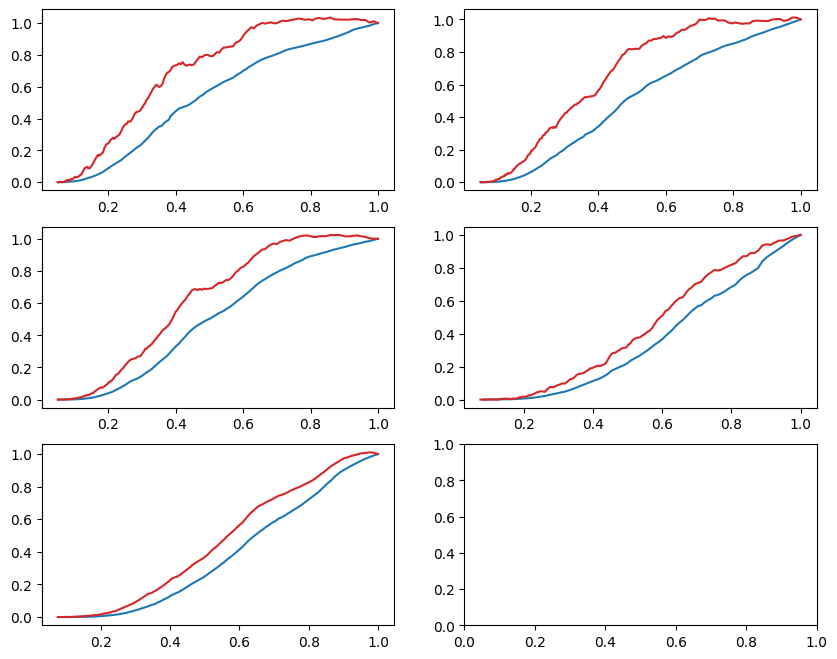

In [65]:
## new version of the linear regression
## inputs: mass accretion history Mhost(z)/Mhost(z=0)
## outputs: total # of subhalos as a function of z (Nsubs(z)/Nsubs(z=0))
## data --> mass accretion histories for all hosts in all the suites concatenated together. these are all just collections of numbers from 0 to 1,
## so hopefully there's some universal information in this dataset that can be picked up

## DATALOADER --> (independent to the other one b/c the format changed)

## the shape of the MAH array once all the data is loaded should be N_suites by N_hosts
## Cluster has the most hosts out of any (81), and there are 6 suites in suite_list, so the shape is 6 rows by 81 columns (empty elements are just 0)

suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]

## input
mahs_all_suites = np.zeros((6, 81), dtype = "object")

## output
nsubs_all_suites = np.zeros((6, 81), dtype = "object")

fig, ax = plt.subplots(3, 2, figsize = (10, 8))
ax = ax.flatten()

for suite_index, suite_name in enumerate(suite_list):

    print(f"Suite: {suite_name}")
    
    n_hosts = symlib.n_hosts(suite_name)

    if suite_name == "MWest":
        host_ids = list(mwest_snap_data.keys())
    else:
        host_ids = list(range(n_hosts))

    sim_dir_0 = symlib.get_host_directory(base_dir, suite_name, 0)
    scale_factors = symlib.scale_factors(sim_dir_0)
    snapshots = np.arange(0, len(scale_factors), 1)
    redshifts = (1.0 / scale_factors) - 1.0
    
    params = symlib.simulation_parameters(sim_dir_0)
    h100 = params["h100"]
    particle_mass = params["mp"] / h100
    Om0 = params["Om0"]

    avg_mah = []
    avg_nsubs = []
    
    for host_index, host_id in enumerate(host_ids):

        print(f"Loading host {host_index + 1}/{n_hosts}", end = "\r", flush = True)

        sim_dir = symlib.get_host_directory(base_dir, suite_name, host_id)
        h, hist = symlib.read_subhalos(sim_dir)

        ## host MAH
        host_mah = h["mvir"][0, :]

        ## "ok" survival check
        host_ok = h["ok"][0, :]
        host_pos = h["x"][0, :]
        host_rvir = h["rvir"][0, :]     ## subhalos also have to be inside host rvir
        
        valid_host = (host_mah >= 300 * particle_mass) & host_ok

        host_mah_norm = np.full(len(host_mah), np.nan)
        host_mah_valid = host_mah[valid_host]
        host_mah_norm[valid_host] = host_mah_valid / host_mah_valid[-1]

        #ax[suite_index].plot(scale_factors[valid_host], host_mah_norm, color = "tab:blue", lw = 1.0, alpha = 0.5)

        avg_mah.append(host_mah_norm)

        ## Nsubs
        sub_mvir = h["mvir"][1:, :]
        sub_ok = h["ok"][1:, :]
        sub_pos = h["x"][1:, :]
        dist = np.sqrt(np.sum((sub_pos - host_pos[np.newaxis, :, :]) ** 2, axis = 2))
        valid_subhalos = ((sub_mvir >= 300 * particle_mass) & sub_ok & (dist <= host_rvir[np.newaxis, :]))

        tot_nsubs_valid = np.sum(valid_subhalos, axis = 0)
        tot_nsubs_norm = tot_nsubs_valid / tot_nsubs_valid[-1]
        #ax[suite_index].plot(scale_factors, tot_nsubs_norm, color = "tab:red", lw = 1.0, alpha = 0.5)

        avg_nsubs.append(tot_nsubs_norm)

    avg_mah = np.asarray(avg_mah)
    avg_nsubs = np.asarray(avg_nsubs)

    mean_mah = np.nanmean(avg_mah, axis = 0)
    mean_nsubs = np.nanmean(avg_nsubs, axis = 0)

    ax[suite_index].plot(scale_factors, mean_mah, color = "tab:blue", lw = 1.5)
    ax[suite_index].plot(scale_factors, mean_nsubs, color = "tab:red", lw = 1.5)

<a id = "animations"></a>
## Subhalo Animations
[Back to Table of Contents](#table_of_contents)

The first animation qualitatively investigates the effect of these "massive progenitors" infalling onto the main host. Massive progenitors are (color), and their spatio-temporally associated subhalos (as determined via the Deason criterion) are (color). Unassociated subhalos are (color), and the main host is (color). Unlike in d'Souza & Bell, subhalos here are defined based on the typical 300 particles and "ok" survival criteria used elsewhere in this analysis.

The expectation given the previous results is that massive progenitor infalls "deplete" the surrounding region of subhalos by "focusing" associated and unassociated subhalos onto the main host, causing the massive spike in the $\xi(t)$ estimator plot. These would also seem to correlate with the times of "jumps" in the MAHs, and possibly also the time-dependent behavior of the concentration parameter, the rate of subhalo destruction over time (also as a correlation function), potentially the rate of mass loss of massive subhalos, and maybe some other properties (relaxation state?).

All animations only use the first halo in the suite, for now. In the future, I may broaden to somehow incorporate an "average" over all the hosts.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D

import os
import glob
from PIL import Image

## GOAL: create a visualization that shows the "depletion" of subhalos in the surroundings following a "massive progenitor" infalling into a host.

## CONFIG:
n_particles_cut = 300
massive_progenitor_frac = 0.1
min_assoc_time_gyr = 1.0

output_dir = "depletion"
image_glob = "depletion/*.png"
output_gif = "depletion.gif"
gif_frame_duration_ms = 100

## instantiating a PatchCollection of true-to-scale circles for a set of halos
def make_circle_collection(positions, radii, indices, snap, color, alpha):
    circles = [Circle((positions[i, snap, 0], positions[i, snap, 1]), radii[i, snap]) for i in indices]
    return PatchCollection(circles, facecolor = color, edgecolor = "none", alpha = alpha)

##########################################################################################################

## DATALOADING:

## read one host's halo catalog + merger tree history from Symlib
def load_simulation(base_dir, suite_name, host_num = 0):
    
    sim_dir = symlib.get_host_directory(base_dir, suite_name, host_num)

    print(sim_dir)
    
    h, hist = symlib.read_subhalos(sim_dir)
    params = symlib.simulation_parameters(sim_dir)
    scale_factors = symlib.scale_factors(sim_dir)

    return h, hist, params, scale_factors, sim_dir

## compute cosmic times from scale factors
## snapshot-indexed lookup table of cosmic time (Gyr) and redshift
def compute_cosmic_times(scale_factors, params):

    h100 = params["h100"]
    Om0 = params["Om0"]
    cosmo = FlatLambdaCDM(H0 = h100 * 100, Om0 = Om0)
    z = (1.0 / scale_factors) - 1.0
    cosmic_times = cosmo.age(z).value

    return cosmic_times, z

## convert to physical Msun
def conv_particle_mass(params):
    return params["mp"] / params["h100"]

######################################################################################################################

## HALO/SUBHALO SELECTION:

## split the combined (host + subhalo) catalog into host and subhalo pieces
def get_host_and_subhalo_arrays(h, hist):
    return {"host_pos": h["x"][0, :],
            "host_rvir": h["rvir"][0, :],
            "host_mvir": h["mvir"][0, :],
            "sub_pos": h["x"][1:, :],
            "sub_rvir": h["rvir"][1:, :],
            "sub_mvir": h["mvir"][1:, :],
            "sub_ok": h["ok"][1:, :],
            "sub_mpeak": hist["mpeak"][1:],
            "sub_infall_snap": hist["merger_snap"][1:]}

## performing the 300 particles and ok cut
def compute_valid_mask(sub_mvir, sub_ok, mp_mass):
    return (sub_mvir >= mp_mass) & sub_ok

## Boolean mask (over subhalo index) of massive progenitors
def identify_massive_progenitors(sub_mpeak, host_mvir_z0, valid_mask, frac = massive_progenitor_frac):
    ever_valid = valid_mask.any(axis = 1)
    return (sub_mpeak >= frac * host_mvir_z0) & ever_valid

## DEASON ASSOCIATION CRITERION:

## Boolean mask (length = nsub) of subhalos
## associated = subhalo was *continuously* within the massive progenitor's Rvir for the last ≥1 Gyr before the subhalo's infall into the host.
def find_associated_subhalos(mp_i, sub_pos, sub_rvir, sub_ok, valid_mask, sub_infall_snap, dt, snap_idx, min_time_gyr = min_assoc_time_gyr):

    nsub = sub_pos.shape[0]
    mp_infall_snap = sub_infall_snap[mp_i]

    if mp_infall_snap < 0:
        return np.zeros(nsub, dtype = bool)

    mp_pos = sub_pos[mp_i]
    mp_rvir = sub_rvir[mp_i]
    mp_ok = sub_ok[mp_i]

    sep = np.linalg.norm(sub_pos - mp_pos[None, :, :], axis = 2)
    within_rvir = sep < mp_rvir[None, :]
    qualifying = within_rvir & valid_mask & mp_ok[None, :]

    associated = np.zeros(nsub, dtype = bool)

    ## step backwards through infall times, looking for when the subhalo was last outside the massive progenitor's Rvir
    for i in range(nsub):
        infall_s = sub_infall_snap[i]
        if infall_s <= 0:
            continue
        t = 0.0
        for s in range(infall_s - 1, -1, -1):
            if qualifying[i, s]:
                t += dt[s]
            else:
                break   # streak broken -- stop counting
        associated[i] = t >= min_time_gyr

    associated[mp_i] = False      ## not associated with itself

    return associated

def compute_all_associations(mp_idx, sub_pos, sub_rvir, sub_ok, valid_mask, sub_infall_snap, dt, snap_idx):

    associated_masks = {mp_i: find_associated_subhalos(mp_i, sub_pos, sub_rvir, sub_ok, valid_mask, sub_infall_snap, dt, snap_idx) for mp_i in mp_idx}

    nsub = sub_pos.shape[0]
    associated_any = np.zeros(nsub, dtype = bool)

    for mask in associated_masks.values():
        associated_any |= mask

    return associated_masks, associated_any

################################################################################################################################

## PLOTTING:

## returns Boolean masks (other / associated / massive progenitor)
def classify_subhalos_at_snapshot(snap, valid_mask, massive_progenitors, associated_any, lmc_idx):

    exists = valid_mask[:, snap]

    is_lmc = np.zeros_like(exists, dtype = bool)
    is_lmc[lmc_idx] = exists[lmc_idx]

    is_mp = massive_progenitors & exists          ## LMC stays included -- it IS a massive progenitor
    is_assoc = associated_any & exists & ~is_mp
    is_other = exists & ~is_mp & ~is_assoc

    return is_other, is_assoc, is_mp, is_lmc

def plot_snapshot(ax, snap, sub_pos, sub_rvir, host_rvir, cosmic_times, z, plot_lim, valid_mask, massive_progenitors,
                  associated_any, lmc_idx, show_unassociated = True):

    ax.clear()

    host_circle = plt.Circle((0, 0), host_rvir[snap], color = "black", fill = False, lw = 1.5)
    ax.add_patch(host_circle)

    is_other, is_assoc, is_mp, is_lmc = classify_subhalos_at_snapshot(snap, valid_mask, massive_progenitors, associated_any, lmc_idx)

    other_idx = np.where(is_other)[0]
    assoc_idx = np.where(is_assoc)[0]
    mp_idx_snap = np.where(is_mp)[0]

    if show_unassociated and len(other_idx):
        ax.add_collection(make_circle_collection(sub_pos, sub_rvir, other_idx, snap, color = "tab:blue", alpha = 0.4))

    if len(assoc_idx):
        ax.add_collection(make_circle_collection(sub_pos, sub_rvir, assoc_idx, snap, color = "tab:red", alpha = 0.5))

    if len(mp_idx_snap):
        ax.add_collection(make_circle_collection(sub_pos, sub_rvir, mp_idx_snap, snap, color = "tab:purple", alpha = 0.6))

    if is_lmc[lmc_idx]:
        lmc_outline = Circle((sub_pos[lmc_idx, snap, 0], sub_pos[lmc_idx, snap, 1]), sub_rvir[lmc_idx, snap],
                             fill = False, edgecolor = "black", lw = 1.0, linestyle = "--", zorder = 5)
        ax.add_patch(lmc_outline)

    ax.set_xlim(-plot_lim, plot_lim)
    ax.set_ylim(-plot_lim, plot_lim)
    ax.set_aspect("equal")
    ax.set_xlabel("x [kpc]")
    ax.set_ylabel("y [kpc]")
    ax.set_title(f"t = {cosmic_times[snap]:.2f} Gyr  (z = {z[snap]:.2f})")

    legend_elements = [Patch(facecolor = "tab:red", alpha = 0.5, label = "Associated subhalos"),
                       Patch(facecolor = "tab:purple", alpha = 0.6, label = "Massive progenitors"),
                       Line2D([0], [0], color = "black", lw = 1.0, linestyle = "--", label = "LMC analog"),
                       Line2D([0], [0], color = "black", lw = 1.0, label = "Host virial radius")]

    if show_unassociated:
        legend_elements.insert(0, Patch(facecolor = "tab:blue", alpha = 0.4, label = "Unassociated subhalos"))

    ax.legend(handles = legend_elements, loc = "upper right", fontsize = 7)

## Loop over snapshots, saving one PNG per frame
def render_all_snapshots(snapshots, output_dir, ax, sub_pos, sub_rvir, host_rvir, cosmic_times, z,
                         valid_mask, massive_progenitors, associated_any, lmc_idx, sim_dir, show_unassociated = True):

    os.makedirs(output_dir, exist_ok = True)
    plot_lim = 2 * np.nanmax(host_rvir)

    halo_name = os.path.basename(sim_dir)
    suite_name = os.path.basename(os.path.dirname(sim_dir))
    ax.figure.suptitle(f"{suite_name} — {halo_name}", fontsize = 10)

    for snap in snapshots:
        plot_snapshot(ax, snap, sub_pos, sub_rvir, host_rvir, cosmic_times, z, plot_lim, valid_mask, massive_progenitors,
                     associated_any, lmc_idx, show_unassociated = show_unassociated)
        ax.figure.savefig(f"{output_dir}/snap_{snap:03d}.png", dpi = 100)


## Assemble saved PNGs (sorted by filename) into a looping GIF image
def build_gif(image_glob, output_gif_path, duration_ms = gif_frame_duration_ms):
    png_files = sorted(glob.glob(image_glob))
    if not png_files:
        raise FileNotFoundError(f"No PNGs found matching {image_glob!r}")
 
    frames = [Image.open(f) for f in png_files]
    frames[0].save(output_gif_path, save_all = True, append_images = frames[1:],
                    duration = duration_ms, loop = 0)


#########################################################################################################################################


## MAIN/ENTRYPOINT:

def main(base_dir, suite_list, host_name, show_unassociated = True, output_dir = output_dir, output_gif = output_gif):

    suite_name = suite_list[0]
    print(suite_name)

    h, hist, params, scale_factors, sim_dir = load_simulation(base_dir, suite_name, host_name)
    snapshots = np.arange(len(scale_factors))
    snap_idx = snapshots

    cosmic_times, z = compute_cosmic_times(scale_factors, params)
    dt = np.gradient(cosmic_times)
    mp_mass = n_particles_cut * conv_particle_mass(params)

    arrs = get_host_and_subhalo_arrays(h, hist)

    valid_mask = compute_valid_mask(arrs["sub_mvir"], arrs["sub_ok"], mp_mass)
    host_mvir_z0 = arrs["host_mvir"][-1]

    massive_progenitors = identify_massive_progenitors(arrs["sub_mpeak"], host_mvir_z0, valid_mask)
    mp_idx = np.where(massive_progenitors)[0]

    lmc_idx = lmc_analog_sub_data[host_name]["sub_idx"] - 1

    if lmc_idx in mp_idx:
        print(f"LMC is a massive progenitor: {massive_progenitors[lmc_idx]}")
    else:
        print("WARNING: LMC analog is NOT classified as a massive progenitor.")

    associated_masks, associated_any = compute_all_associations(mp_idx, arrs["sub_pos"], arrs["sub_rvir"], arrs["sub_ok"], valid_mask,
                                                                arrs["sub_infall_snap"], dt, snap_idx)

    fig, ax = plt.subplots(figsize = (6, 6))
    render_all_snapshots(snapshots, output_dir, ax, arrs["sub_pos"], arrs["sub_rvir"], arrs["host_rvir"],
                         cosmic_times, z, valid_mask, massive_progenitors, associated_any, lmc_idx, sim_dir,
                         show_unassociated = show_unassociated)

    plt.close(fig)
    build_gif(f"{output_dir}/*.png", output_gif)
    print(f"Saved animation to {output_gif}")

    return associated_masks, associated_any


## example usage:
## full view (default):
#main(base_dir, ["MWest"], host_name = "Halo169")

## associated-only view, saved to a separate folder/GIF so it doesn't overwrite the full version:
#main(base_dir, ["MWest"], host_name = "Halo169", show_unassociated = False,
#     output_dir = "depletion_assoc_only", output_gif = "depletion_assoc_only.gif")

In [ ]:
## generating subhalo location and mass vs time gifs!
import glob
import os
from PIL import Image
from astropy.cosmology import FlatLambdaCDM
from matplotlib.lines import Line2D

base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyCluster"]
output_directory = "subhalo_gif"
output_gif_path = "subhalo_animation.gif"
zoom_factor = 7   ## axes span +/- zoom_factor * host_rvir, per snapshot

## clear any stale frames from a previous run so old/new frames never mix
if os.path.exists(output_directory):
    for f in glob.glob(f"{output_directory}/*.png"):
        os.remove(f)
else:
    os.makedirs(output_directory)

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (8, 8))

legend_elements = [Line2D([0], [0], color = "black", lw = 2.0, label = "Host"),
                   Line2D([0], [0], color = "tab:blue", lw = 1.5, label = "Subhalos")]

for suite_index, suite_name in enumerate(suite_list):

    n_hosts = symlib.n_hosts(suite_name)

    for i_host in range(1):

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        params = symlib.simulation_parameters(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        ## cosmic time (Gyr) for each snapshot, for the title
        cosmo = FlatLambdaCDM(H0 = params["h100"] * 100, Om0 = params["Om0"])
        redshifts = 1.0 / scale_factors - 1.0
        cosmic_times = cosmo.age(redshifts).value

        n_snap = len(scale_factors)

        for snap_index, snap in enumerate(scale_factors):
            print(f"Rendering snapshot {snap_index + 1}/{n_snap}", end = "\r", flush = True)

            ax.clear()

            host = h[0, snap_index]

            ## host: black circle
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "black", lw = 2.0)

            ## subhalos: blue circles
            for i in range(1, len(h)):
                sub = h[i, snap_index]
                if sub["ok"]:
                    symlib.plot_circle(ax, sub["x"][0], sub["x"][1], sub["rvir"], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-zoom_factor * host["rvir"], zoom_factor * host["rvir"])
            ax.set_ylim(-zoom_factor * host["rvir"], zoom_factor * host["rvir"])
            ax.set_aspect("equal")
            ax.set_xlabel("x [kpc]")
            ax.set_ylabel("y [kpc]")
            ax.set_title(f"t = {cosmic_times[snap_index]:.2f} Gyr  (z = {redshifts[snap_index]:.2f})")
            ax.legend(handles = legend_elements, loc = "upper right", fontsize = 10)

            plt.tight_layout()

            filename = f"subhalo_image_{snap_index:04d}.png"
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 100, facecolor = "white")

print()
plt.close(fig)

## assemble the saved frames into a looping GIF
png_files = sorted(glob.glob(f"{output_directory}/*.png"))
frames = [Image.open(f) for f in png_files]
frames[0].save(output_gif_path, save_all = True, append_images = frames[1:], duration = 100, loop = 0)
print(f"Saved animation to {output_gif_path}")

Nsub:
read_subhalos : 103
read_rockstar : 103
read_symfind  : 100


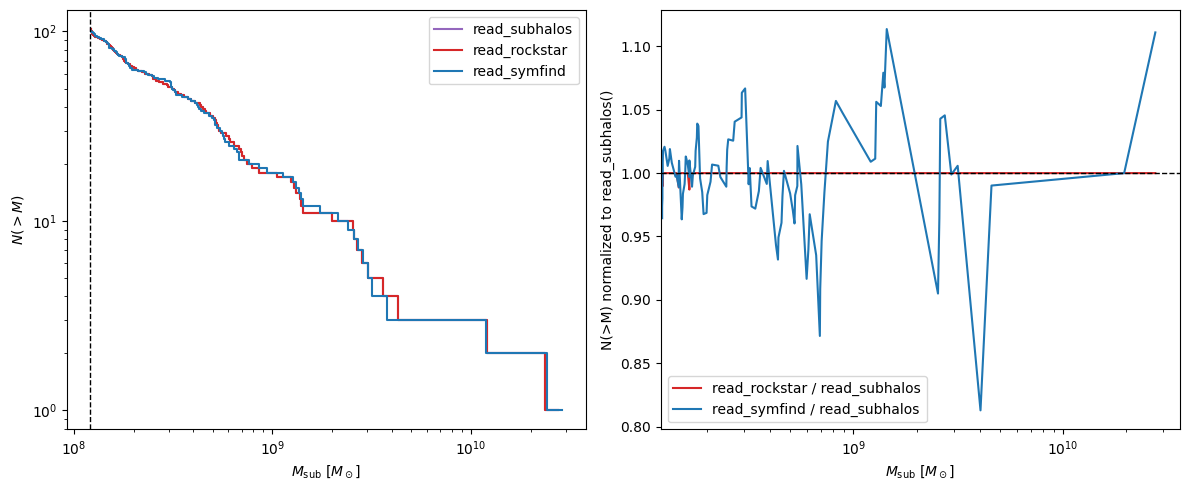

In [17]:
suite_name = "SymphonyMilkyWay"
host_id = 0

sim_dir = symlib.get_host_directory(base_dir, suite_name, host_id)

params = symlib.simulation_parameters(sim_dir)

particle_mass = params["mp"] / params["h100"]
mass_cut = 300 * particle_mass

scale_factors = symlib.scale_factors(sim_dir)
z0_snap = len(scale_factors) - 1

## read all 3 functions
h_subhalos, hist_subhalos = symlib.read_subhalos(sim_dir)
h_rockstar, hist_rockstar = symlib.read_rockstar(sim_dir)
h_symfind, hist_symfind = symlib.read_symfind(sim_dir)

## read_subhalos()
m_subhalos = h_subhalos["mvir"][1:, z0_snap]
ok_subhalos = h_subhalos["ok"][1:, z0_snap]
valid_subhalos = ((m_subhalos >= mass_cut) & ok_subhalos)
m_subhalos = m_subhalos[valid_subhalos]

## read_rockstar()
m_rockstar = h_rockstar["m"][1:, z0_snap]
ok_rockstar = h_rockstar["ok"][1:, z0_snap]
valid_rockstar = ((m_rockstar >= mass_cut) & ok_rockstar)
m_rockstar = m_rockstar[valid_rockstar]

## read_symfind()
m_symfind = h_symfind["m"][1:, z0_snap]
ok_symfind = h_symfind["ok"][1:, z0_snap]
valid_symfind = ((m_symfind >= mass_cut) & ok_symfind)
m_symfind = m_symfind[valid_symfind]

print("Nsub:")
print(f"read_subhalos : {len(m_subhalos)}")
print(f"read_rockstar : {len(m_rockstar)}")
print(f"read_symfind  : {len(m_symfind)}")

## cumulative SHMF
m_subhalos_sorted = np.sort(m_subhalos)[::-1]
m_rockstar_sorted = np.sort(m_rockstar)[::-1]
m_symfind_sorted = np.sort(m_symfind)[::-1]

N_subhalos = np.arange(1, len(m_subhalos_sorted) + 1)
N_rockstar = np.arange(1, len(m_rockstar_sorted) + 1)
N_symfind = np.arange(1, len(m_symfind_sorted) + 1)

## interpolate cumulative functions onto read_subhalos mass grid
N_rockstar_interp = np.interp(np.log10(m_subhalos_sorted), np.log10(m_rockstar_sorted[::-1]), N_rockstar[::-1])
N_symfind_interp = np.interp(np.log10(m_subhalos_sorted), np.log10(m_symfind_sorted[::-1]), N_symfind[::-1])

## ratios relative to read_subhalos
ratio_rockstar = N_rockstar_interp / N_subhalos
ratio_symfind = N_symfind_interp / N_subhalos

## overplot all 3 SHMFs
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].step(m_subhalos_sorted, N_subhalos, where = "mid", label = "read_subhalos", color = "tab:purple")
ax[0].step(m_rockstar_sorted, N_rockstar, where = "mid", label = "read_rockstar", color = "tab:red")
ax[0].step(m_symfind_sorted, N_symfind, where = "mid", label = "read_symfind", color = "tab:blue")
ax[0].axvline(mass_cut, ls = "--", lw = 1.0, color = "black")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
ax[0].set_ylabel(r"$N(>M)$")
ax[0].legend()

## ratios relative to read_subhalos()
ax[1].plot(m_subhalos_sorted, ratio_rockstar, label = "read_rockstar / read_subhalos", color = "tab:red")
ax[1].plot(m_subhalos_sorted, ratio_symfind, label = "read_symfind / read_subhalos", color = "tab:blue")
ax[1].axhline(1.0, ls = "--", lw = 1.0, color = "black")
ax[1].set_xscale("log")
ax[1].set_xlim(left = mass_cut)
ax[1].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
ax[1].set_ylabel(r"N(>M) normalized to read_subhalos()")
ax[1].legend()

plt.tight_layout()
#plt.savefig("testing halo finders.png")
plt.show()